## Setup

Standard imports for the whole notebook — numpy/pandas/matplotlib for the numbers and plots, anndata + flowsom for clustering, scipy for stats.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.patches import Patch
from matplotlib.backends.backend_pdf import PdfPages
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.spatial.distance import cosine, pdist
from scipy import stats

## Config

Column name constants and global knobs used everywhere downstream (min_size = smallest clonotype analysed, thresholds = the sweep grid for the Ly49C/SYFPEITHI filters). Ly49C is defined as a signifier of noise and SYFPEITHI is defined as a negative control.

In [2]:
CT_COL = "TCRClonotype"
SAMPLE_COL = "Sample_Origin"
LY49C_COL = "Ly-49C-Ly-49I-Klra3-Klra9-AMM2139-pAbO"
EEEPVKKI_COL = "RiO-Allo:H-2Kb-EEEPVKKI-pAbO"
SYFPEITHI_COL = "RiO-H-2:H-2Kd-SYFPEITHI-ADEX5099-pAbO"
TCRBETA_COL = 'TCR-beta-Tcrb-AMM2021-pAbO'

min_size = 5
plots_per_page = 16
thresholds = np.linspace(1.0, 0.00, 201)
default_q = 0.925

DEBUG_PROBS = False

In [3]:
markers_b10br = [
    "RiO-Allo:H-2Kb-ATLVFHNL-pAbO",
    "RiO-Allo:H-2Kb-EEEPVKKI-pAbO",
    "RiO-Allo:H-2Kb-HIYEFPQL-pAbO",
    "RiO-Allo:H-2Kb-INFDFPKL-pAbO",
    "RiO-Allo:H-2Kb-RAYLFNSV-pAbO",
    "RiO-Allo:H-2Kb-RTYTYEKL-pAbO",
    "RiO-Allo:H-2Kb-SNYLFTKL-pAbO",
    "RiO-Allo:H-2Kb-SSYTFPKM-pAbO",
    "RiO-Allo:H-2Kb-SVYVYKVL-pAbO",
    "RiO-Allo:H-2Kb-VAFDFTKV-pAbO",
    "RiO-Allo:H-2Kb-VGPRYTNL-pAbO",
    "RiO-Allo:H-2Kb-VIVRFLTV-pAbO",
    "RiO-Allo:H-2Kb-VSFTYRYL-pAbO",
]

peptides_b10br = [
    "ATLVFHNL","EEEPVKKI","HIYEFPQL","INFDFPKL","RAYLFNSV","RTYTYEKL",
    "SNYLFTKL","SSYTFPKM","SVYVYKVL","VAFDFTKV","VGPRYTNL","VIVRFLTV","VSFTYRYL"
]

markers_balbc = [
    "RiO-Allo:H-2Kb-ATLVFHNL-pAbO",
    "RiO-Allo:H-2Kb-HIYEFPQL-pAbO",
    "RiO-Allo:H-2Kb-INFDFPKL-pAbO",
    "RiO-Allo:H-2Kb-RAYLFNSV-pAbO",
    "RiO-Allo:H-2Kb-RTYTYEKL-pAbO",
    "RiO-Allo:H-2Kb-SNYLFTKL-pAbO",
    "RiO-Allo:H-2Kb-SSYTFPKM-pAbO",
    "RiO-Allo:H-2Kb-SVYVYKVL-pAbO",
    "RiO-Allo:H-2Kb-VAFDFTKV-pAbO",
    "RiO-Allo:H-2Kb-VGPRYTNL-pAbO",
    "RiO-Allo:H-2Kb-VIVRFLTV-pAbO",
    "RiO-Allo:H-2Kb-VSFTYRYL-pAbO",
    "RiO-H-2:H-2Kd-SYFPEITHI-ADEX5099-pAbO"
]

peptides_balbc = [
    "ATLVFHNL","HIYEFPQL","INFDFPKL","RAYLFNSV","RTYTYEKL","SNYLFTKL",
    "SSYTFPKM","SVYVYKVL","VAFDFTKV","VGPRYTNL","VIVRFLTV","VSFTYRYL","SYFPEITHI"
]

## Helper functions — filtering & normalisation

Drop cells with zero dextramer signal, turn raw counts into per-cell proportions, compute Rényi entropy / coherence, and turn into per-clonotype summaries.

In [4]:
def filter_zero_dextramer_cells(df, markers, verbose=True):
    """Remove cells where the sum of all dextramer marker counts is zero"""
    dex_sum = df[markers].sum(axis=1)
    mask = dex_sum > 0
    n_before = len(df)
    n_after = int(mask.sum())
    n_removed = n_before - n_after
    
    if verbose:
        pct_removed = 100.0 * n_removed / n_before if n_before > 0 else 0.0
        print(f"[filter_zero_dextramer] Removed {n_removed:,} / {n_before:,} cells "
            f"({pct_removed:.2f}%) with zero total dextramer counts")
    
    return df[mask].copy()

In [5]:
def row_normalise(
    X, eps=0.0, debug=False, tag="P"):
    """Converts raw counts to a frequency distribution, returns zero for zero-dex
    counts"""
    X = np.asarray(X, dtype=float)
    rs = X.sum(axis=1, keepdims=True)

    zero = (rs.squeeze() <= 0)
    if debug:
        frac = 100.0 * float(np.mean(zero)) if X.shape[0] else 0.0
        print(f"[DEBUG] {tag}: {frac:.2f}% cells have zero RiO mass (all peptides 0).")

    rs_safe = rs.copy()
    rs_safe[rs_safe <= 0] = 1.0
    P = X / rs_safe

    if eps > 0:
        P = np.maximum(P, eps)
        P = P / P.sum(axis=1, keepdims=True)

    return P

In [6]:
def renyi_entropy(P, alpha, axis=-1) -> np.ndarray:
    """Renyi entropy at order alpha in bits for probability vectors, returns 0 for
    zero-dex counts
    """
    P = np.asarray(P, dtype=float)
    s = P.sum(axis=axis)
    zero_mask = (s == 0)

    def apply_zero_mask(H):
        if np.isscalar(H):
            return 0.0 if zero_mask else H
        H = np.asarray(H, dtype=float)
        H[zero_mask] = 0.0
        return H

    if alpha == 1.0:
        with np.errstate(divide="ignore", invalid="ignore"):
            logP = np.where(P > 0, np.log2(P), 0.0)
        H = -(P * logP).sum(axis=axis)
        return apply_zero_mask(H)

    if alpha == 0.0:
        k = np.sum(P > 0, axis=axis)
        k = np.maximum(k, 1)
        H = np.log2(k)
        return apply_zero_mask(H)

    S = np.sum(np.power(np.maximum(P, 0.0), alpha), axis=axis)
    S = np.maximum(S, 1e-300)
    H = (1.0 / (1.0 - alpha)) * np.log2(S)
    return apply_zero_mask(H)

In [7]:
def mean_pairwise_cosine_similarity(P):
    """Returns mean pairwise cosine similarity across non-zero rows"""
    nonzero_mask = P.sum(axis=1) > 0
    P = P[nonzero_mask]
    n = P.shape[0]
    if n < 2:
        return np.nan
    norms = np.linalg.norm(P, axis=1, keepdims=True)
    U = P / norms
    sum_vector = U.sum(axis=0)
    sq_norm_sum = float(sum_vector @ sum_vector)
    return (sq_norm_sum - n) / (n * (n-1))

In [8]:
def compute_clonotype_summaries(df, ct_col, markers, min_size, entropy_alpha, debug_probs=False):
    """Finds mean binding pattern, mean entropy, mean coherence, and cell count for all
    clonotypes above a certain size threshold"""
    vc = df[ct_col].value_counts()
    keep = vc[vc >= min_size].index
    df2 = df[df[ct_col].isin(keep)]
    out = {}

    for ct, g in df2.groupby(ct_col):
        X = g[markers].to_numpy(dtype=float, copy=False)
        P = row_normalise(X, debug=debug_probs, tag=f"P_all[{ct}]")

        ent = float(np.mean(renyi_entropy(P, alpha=float(entropy_alpha), axis=1)))
        coh = mean_pairwise_cosine_similarity(P)

        out[ct] = {
            "mean_pattern": P.mean(axis=0),
            "mean_entropy": ent,
            "mean_coherence": coh,
            "n_cells": int(P.shape[0]),
        }
    return out

In [9]:
def apply_ly49c_filter_one_sample(df_s, ly49c_col, q):
    """Filters a sample to keep cells with Ly49C expression at
    or below a given threshold"""
    if q >= 1.0:
        return df_s.copy(), float(df_s[ly49c_col].max())
    Ts = float(df_s[ly49c_col].quantile(q))
    return df_s[df_s[ly49c_col] <= Ts].copy(), Ts

In [10]:
def apply_reverse_filter_one_sample(df_s, col, q):
    """Filters samples to keep above samples above (1-q) threshold"""
    if q >= 1.0:
        return df_s.copy(), float(df_s[col].min())
    lower_bound = float(df_s[col].quantile(1.0 - q))
    return df_s[df_s[col] >= lower_bound].copy(), lower_bound

## Sweep + pattern distance helpers

Functions for sweeping a filter threshold (Ly49C or the reverse TCRbeta filter) across a grid of quantiles and tracking how clonotype-level metrics respond. This is what picks the chosen_q values used later per sample.

In [11]:
def pattern_distance(p1, p2, metric):
    """Computes cosine/L1 dist between two vectors"""
    if metric == "cosine":
        if np.allclose(p1, 0) or np.allclose(p2, 0):
            return 1.0
        return float(cosine(p1, p2))
    if metric == "l1":
        return float(np.sum(np.abs(p1 - p2)))
    raise ValueError(f"Unknown metric: {metric}")

In [12]:
def sweep_threshold_metrics_one_sample(
        df_s, ct_col, filter_col, markers, thresholds, orders, min_size=5,
        min_size_floor=5,entropy_alpha_for_sweep=1.0, reverse=False,
        sample_name=None, thresh_col_name='thresh_filter', debug_probs=False):
    '''
    Sweeps through filter_col across thresholds and returns a sweep dataframe with the metrics and the entropy separately
    Reverse = False means keep the cells with filter_col <= threshold eg. ly49c sweep
    Reverse = True means keep the cells with filter_col >= threshold eg. tcrbeta sweep
    '''

    sample_name = sample_name or ''

    # group and convert to arrays once
    vc0 = df_s[ct_col].value_counts()
    keep0 = vc0[vc0 >= min_size].index
    df_keep = df_s[df_s[ct_col].isin(keep0)]

    X_full = df_keep[markers].to_numpy(dtype=float)
    col_full = df_keep[filter_col].to_numpy(dtype=float)
    ct_codes, ct_names = pd.factorize(df_keep[ct_col].to_numpy())
    n_cts = len(ct_names)

    # calculate per-clonotype row indices one
    ct_indices = [np.where(ct_codes==i)[0] for i in range(n_cts)]

    def summarise(mask):
        '''helper function to return per clonotype summaries when given a
        boolean mask over df_keep'''
        out = {}
        ent_out = {}
        for i, idx in enumerate(ct_indices):
            sub = idx[mask[idx]]
            if len(sub) < min_size_floor:
                continue
            X = X_full[sub]
            P = row_normalise(X, debug=debug_probs)
            out[ct_names[i]] = {
                'mean_pattern': P.mean(axis=0),
                'mean_entropy': float(np.mean(renyi_entropy(P, alpha=float(entropy_alpha_for_sweep), axis=1))),
                'mean_coherence': mean_pairwise_cosine_similarity(P),
                'n_cells': int(P.shape[0])
            }
            ent_out[ct_names[i]] = {a: float(np.mean(renyi_entropy(P, alpha=float(a), axis=1))) for a in orders}
        return out, ent_out

    # baseline
    baseline, baseline_entropy = summarise(np.ones(len(df_keep), dtype=bool))
    n0 = len(df_keep)

    # vectorising the quantile lookups
    q_arr = np.asarray(thresholds, dtype=float)
    col_vals_all = df_s[filter_col].to_numpy(dtype=float)
    if reverse:
        thresh_arr = np.where(q_arr >= 1.0, col_vals_all.min(), np.quantile(col_vals_all, 1.0 - q_arr))
    else:
        thresh_arr = np.where(q_arr >= 1.0, col_vals_all.max(), np.quantile(col_vals_all, q_arr))
    
    metric_rows, entropy_rows = [], []
    coherence_rows = []

    for q, thresh in zip(q_arr, thresh_arr):
        mask = (col_full >= thresh) if reverse else (col_full <= thresh)
        filtered, filtered_entropy = summarise(mask)
        n_cells_after = int(mask.sum())
        
        common = set(baseline) & set(filtered)
        if common:
            cos_d = [pattern_distance(baseline[c]['mean_pattern'], filtered[c]['mean_pattern'], 'cosine') for c in common]
            l1_d = [pattern_distance(baseline[c]['mean_pattern'], filtered[c]['mean_pattern'], 'l1') for c in common]
            ent_d = [filtered[c]['mean_entropy'] - baseline[c]['mean_entropy'] for c in common]
            coh_d = [filtered[c]['mean_coherence'] - baseline[c]['mean_coherence'] for c in common]
            metric_row = {
                'percentile': float(q), thresh_col_name: float(thresh),
                'n_cells': n_cells_after,
                'pct_cells_retained': 100.0 * n_cells_after / n0 if n0 else np.nan,
                'n_clonotypes_baseline_ge5': int(len(baseline)),
                'n_clonotypes_filtered_retained': int(len(filtered)),
                'n_common_clonotypes_retained': int(len(common)),
                'median_cosine_dist': float(np.median(cos_d)),
                'median_l1_dist': float(np.median(l1_d)),
                'mean_entropy_change': float(np.mean(ent_d)),
                'mean_coherence_change': float(np.nanmean(coh_d)),
            }

        else:
            metric_row = {
                'percentile': float(q), thresh_col_name: float(thresh),
                'n_cells': n_cells_after,
                'pct_cells_retained': 100.0 * n_cells_after / n0 if n0 else np.nan,
                'n_clonotypes_baseline_ge5': int(len(baseline)),
                'n_clonotypes_filtered_retained': int(len(filtered)),
                'n_common_clonotypes_retained': 0,
                'median_cosine_dist': np.nan,
                'median_l1_dist': np.nan,
                'mean_entropy_change': np.nan,
                'mean_coherence_change': np.nan,
            }

        metric_rows.append(metric_row)

        common_e = sorted(set(baseline_entropy) & set(filtered_entropy))
        for a in orders:
            if common_e:
                dH = [filtered_entropy[ct][a] - baseline_entropy[ct][a] for ct in common_e]
                mean_dH, n_common = float(np.mean(dH)), int(len(common_e))
            else:
                mean_dH, n_common = np.nan, 0
            entropy_rows.append({
                'sample': sample_name,
                'percentile': float(q),
                thresh_col_name: float(thresh),
                'alpha': float(a),
                'mean_entropy_change': mean_dH,
                'n_common_clonotypes_ge5': n_common,
                'n_cells_after': n_cells_after
            })

        for ct, s in filtered.items():
            coherence_rows.append({
                'sample': sample_name,
                'percentile': float(q),
                thresh_col_name: float(thresh),
                'clonotype': ct,
                'mean_coherence': s['mean_coherence'],
                'n_cells': s['n_cells']
            })

    coherence_cols = ['sample', 'percentile', thresh_col_name, 'clonotype', 'mean_coherence', 'n_cells']
    return (
        pd.DataFrame(metric_rows),
        pd.DataFrame(entropy_rows),
        pd.DataFrame(coherence_rows, columns=coherence_cols)
    )

In [13]:
def clonotype_raw_and_prop_from_raw(df, ct_col, markers, min_size=5):
    """Returns mean raw counts and mean frequencies, and cell counts for
    clonotypes with >=min_size cells"""
    vc = df[ct_col].value_counts()
    keep = vc[vc >= min_size].index
    df2 = df[df[ct_col].isin(keep)]

    raw_mean, prop = {}, {}
    n_cells = {k: int(v) for k, v in vc[keep].to_dict().items()}

    for ct, g in df2.groupby(ct_col):
        X = g[markers].to_numpy(dtype=float, copy=False)
        m = X.mean(axis=0)
        raw_mean[ct] = m
        tot = m.sum()
        prop[ct] = m / tot if tot > 0 else np.zeros_like(m)

    return raw_mean, prop, n_cells

In [14]:
def plot_raw_and_prop_before_after_4x8_pdf(raw_b, raw_a, prop_b, prop_a, n_b, n_a, peptides, out_pdf, title):
    """Shows the before and after filtering plots of the clonotypes for both raw counts and frequencies"""
    xs = np.arange(len(peptides))
    w = 0.42
    per_page = 16

    clonotypes = sorted(n_b.keys(), key=lambda c: n_b[c], reverse=True)

    with PdfPages(out_pdf) as pdf:
        for start in range(0, len(clonotypes), per_page):
            chunk = clonotypes[start:start + per_page]

            fig, axes = plt.subplots(4, 8, figsize=(24, 12))
            axes = axes.flatten()

            for i, ct in enumerate(chunk):
                ax_raw = axes[2*i]
                ax_prp = axes[2*i + 1]
                has_after = ct in raw_a

                b = raw_b[ct]
                if has_after:
                    a = raw_a[ct]
                    ax_raw.bar(xs - w/2, b, w, alpha=0.85, label="Before")
                    ax_raw.bar(xs + w/2, a, w, alpha=0.85, label="After")
                    ax_raw.set_title(f"{ct}\nMEAN n:{n_b[ct]}→{n_a.get(ct,0)}", fontsize=7)
                else:
                    ax_raw.bar(xs, b, w*1.8, alpha=0.6, label="Before (lost)")
                    ax_raw.set_title(f"{ct}\nMEAN n:{n_b[ct]}→0 LOST", fontsize=7, color="darkred")

                ax_raw.set_xticks(xs)
                ax_raw.set_xticklabels(peptides, rotation=90, fontsize=6)
                ax_raw.tick_params(axis="y", labelsize=6)
                ax_raw.spines["top"].set_visible(False)
                ax_raw.spines["right"].set_visible(False)
                if i == 0:
                    ax_raw.legend(fontsize=7, loc="upper right")

                b = prop_b[ct]
                if has_after:
                    a = prop_a[ct]
                    ax_prp.bar(xs - w/2, b, w, alpha=0.85, label="Before")
                    ax_prp.bar(xs + w/2, a, w, alpha=0.85, label="After")
                    ax_prp.set_title(f"{ct}\nPROP n:{n_b[ct]}→{n_a.get(ct,0)}", fontsize=7)
                else:
                    ax_prp.bar(xs, b, w*1.8, alpha=0.6, label="Before (lost)")
                    ax_prp.set_title(f"{ct}\nPROP n:{n_b[ct]}→0 LOST", fontsize=7, color="darkred")

                ax_prp.set_xticks(xs)
                ax_prp.set_xticklabels(peptides, rotation=90, fontsize=6)
                ax_prp.tick_params(axis="y", labelsize=6)
                ax_prp.spines["top"].set_visible(False)
                ax_prp.spines["right"].set_visible(False)

            for j in range(2 * len(chunk), 32):
                axes[j].axis("off")

            page = start // per_page + 1
            n_pages = (len(clonotypes) + per_page - 1) // per_page
            fig.suptitle(f"{title} (page {page}/{n_pages})", fontsize=14, y=0.995)
            fig.tight_layout(rect=[0, 0, 1, 0.97])
            pdf.savefig(fig)
            plt.close(fig)

In [15]:
def sweep_threshold_metrics_one_clonotype(
        g_ct, ct_name, filter_col, markers, thresholds, orders,
        min_size_floor=2, entropy_alpha_for_sweep=1.0, reverse=False,
        thresh_col_name='thresh_filter'):
    '''
    Sweeps filter_col across thresholds for a single clonotype, essentially doing
    the same thing as sweep_threshold_metrics_one_sample but with a single
    clonotype as opposed to a sample - aggregated across samples
    Reverse=False keeps cells with filter_col <= threshold - ly49c, eeepvkki, syfpeithi
    Reverse=True keeps cells with filter_col >= threshold - tcrbeta
    '''
    X_full = g_ct[markers].to_numpy(dtype=float)
    col_full = g_ct[filter_col].to_numpy(dtype=float)
    n0 = len(g_ct)

    P_base = row_normalise(X_full)
    baseline_pattern = P_base.mean(axis=0)
    baseline_coherence = mean_pairwise_cosine_similarity(P_base)
    baseline_entropy = {a: float(np.mean(renyi_entropy(P_base, alpha=float(a), axis=1))) for a in orders}

    q_arr = np.asarray(thresholds, dtype=float)
    if reverse:
        thresh_arr = np.where(q_arr >= 1.0, col_full.min(), np.quantile(col_full, 1.0 - q_arr))
    else:
        thresh_arr = np.where(q_arr >= 1.0, col_full.max(), np.quantile(col_full, q_arr))

    rows = []
    for q, thresh in zip(q_arr, thresh_arr):
        mask = (col_full >= thresh) if reverse else (col_full <= thresh)
        n_cells_after = int(mask.sum())

        row = {
            'clonotype': ct_name, 'percentile': float(q), thresh_col_name: float(thresh),
            'n_cells': n_cells_after, 'pct_cells_retained': 100.0 * n_cells_after / n0 if n0 else np.nan
        }

        if n_cells_after < min_size_floor:
            row.update({'cosine_dist': np.nan, 'coherence': np.nan, 'coherence_change': np.nan})
            row.update({f'entropy_change_a{a}': np.nan for a in orders})
            rows.append(row)
            continue

        X_sub = X_full[mask]
        P_sub = row_normalise(X_sub)
        coherence_sub = mean_pairwise_cosine_similarity(P_sub)

        row['cosine_dist'] = pattern_distance(baseline_pattern, P_sub.mean(axis=0), 'cosine')
        row['coherence'] = coherence_sub
        row['coherence_change'] = (
            coherence_sub - baseline_coherence if np.isfinite(baseline_coherence) else np.nan
        )
        for a in orders:
            h = float(np.mean(renyi_entropy(P_sub, alpha=float(a), axis=1)))
            row[f'entropy_change_a{a}'] = h - baseline_entropy[a]

        rows.append(row)

    return pd.DataFrame(rows)

In [16]:
def sweep_all_clonotypes_dataset(
        df, ct_col, filter_col, markers, thresholds, orders, out_csv,
        min_size=5, min_size_floor=2, entropy_alpha_for_sweep=1.0, reverse=False,
        thresh_col_name='thresh_filter', verbose=True):
    '''
    Runs the per-clonotype sweep for every clontoype within a sample with more
    than the min required cells in a sample-aggregated format
    Produces a large csv covering all of them
    '''
    vc = df[ct_col].value_counts()
    keep = vc[vc >= min_size].index

    all_rows = []
    for ct in keep:
        g_ct = df[df[ct_col] == ct]
        sweep_ct = sweep_threshold_metrics_one_clonotype(
            g_ct=g_ct, ct_name=ct, filter_col=filter_col, markers=markers,
            thresholds=thresholds, orders=orders, min_size_floor=min_size_floor,
            entropy_alpha_for_sweep=entropy_alpha_for_sweep, reverse=reverse,
            thresh_col_name=thresh_col_name
        )
        all_rows.append(sweep_ct)
        if verbose:
            print(f'Swept {ct} ({len(g_ct):,} cells)')

    out_df = pd.concat(all_rows, ignore_index=True)
    out_df.to_csv(out_csv, index=False)
    if verbose:
        print(f'Saved {out_csv} ({out_df['clonotype'].nunique()} clonotypes)')

    return out_df

In [17]:
def plot_clonotype_coherence_tracking_pdf(sweep_all_df, out_pdf, title_prefix=''):
    '''
    One page per clonotype - filter percentiel vs coherence, with coherencemaxxing
    point marked
    '''
    out_pdf = Path(out_pdf)
    out_pdf.parent.mkdir(parents=True, exist_ok=True)

    clonotypes = sweep_all_df['clonotype'].unique()
    print(f'Plotting coherence tracking for {len(clonotypes)} clonotypes')

    with PdfPages(out_pdf) as pdf:
        for ct in clonotypes:
            sub = sweep_all_df[sweep_all_df['clonotype'] == ct].sort_values('percentile')
            valid = sub.dropna(subset=['coherence'])
            ct_len = sub['n_cells'].max()

            fig, ax = plt.subplots(figsize=(7, 5.5))

            if valid.empty:
                ax.text(0.5, 0.5, 'No valid thresholds >= min_size_floor',
                        ha='center', va='center', transform=ax.transAxes, fontsize=11)
            else:
                ax.plot(sub['percentile'], sub['coherence'], marker='o', lw=1.6, alpha=0.8, color='C2')

                max_coherence = valid['coherence'].max()
                tied_at_max = valid[np.isclose(valid['coherence'], max_coherence)]
                best_row = tied_at_max.loc[tied_at_max['percentile'].idxmax()]
                ax.axvline(best_row['percentile'], color='red', ls='--', alpha=0.7)
                ax.scatter([best_row['percentile']], [best_row['coherence']],
                        color='red', s=60, zorder=5, marker='D')
                ax.annotate(
                    f'max coherence={best_row['coherence']:.3f}\n'
                    f'q={best_row['percentile']:.3f}, n={int(best_row['n_cells'])}',
                    xy=(best_row['percentile'], best_row['coherence']),
                    xytext=(10, 10), textcoords='offset points', fontsize=8, color='red'
                )

            ax.set_xlabel('q (filter percentile)')
            ax.set_ylabel('Coherence')
            ax.set_title(f'{title_prefix} (N cells = {ct_len}) \n {ct} ', fontsize=9)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.invert_xaxis()

            fig.tight_layout()
            pdf.savefig(fig)
            plt.close(fig)

    print(f'Saved: {out_pdf}')

## Rényi profiling & entropy/coherence plots

Builds full entropy profiles (across Rényi orders) per clonotype, and the plotting functions for spaghetti plots / overlay sweeps that visualise how entropy and coherence shift before vs. after filtering.

In [18]:
def renyi_profile_all_clonotypes_ge5(df_s, ct_col, markers, min_size=5, orders=None, debug=False):
    """Finds mean Rényi entropy at orders 0 to 5 for all clonotypes with >=min_size cells"""
    if orders is None:
        orders = [0, 1, 2, 3, 4, 5]

    vc = df_s[ct_col].value_counts()
    keep = vc[vc >= min_size].index
    df2 = df_s[df_s[ct_col].isin(keep)]

    rows = []
    for ct, g in df2.groupby(ct_col):
        X = g[markers].to_numpy(dtype=float, copy=False)
        P = row_normalise(X, debug=debug, tag=f"P_all[{ct}]")
        n_cells = int(P.shape[0])

        for a in orders:
            h = float(np.mean(renyi_entropy(P, alpha=float(a), axis=1)))
            rows.append({"clonotype": ct, "n_cells": n_cells, "alpha": float(a), "renyi_entropy_mean": h})

    return pd.DataFrame(rows)

In [19]:
def plot_renyi_spaghetti_all_clonotypes(df_long, out_png, title, alpha_linewidth=1.7, alpha_opacity=0.55):
    """Plots one Rényi line per clonotype
    makes a lowkey ugly plot"""
    fig, ax = plt.subplots(figsize=(8.2, 6.2))

    if df_long.empty or "clonotype" not in df_long.columns:
        ax.text(0.5, 0.5, "No clonotypes ≥ min_size", 
                ha="center", va="center", transform=ax.transAxes, fontsize=12)
        ax.set_xlabel("Renyi order α")
        ax.set_ylabel("Mean Renyi entropy (bits)")
        ax.set_title(title)
        fig.tight_layout()
        fig.savefig(out_png, dpi=170, bbox_inches="tight")
        plt.close(fig)
        return

    for ct, g in df_long.groupby("clonotype"):
        g2 = g.sort_values("alpha")
        ax.plot(
            g2["alpha"], g2["renyi_entropy_mean"],
            marker="o",
            lw=alpha_linewidth,
            alpha=alpha_opacity
        )

    ax.set_xlabel("Renyi order α")
    ax.set_ylabel("Mean Renyi entropy (bits)")
    ax.set_title(title)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.tight_layout()
    fig.savefig(out_png, dpi=170, bbox_inches="tight")
    plt.close(fig)

In [20]:
def plot_entropy_sweep_overlay_alpha_by_sample_2x3(df_long, out_png, title, chosen_q=None, max_panels=6,):
    """Makes a 2x3 grid showing entropy change against Ly49C threshold, one curve per order"""
    samples = list(df_long["sample"].dropna().unique())[:max_panels]

    fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharey=True)
    axes = axes.flatten()

    for i in range(6):
        ax = axes[i]
        if i >= len(samples):
            ax.axis("off")
            continue

        s = samples[i]
        sub = df_long[df_long["sample"] == s].copy()
        for a, g in sub.groupby("alpha"):
            g2 = g.sort_values("percentile")
            ax.plot(g2["percentile"], g2["mean_entropy_change"], marker="o", lw=1.6, alpha=0.9, label=f"α={a:g}")

        if chosen_q is not None and s in chosen_q:
            ax.axvline(chosen_q[s], color="red", ls="--", alpha=0.7)

        ax.set_title(str(s))
        ax.set_xlabel("q (Ly49C percentile)")
        ax.invert_xaxis()
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.legend(frameon=False, fontsize=8, ncol=2)

    fig.suptitle(title, y=0.98)
    fig.text(0.5, 0.04, "q (Ly49C percentile, within sample)", ha="center")
    fig.text(0.04, 0.5, "Mean ΔHα (after − before) [bits]", va="center", rotation="vertical")
    fig.tight_layout(rect=[0.06, 0.06, 1, 0.95])
    fig.savefig(out_png, dpi=170, bbox_inches="tight")
    plt.close(fig)

In [21]:
def coherence_before_after_table(df_before, df_after, ct_col, markers, min_size=5, debug_probs=False):
    """Coherence before and after filtering"""
    base = compute_clonotype_summaries(
        df_before, ct_col, markers, min_size=min_size, entropy_alpha=1.0, debug_probs=debug_probs
    )
    aft = compute_clonotype_summaries(
        df_after, ct_col, markers, min_size=min_size, entropy_alpha=1.0, debug_probs=debug_probs
    )

    common = sorted(set(base) & set(aft))
    
    if not common:
        return pd.DataFrame(columns=["clonotype", "coh_before", "coh_after", "n_before", "n_after"])
    
    rows = []
    for ct in common:
        rows.append({
            "clonotype": ct,
            "coh_before": float(base[ct]["mean_coherence"]),
            "coh_after": float(aft[ct]["mean_coherence"]),
            "n_before": int(base[ct]["n_cells"]),
            "n_after": int(aft[ct]["n_cells"]),
        })
    return pd.DataFrame(rows)

In [22]:
def plot_coherence_before_after_scatter(df_pairs, out_png, title, mean_coherence_change=None):
    """Scatter plot of coherence before and after filtering"""
    fig, ax = plt.subplots(figsize=(6.5, 6.5))

    if df_pairs.empty or "coh_before" not in df_pairs.columns:
        ax.text(0.5, 0.5, "No common clonotypes ≥ min_size", 
                ha="center", va="center", transform=ax.transAxes, fontsize=12)
        ax.set_xlabel("Mean coherence (baseline)")
        ax.set_ylabel("Mean coherence (filtered)")
        ax.set_title(title)
        fig.tight_layout()
        fig.savefig(out_png, dpi=170, bbox_inches="tight")
        plt.close(fig)
        return

    x = df_pairs["coh_before"].to_numpy()
    y = df_pairs["coh_after"].to_numpy()

    ax.scatter(x, y, s=18, alpha=0.7)

    lo = np.nanmin(np.r_[x, y])
    hi = np.nanmax(np.r_[x, y])
    ax.plot([lo, hi], [lo, hi], ls="--", color="black", alpha=0.6)

    ax.set_xlabel("Mean coherence (baseline)")
    ax.set_ylabel("Mean coherence (filtered)")
    ax.set_title(title)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    annot_lines = []
    if len(df_pairs) >= 3 and np.isfinite(x).all() and np.isfinite(y).all():
        r = float(np.corrcoef(x, y)[0, 1])
        annot_lines.append(f"r = {r:.2f}")
    annot_lines.append(f"N = {len(df_pairs)}")
    
    if mean_coherence_change is not None and np.isfinite(mean_coherence_change):
        sign = "+" if mean_coherence_change >= 0 else ""
        annot_lines.append(f"Mean Δcoh = {sign}{mean_coherence_change:.3f}")
    
    ax.text(0.02, 0.98, "\n".join(annot_lines), transform=ax.transAxes,
            va="top", ha="left", fontsize=10)

    fig.tight_layout()
    fig.savefig(out_png, dpi=170, bbox_inches="tight")
    plt.close(fig)

## Combined coherence + the full per-sample pipeline

run_samplewise_pipeline wraps everything above into one and is called once per dataset later on to go from raw counts to filtered, per-sample output.

In [23]:
def plot_combined_coherence(before_dfs, after_dfs, samples_to_combine, markers, output_path, title, ct_col=CT_COL, min_size=5, debug_probs=False, verbose=True):
    """coherence of combined samples before and after filtering, makes a scatter plot"""
    df_before = pd.concat([before_dfs[s] for s in samples_to_combine], ignore_index=True)
    df_after = pd.concat([after_dfs[s] for s in samples_to_combine], ignore_index=True)
    
    if verbose:
        print(f"  Combined: {len(df_before):,} -> {len(df_after):,} cells")
    
    pairs = coherence_before_after_table(
        df_before=df_before,
        df_after=df_after,
        ct_col=ct_col,
        markers=markers,
        min_size=min_size,
        debug_probs=debug_probs,
    )
    
    if not pairs.empty:
        mean_coh_change = float((pairs["coh_after"] - pairs["coh_before"]).mean())
    else:
        mean_coh_change = None
    
    output_path = Path(output_path)
    pairs.to_csv(output_path.with_suffix(".csv"), index=False)
    
    plot_coherence_before_after_scatter(
        pairs,
        out_png=output_path.with_suffix(".png"),
        title=title,
        mean_coherence_change=mean_coh_change,
    )
    
    if verbose:
        print(f"  Saved: {output_path.with_suffix('.png')}")
        if mean_coh_change is not None:
            print(f"  Mean Δcoherence: {mean_coh_change:+.4f}")
        print(f"  N clonotypes ≥{min_size}: {len(pairs)}")
    
    return pairs

In [24]:
def plot_all_clonotypes_by_coherence_pdf(df, ct_col, markers, peptides, out_pdf, title_prefix="", min_size=5, normalize=True, jitter_width=0.25, plots_per_page=12, debug_probs=False, rank_map=None):
    """Multi-page PDF showing per clonotype binding dist, ordered by decreasing coherence"""
    out_pdf = Path(out_pdf)
    out_pdf.parent.mkdir(parents=True, exist_ok=True)
    
    summaries = compute_clonotype_summaries(
        df, ct_col, markers, min_size=min_size, entropy_alpha=1.0, debug_probs=debug_probs
    )
    
    if not summaries:
        print("No clonotypes >= min_size")
        return
    
    coh_list = [
        (ct, s["mean_coherence"], s["n_cells"]) 
        for ct, s in summaries.items() 
        if np.isfinite(s["mean_coherence"])
    ]
    coh_list.sort(key=lambda x: x[1], reverse=True)
    
    n_clonotypes = len(coh_list)
    print(f"Plotting {n_clonotypes} clonotypes ordered by decreasing coherence")
    
    if plots_per_page == 12:
        nrows, ncols = 3, 4
    elif plots_per_page == 16:
        nrows, ncols = 4, 4
    elif plots_per_page == 9:
        nrows, ncols = 3, 3
    else:
        ncols = 4
        nrows = (plots_per_page + ncols - 1) // ncols
    
    n_pages = (n_clonotypes + plots_per_page - 1) // plots_per_page
    
    ylabel = "Proportion" if normalize else "Raw count"
    xs = np.arange(len(peptides))
    
    with PdfPages(out_pdf) as pdf:
        for page_idx in range(n_pages):
            start = page_idx * plots_per_page
            end = min(start + plots_per_page, n_clonotypes)
            chunk = coh_list[start:end]
            
            fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows))
            axes = axes.flatten()
            
            for i, (ct, coh, n_cells) in enumerate(chunk):
                ax = axes[i]
                
                df_ct = df[df[ct_col] == ct]
                X = df_ct[markers].to_numpy(dtype=float)
                
                if normalize:
                    row_sums = X.sum(axis=1, keepdims=True)
                    row_sums[row_sums == 0] = 1.0
                    X = X / row_sums
                
                for j in range(X.shape[0]):
                    jitter = np.random.uniform(-jitter_width, jitter_width, len(peptides))
                    ax.scatter(xs + jitter, X[j, :], alpha=0.5, s=15, edgecolors="none")
                
                mean_vals = X.mean(axis=0)
                ax.scatter(xs, mean_vals, marker="D", s=40, color="black", zorder=10)
                
                ax.set_xticks(xs)
                ax.set_xticklabels(peptides, rotation=90, fontsize=6)
                ax.tick_params(axis="y", labelsize=7)
                ax.set_ylabel(ylabel, fontsize=7)
                ax.spines["top"].set_visible(False)
                ax.spines["right"].set_visible(False)
                
                rank = rank_map[ct] if rank_map and ct in rank_map else start + i + 1
                ax.set_title(f"#{rank} {ct}\ncoh={coh:.3f}, n={n_cells}", fontsize=8)
            
            for j in range(len(chunk), len(axes)):
                axes[j].axis("off")
            
            fig.suptitle(
                f"{title_prefix} | Clonotypes by coherence (page {page_idx + 1}/{n_pages})",
                fontsize=12, y=0.995
            )
            fig.tight_layout(rect=[0, 0, 1, 0.97])
            pdf.savefig(fig)
            plt.close(fig)

In [25]:
def plot_clonotype_retention_overlay(df_s, ct_col, filter_col, thresholds, sample_name,
                                    out_png, min_size=5, floors=(5, 2), reverse=True,
                                    thresh_col_name='thresh_tcrbeta'):
    '''
    runs the sample level sweep one per min_size_floor and overlays the clonotype retention
    curves on one set of axes x
    '''
    fig, ax = plt.subplots(figsize=(6,5))
    colors = {5: 'C0', 2: 'C1'}

    for floor in floors:
        sweep_metrics, _, _ = sweep_threshold_metrics_one_sample(
            df_s=df_s, ct_col=ct_col, filter_col=filter_col, markers=markers_b10br,
            thresholds=thresholds, orders=[1], min_size=min_size, min_size_floor=floor,
            reverse=reverse, sample_name=sample_name, thresh_col_name=thresh_col_name
        )
        ax.plot(sweep_metrics['percentile'], sweep_metrics['n_common_clonotypes_retained'],
                marker='o', ms=3, lw=1.6, color=colors.get(floor), label=f'min_size_floor={floor}')

    ax.set_xlabel(f'q ({filter_col} percentile)')
    ax.set_ylabel('N common clonotypes retained')
    ax.set_title(f'{sample_name} | Clonotype retention')
    ax.legend(frameon=False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.invert_xaxis()
    fig.tight_layout()
    fig.savefig(out_png, dpi=170, bbox_inches='tight')
    plt.close(fig)
    return fig


In [26]:
def coherence_before_after_scatter(ax, sweep_coherence_df, qs=(0.6, 0.4), colors=('C0', 'C1')):
    '''
    per-clonotype coherence before vs after filtering for each percentile, color coded and drawn
    onto the existing axes x
    '''
    baseline = sweep_coherence_df[np.isclose(sweep_coherence_df['percentile'], 1.0)] \
                    .set_index('clonotype')['mean_coherence']

    for q, color in zip(qs, colors):
        sub = sweep_coherence_df[np.isclose(sweep_coherence_df['percentile'], q)]
        before = baseline.reindex(sub['clonotype']).to_numpy()
        after = sub['mean_coherence'].to_numpy()
        ax.scatter(before, after, s=16, alpha=0.6, color=color, label=f'q={q}')

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.plot([0, 1], [0, 1], color='gray', ls=':', lw=1, alpha=0.6)
    ax.set_xlabel('Coherence before')
    ax.set_ylabel('Coherence after')
    ax.set_title('Coherence before vs after (q=0.6, 0.4)')
    ax.legend(frameon=False, fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

In [47]:
def plot_sweep_metrics_2x3(
        sweep_df, sweep_entropy_df, out_png, title,
        sweep_coherence_df,sample_q=None
):
    """Summarises Ly49C sweep metrics in a 2x3 panel, shows median cosine dist,
    median L1 dist, mean entropy change (orders 0 to 5), mean coherence change,
    cell retention, and clonotype retention"""
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    percentile_axes = [axes[0, 0], axes[0, 1], axes[1, 0], axes[1, 1], axes[1, 2]]
    for ax in percentile_axes[1:]:
        ax.sharex(percentile_axes[0])
    
    q_vals = sweep_df["percentile"].to_numpy()
    
    ax = axes[0, 0]
    ax.plot(q_vals, sweep_df["median_cosine_dist"], marker="o", lw=1.8, color="C0")
    ax.set_ylabel("Median cosine distance")
    ax.set_title("Pattern shift (cosine)")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if sample_q is not None:
        ax.axvline(sample_q, color="red", ls="--", alpha=0.7)
    ax.invert_xaxis()
    
    ax = axes[0, 1]
    cts = sweep_coherence_df['clonotype'].unique()
    colors = plt.cm.nipy_spectral(np.linspace(0, 1, len(cts)))
    for ct, color in zip(cts, colors):
        sub = sweep_coherence_df[sweep_coherence_df['clonotype'] == ct].sort_values('percentile')
        ax.plot(sub['percentile'], sub['mean_coherence'], lw=1.2, alpha=0.6, color=color)
    n_ct = len(cts)
    ax.set_ylabel('Mean coherence')
    ax.set_title(f'Coherence tracking throughout filtering (N={n_ct})')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.axvline(sample_q, color='red', ls='--', alpha=0.7)
    
    ax = axes[0, 2]
    coherence_before_after_scatter(ax, sweep_coherence_df, qs=(0.6, 0.4))
    
    ax = axes[1, 0]
    ax.plot(q_vals, sweep_df["mean_coherence_change"], marker="o", lw=1.8, color="C2")
    ax.axhline(0, color="gray", ls=":", alpha=0.5)
    ax.set_ylabel("Mean Δcoherence")
    ax.set_title("Coherence change")
    ax.set_xlabel("q (Ly49C percentile)")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if sample_q is not None:
        ax.axvline(sample_q, color="red", ls="--", alpha=0.7)
    
    ax = axes[1, 1]
    ax.plot(q_vals, sweep_df["pct_cells_retained"], marker="o", lw=1.8, color="C3")
    ax.set_ylim(bottom=0)
    ax.set_ylabel("% cells retained")
    ax.set_title("Data retention")
    ax.set_xlabel("q (Ly49C percentile)")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if sample_q is not None:
        ax.axvline(sample_q, color="red", ls="--", alpha=0.7)
    
    ax = axes[1, 2]
    ax.plot(q_vals, sweep_df["n_common_clonotypes_retained"], marker="o", lw=1.8, color="C4")
    ax.set_ylim(bottom=0)
    ax.set_ylabel("N common clonotypes retained")
    ax.set_title("Clonotype retention")
    ax.set_xlabel("q (Ly49C percentile)")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if sample_q is not None:
        ax.axvline(sample_q, color="red", ls="--", alpha=0.7)
    
    fig.suptitle(title, fontsize=12, y=0.98)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    fig.savefig(out_png, dpi=170, bbox_inches="tight")
    plt.close(fig)

In [48]:
def run_samplewise_pipeline(df, dataset_name, markers, peptides, output_root,
                            thresholds, chosen_q, ct_col=CT_COL, sample_col=SAMPLE_COL,
                            ly49c_col=LY49C_COL, min_size=5, entropy_alpha_for_sweep=1.0,
                            renyi_orders=None, debug_probs=False, filter_zero_dextramer=True,
                            verbose=True):
    """Runs the sweep, filtering, before and afters, entropy profiles, coherence analyses, and
    clonotype counts per clonotype"""
    output_root = Path(output_root)
    ds_out = output_root / dataset_name
    ds_out.mkdir(parents=True, exist_ok=True)

    orders = renyi_orders or [0, 1, 2, 3, 4, 5]

    needed = {ct_col, sample_col, ly49c_col, *markers}
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise KeyError(f"Missing required columns (first few): {missing[:10]}")

    if filter_zero_dextramer:
        if verbose:
            print(f"Dataset: {dataset_name}")
        df = filter_zero_dextramer_cells(df, markers, verbose=verbose)

    index_rows = []
    sweep_entropy_all_samples = []
    before_dfs = {}
    after_dfs = {} 

    for sample, df_s in df.groupby(sample_col):
        s_out = ds_out / str(sample)
        s_out.mkdir(parents=True, exist_ok=True)

        sample_q = chosen_q[sample]

        if verbose:
            print(f"  Processing sample: {sample} ({len(df_s):,} cells, q={sample_q})")

        before_dfs[sample] = df_s.copy()

        sweep_df, sweep_ent_long, sweep_coh_long = sweep_threshold_metrics_one_sample(
            df_s=df_s,
            ct_col=ct_col,
            filter_col=ly49c_col,
            markers=markers,
            thresholds=thresholds,
            orders=orders,
            min_size=min_size,
            entropy_alpha_for_sweep=entropy_alpha_for_sweep,
            reverse=False,
            sample_name=str(sample),
            thresh_col_name='thresh_ly49C',
            debug_probs=debug_probs
        )

        sweep_csv = s_out / f"ly49c_sweep_metrics_alpha{entropy_alpha_for_sweep}.csv"
        sweep_df.to_csv(sweep_csv, index=False)

        sweep_entropy_all_samples.append(sweep_ent_long)

        sweep_ent_this_sample = sweep_ent_long[sweep_ent_long['sample'] == str(sample)]

        df_after, Ts = apply_ly49c_filter_one_sample(df_s, ly49c_col, sample_q)
        after_dfs[sample] = df_after.copy()

        pairs = coherence_before_after_table(
                    df_before=df_s,
                    df_after=df_after,
                    ct_col=ct_col,
                    markers=markers,
                    min_size=min_size,
                    debug_probs=debug_probs,
                )

        sweep_coh_this_sample = sweep_coh_long[sweep_coh_long['sample'] == str(sample)]

        sweep_metrics_png = s_out / "ly49c_sweep_metrics_2x3.png"
        plot_sweep_metrics_2x3(
            sweep_df=sweep_df,
            sweep_entropy_df=sweep_ent_this_sample,
            sweep_coherence_df=sweep_coh_this_sample,
            out_png=sweep_metrics_png,
            title=f"{dataset_name} | {sample} | Ly49C sweep metrics",
            sample_q=sample_q,
        )

        raw_b, prop_b, n_b = clonotype_raw_and_prop_from_raw(df_s, ct_col, markers, min_size=min_size)
        raw_a, prop_a, n_a = clonotype_raw_and_prop_from_raw(df_after, ct_col, markers, min_size=min_size)

        pdf_out = s_out / f"clonotypes_MEAN_and_PROP_before_after_q{sample_q:.3f}.pdf"
        plot_raw_and_prop_before_after_4x8_pdf(
            raw_b, raw_a, prop_b, prop_a, n_b, n_a,
            peptides=peptides,
            out_pdf=pdf_out,
            title=f"{dataset_name} | {sample} | clonotypes≥{min_size} MEAN+PROP before/after (q={sample_q:.3f}, Ts={Ts:.2f})",
        )

        renyi_base = renyi_profile_all_clonotypes_ge5(
            df_s=df_s, ct_col=ct_col, markers=markers, min_size=min_size, orders=orders, debug=debug_probs
        )
        renyi_after = renyi_profile_all_clonotypes_ge5(
            df_s=df_after, ct_col=ct_col, markers=markers, min_size=min_size, orders=orders, debug=debug_probs
        )

        renyi_base_csv = s_out / f"renyi_all_ge{min_size}_baseline.csv"
        renyi_after_csv = s_out / f"renyi_all_ge{min_size}_filtered_q{sample_q:.3f}.csv"
        renyi_base.to_csv(renyi_base_csv, index=False)
        renyi_after.to_csv(renyi_after_csv, index=False)

        plot_renyi_spaghetti_all_clonotypes(
            renyi_base,
            out_png=s_out / "renyi_spaghetti_baseline.png",
            title=f"{dataset_name} | {sample} | Renyi spaghetti (ALL clonotypes≥{min_size}) | baseline",
            alpha_linewidth=1.8,
            alpha_opacity=0.6,
        )
        plot_renyi_spaghetti_all_clonotypes(
            renyi_after,
            out_png=s_out / f"renyi_spaghetti_filtered_q{sample_q:.3f}.png",
            title=f"{dataset_name} | {sample} | Renyi spaghetti (ALL clonotypes≥{min_size}) | filtered q={sample_q:.3f}",
            alpha_linewidth=1.8,
            alpha_opacity=0.6,
        )

        coh_csv = s_out / f"coherence_before_vs_after_q{sample_q:.3f}.csv"
        coh_png = s_out / f"coherence_before_vs_after_q{sample_q:.3f}.png"
        pairs.to_csv(coh_csv, index=False)

        chosen_row = sweep_df[np.isclose(sweep_df["percentile"], sample_q)]
        if not chosen_row.empty:
            mean_coh_change = float(chosen_row["mean_coherence_change"].iloc[0])
        else:
            mean_coh_change = None

        plot_coherence_before_after_scatter(
            pairs,
            out_png=coh_png,
            title=f"{dataset_name} | {sample} | coherence before vs after (q={sample_q:.3f})",
            mean_coherence_change=mean_coh_change,
        )

        coh_by_clonotype_pdf = s_out / f"clonotypes_by_coherence_q{sample_q:.3f}.pdf"
        plot_all_clonotypes_by_coherence_pdf(
            df=df_after,
            ct_col=ct_col,
            markers=markers,
            peptides=peptides,
            out_pdf=coh_by_clonotype_pdf,
            title_prefix=f"{dataset_name} | {sample} | q={sample_q:.3f}",
            min_size=min_size,
            normalize=True,
            plots_per_page=12,
            debug_probs=debug_probs,
            rank_map=None
        )

        index_rows.append({
            "dataset": dataset_name,
            "sample": sample,
            "n_cells_before": int(len(df_s)),
            "n_cells_after": int(len(df_after)),
            "n_clonotypes_ge5_before": int(len(n_b)),
            "n_clonotypes_ge5_after": int(len(n_a)),
            "chosen_q": float(sample_q),
            "Ts": float(Ts),
            "sweep_csv": str(sweep_csv),
            "sweep_metrics_png": str(sweep_metrics_png),
            "before_after_pdf": str(pdf_out),
            "renyi_base_csv": str(renyi_base_csv),
            "renyi_after_csv": str(renyi_after_csv),
            "coherence_csv": str(coh_csv),
            "coherence_png": str(coh_png),
            "clonotypes_by_coherence_pdf": str(coh_by_clonotype_pdf)
        })

    if sweep_entropy_all_samples:
        sweep_all = pd.concat(sweep_entropy_all_samples, ignore_index=True)
        plot_entropy_sweep_overlay_alpha_by_sample_2x3(
            sweep_all,
            out_png=ds_out / "ly49c_entropy_sweep_overlay_alpha0to5_2x3.png",
            title=f"{dataset_name} | ΔHα(q) sweep overlay α=0..5 (first 6 samples)",
            chosen_q=chosen_q,
        )

    index_df = pd.DataFrame(index_rows)
    index_df.to_csv(ds_out / "INDEX.csv", index=False)
    
    return index_df, before_dfs, after_dfs

## Classification & specificity

This is where a clonotype gets labelled single / dual / multi-specific based on which peptides sit meaningfully above background. full_specificity_analysis is the top-level entry point used for all three datasets.

In [49]:
def classify_clonotype_specificity(X, peptides, control_peptide, min_prop_threshold=0.05, percentile_threshold=95.0, control_fold_threshold=2.0):
    """Finds the specificity of a clonotype using percentile background thresholds and control fold criteria"""
    n_cells, n_peptides = X.shape
    mean_counts = X.mean(axis=0)
    total_mean = mean_counts.sum()
    prop_vector = mean_counts / total_mean if total_mean > 0 else np.zeros(n_peptides)
    
    if control_peptide in peptides:
        control_idx = peptides.index(control_peptide)
        control_mean_count = float(mean_counts[control_idx])
    else:
        raise ValueError(f"Control peptide '{control_peptide}' not found in peptides")
    
    result = {
        "prop_vector": prop_vector,
        "mean_counts": mean_counts,
        "control_mean_count": control_mean_count,
        "n_cells": n_cells,
    }
    
    background_mask = prop_vector < min_prop_threshold
    candidate_mask = prop_vector >= min_prop_threshold
    
    background_peptides = [p for p, is_bg in zip(peptides, background_mask) if is_bg]
    candidate_peptides = [p for p, is_cand in zip(peptides, candidate_mask) if is_cand]
    
    result["background_peptides"] = background_peptides
    result["candidate_peptides"] = candidate_peptides
    
    if background_mask.sum() > 0:
        background_counts_pooled = X[:, background_mask].flatten()
        background_threshold = float(np.percentile(background_counts_pooled, percentile_threshold))
    else:
        background_threshold = 0.0
    
    result["background_threshold_count"] = background_threshold
    
    above_background_peptides = []
    above_background_proportions = []
    
    for i, (peptide, prop, mc) in enumerate(zip(peptides, prop_vector, mean_counts)):
        if candidate_mask[i]:
            is_above_threshold = mc > background_threshold
            is_above_control = mc > control_mean_count * control_fold_threshold
            
            if is_above_threshold and is_above_control:
                above_background_peptides.append(peptide)
                above_background_proportions.append(float(prop))
    
    result["above_background_peptides"] = above_background_peptides
    result["above_background_proportions"] = above_background_proportions
    
    dominant_idx = int(mean_counts.argmax())
    result["dominant_peptide"] = peptides[dominant_idx]
    result["dominant_proportion"] = float(prop_vector[dominant_idx])
    
    median_counts = np.median(X, axis=0)
    median_dominant_idx = int(median_counts.argmax())
    result["median_dominant_peptide"] = peptides[median_dominant_idx]
    result["median_dominant_proportion"] = float(
        median_counts[median_dominant_idx] / median_counts.sum() if median_counts.sum() > 0 else 0.0
    )
    
    n_above = len(above_background_peptides)
    if n_above <= 1:
        result["classification"] = "single"
    elif n_above == 2:
        result["classification"] = "dual"
    else:
        result["classification"] = "multi-specific"
    
    return result

In [50]:
def classify_all_clonotypes(df, ct_col, markers, peptides, control_peptide, min_size=5, min_prop_threshold=0.05, percentile_threshold=95.0, control_fold_threshold=2.0):
    """Runs classification pipeline for all clonotypes with >=min_size cells"""
    vc = df[ct_col].value_counts()
    keep = vc[vc >= min_size].index
    df2 = df[df[ct_col].isin(keep)]
    
    rows = []
    
    for ct, g in df2.groupby(ct_col):
        X = g[markers].to_numpy(dtype=float)
        
        result = classify_clonotype_specificity(
            X=X,
            peptides=peptides,
            control_peptide=control_peptide,
            min_prop_threshold=min_prop_threshold,
            percentile_threshold=percentile_threshold,
            control_fold_threshold=control_fold_threshold,
        )

        tcrbeta_col = "TCR-beta-Tcrb-AMM2021-pAbO"
        if tcrbeta_col in g.columns:
            dom_idx = int(X.mean(axis=0).argmax())
            dom_counts = X[:, dom_idx]
            tcr_counts = g[tcrbeta_col].to_numpy(dtype=float)

            dom_log = np.log10(dom_counts + 1)
            tcr_log = np.log10(tcr_counts + 1)

            if np.std(dom_log) > 0 and np.std(tcr_log) > 0 and len(dom_log) >= 3:
                slope, intercept, r_val, p_val, _ = stats.linregress(dom_log, tcr_log)
                tcrbeta_r = r_val
                tcrbeta_p = p_val
            else:
                tcrbeta_r = np.nan
                tcrbeta_p = np.nan
        else:
            tcrbeta_r = np.nan
            tcrbeta_p = np.nan
        
        rows.append({
            "clonotype": ct,
            "n_cells": int(len(g)),
            "classification": result["classification"],
            "above_background_peptides": result["above_background_peptides"],
            "n_above_background": len(result["above_background_peptides"]),
            "above_background_proportions": result["above_background_proportions"],
            "dominant_peptide": result["dominant_peptide"],
            "dominant_proportion": result["dominant_proportion"],
            "median_dominant_peptide": result["median_dominant_peptide"],
            "median_dominant_proportion": result["median_dominant_proportion"],
            "dominant_peptide_agrees": result["dominant_peptide"] == result["median_dominant_peptide"],
            "candidate_peptides": result["candidate_peptides"],
            "n_candidates": len(result["candidate_peptides"]),
            "background_peptides": result["background_peptides"],
            "background_threshold_count": result["background_threshold_count"],
            "control_mean_count": result["control_mean_count"],
            "prop_vector": result["prop_vector"],
            "mean_counts": result["mean_counts"],
            "tcrbeta_r": tcrbeta_r,
            "tcrbeta_p_r": tcrbeta_p,
        })
    
    return pd.DataFrame(rows)

In [51]:
def leave_one_out_coherence(P, markers):
    """Finds coherence of a cell after removing a peptide one by one to find the
    peptides contributing to noise or stability
    Didn't work rip"""
    n_cells, n_markers = P.shape
    
    if n_cells < 2:
        return {m: np.nan for m in markers}
    
    results = {}
    
    for i, marker in enumerate(markers):
        P_reduced = np.delete(P, i, axis=1)
        
        row_sums = P_reduced.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1.0
        P_renorm = P_reduced / row_sums
        
        coh = mean_pairwise_cosine_similarity(P_renorm)
        results[marker] = coh
    
    return results

In [52]:
def compute_clonotype_coherence_analysis(df, ct_col, markers, peptides, min_size=5, min_prop_for_ranking=0.05):
    """Does the full and leaving out one peptide coherence of all clonotypes, finding the most stable and noisy ones"""
    vc = df[ct_col].value_counts()
    keep = vc[vc >= min_size].index
    df2 = df[df[ct_col].isin(keep)]
    
    rows = []
    for ct, g in df2.groupby(ct_col):
        X = g[markers].to_numpy(dtype=float)
        P = row_normalise(X)
        
        mean_counts = X.mean(axis=0)
        total = mean_counts.sum()
        prop_vector = mean_counts / total if total > 0 else np.zeros_like(mean_counts)
        
        coh_full = mean_pairwise_cosine_similarity(P)
        
        loo_results = leave_one_out_coherence(P, markers)
        
        row = {
            "clonotype": ct,
            "n_cells": int(len(g)),
            "coherence_full": coh_full,
        }
        
        deltas = {}
        for i, (marker, peptide) in enumerate(zip(markers, peptides)):
            coh_without = loo_results[marker]
            delta = coh_without - coh_full if np.isfinite(coh_without) and np.isfinite(coh_full) else np.nan
            
            row[f"coh_without_{peptide}"] = coh_without
            row[f"delta_coh_{peptide}"] = delta
            row[f"prop_{peptide}"] = prop_vector[i]
            
            if prop_vector[i] >= min_prop_for_ranking and np.isfinite(delta):
                deltas[peptide] = delta
        
        if deltas:
            row["most_disruptive_peptide"] = max(deltas, key=deltas.get)
            row["most_disruptive_delta"] = max(deltas.values())
            row["most_stabilizing_peptide"] = min(deltas, key=deltas.get)
            row["most_stabilizing_delta"] = min(deltas.values())
        else:
            row["most_disruptive_peptide"] = None
            row["most_disruptive_delta"] = np.nan
            row["most_stabilizing_peptide"] = None
            row["most_stabilizing_delta"] = np.nan
        
        rows.append(row)
    
    return pd.DataFrame(rows)

In [53]:
def full_specificity_analysis(df, ct_col, markers, peptides, control_peptide, min_size=5, min_prop_threshold=0.05, percentile_threshold=95.0, control_fold_threshold=2.0, min_prop_for_coherence_ranking=0.05):
    """Does the spec analysis and the leaving one out analysis in one"""
    spec_df = classify_all_clonotypes(
        df=df, ct_col=ct_col, markers=markers, peptides=peptides,
        control_peptide=control_peptide, min_size=min_size, min_prop_threshold=min_prop_threshold,
        percentile_threshold=percentile_threshold, control_fold_threshold=control_fold_threshold,
    )
    coh_df = compute_clonotype_coherence_analysis(
        df=df, ct_col=ct_col, markers=markers, peptides=peptides,
        min_size=min_size, min_prop_for_ranking=min_prop_for_coherence_ranking,
    )
    return spec_df.merge(coh_df, on=["clonotype", "n_cells"], how="outer")

In [54]:
def plot_clonotypes_with_specificity_highlights_pdf(df, spec_df, ct_col, markers, peptides, out_pdf, title_prefix="",
                                                    min_size=5, normalize=True, jitter_width=0.25, plots_per_page=12,
                                                    sample_col=None, min_prop_threshold=0.05):
    """Per clonotype binding dists with above background peptides coloured and thresholds displayed"""
    out_pdf = Path(out_pdf)
    out_pdf.parent.mkdir(parents=True, exist_ok=True)
    
    class_order = {"single": 0, "dual": 1, "multi-specific": 2}
    spec_df = spec_df.copy()
    spec_df["_class_order"] = spec_df["classification"].map(class_order).fillna(3)
    
    if "coherence_full" in spec_df.columns:
        spec_df = spec_df.sort_values(
            ["_class_order", "coherence_full"],
            ascending=[True, False]
        ).reset_index(drop=True)
    else:
        spec_df = spec_df.sort_values(
            ["_class_order", "n_cells"],
            ascending=[True, False]
        ).reset_index(drop=True)
    
    n_clonotypes = len(spec_df)
    print(f"Plotting {n_clonotypes} clonotypes with specificity highlights")
    
    if sample_col is not None and sample_col in df.columns:
        unique_samples = sorted(df[sample_col].unique())
        sample_cmap = plt.cm.tab10
        sample_colors = {s: sample_cmap(i % 10) for i, s in enumerate(unique_samples)}
        color_by_sample = True
    else:
        color_by_sample = False
    
    if plots_per_page == 12:
        nrows, ncols = 3, 4
    elif plots_per_page == 16:
        nrows, ncols = 4, 4
    elif plots_per_page == 9:
        nrows, ncols = 3, 3
    else:
        ncols = 4
        nrows = (plots_per_page + ncols - 1) // ncols
    
    n_pages = (n_clonotypes + plots_per_page - 1) // plots_per_page
    
    ylabel = "Proportion" if normalize else "Raw count"
    xs = np.arange(len(peptides))
    
    above_bg_color = "darkred"
    candidate_color = "darkorange"
    background_color = "steelblue"
    
    title_colors = {"single": "darkgreen", "dual": "darkorange", "multi-specific": "darkred"}
    
    with PdfPages(out_pdf) as pdf:
        for page_idx in range(n_pages):
            start = page_idx * plots_per_page
            end = min(start + plots_per_page, n_clonotypes)
            chunk = spec_df.iloc[start:end]
            
            fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows))
            axes = axes.flatten()
            
            for i, (_, row) in enumerate(chunk.iterrows()):
                ax = axes[i]
                ct = row["clonotype"]
                classification = row["classification"]
                above_bg = row["above_background_peptides"]
                candidates = row["candidate_peptides"]
                dominant = row["dominant_peptide"]
                n_cells = row["n_cells"]
                bg_threshold = row["background_threshold_count"]
                
                coherence = row.get("coherence_full", np.nan)
                
                df_ct = df[df[ct_col] == ct]
                X = df_ct[markers].to_numpy(dtype=float)
                
                mean_counts = X.mean(axis=0)
                total = mean_counts.sum()
                mean_props = mean_counts / total if total > 0 else np.zeros_like(mean_counts)
                
                mean_total_per_cell = float(X.sum(axis=1).mean()) if len(X) > 0 else 1.0
                
                if normalize:
                    row_sums = X.sum(axis=1, keepdims=True)
                    row_sums[row_sums == 0] = 1.0
                    X_plot = X / row_sums
                else:
                    X_plot = X
                
                peptide_status = []
                for p in peptides:
                    if p in above_bg:
                        peptide_status.append("above")
                    elif p in candidates:
                        peptide_status.append("candidate")
                    else:
                        peptide_status.append("background")
                
                if color_by_sample:
                    samples_ct = df_ct[sample_col].to_numpy()
                    sample_counts = {}
                    
                    for j in range(X_plot.shape[0]):
                        jitter = np.random.uniform(-jitter_width, jitter_width, len(peptides))
                        sample_name = samples_ct[j]
                        color = sample_colors[sample_name]
                        
                        for k in range(len(peptides)):
                            if peptide_status[k] == "above":
                                alpha_val, size = 0.8, 25
                            elif peptide_status[k] == "candidate":
                                alpha_val, size = 0.6, 18
                            else:
                                alpha_val, size = 0.35, 12
                            
                            ax.scatter(xs[k] + jitter[k], X_plot[j, k], alpha=alpha_val, s=size, c=[color], edgecolors="none")
                        
                        sample_counts[sample_name] = sample_counts.get(sample_name, 0) + 1
                else:
                    for j in range(X_plot.shape[0]):
                        jitter = np.random.uniform(-jitter_width, jitter_width, len(peptides))
                        for k in range(len(peptides)):
                            if peptide_status[k] == "above":
                                c, alpha, s = above_bg_color, 0.6, 18
                            elif peptide_status[k] == "candidate":
                                c, alpha, s = candidate_color, 0.5, 14
                            else:
                                c, alpha, s = background_color, 0.4, 10
                            ax.scatter(xs[k] + jitter[k], X_plot[j, k], alpha=alpha, s=s, c=c, edgecolors="none")
                
                if normalize:
                    median_vals = np.median(X_plot, axis=0)
                else:
                    median_vals = np.median(X, axis=0)
                
                for k in range(len(peptides)):
                    if peptide_status[k] == "above":
                        marker_color = "darkred"
                    elif peptide_status[k] == "candidate":
                        marker_color = "darkorange"
                    else:
                        marker_color = "black"
                    
                    if normalize:
                        ax.scatter(xs[k], mean_props[k], marker="D", s=50, color=marker_color, zorder=10)
                        ax.scatter(xs[k], median_vals[k], marker="_", s=100, color=marker_color, zorder=10, linewidths=2)
                    else:
                        ax.scatter(xs[k], mean_counts[k], marker="D", s=50, color=marker_color, zorder=10)
                        ax.scatter(xs[k], median_vals[k], marker="_", s=100, color=marker_color, zorder=10, linewidths=2)
                
                if normalize:
                    prop_thresh = min_prop_threshold
                    if np.isfinite(bg_threshold) and mean_total_per_cell > 0:
                        bg_thresh_converted = bg_threshold / mean_total_per_cell
                    else:
                        bg_thresh_converted = np.nan
                else:
                    prop_thresh_converted = min_prop_threshold * mean_total_per_cell
                    bg_thresh_converted = bg_threshold
                
                if normalize:
                    ax.axhline(prop_thresh, color="red", ls="--", lw=1.0, alpha=0.7, zorder=5)
                    if np.isfinite(bg_thresh_converted):
                        ax.axhline(bg_thresh_converted, color="blue", ls=":", lw=1.0, alpha=0.7, zorder=5)
                else:
                    ax.axhline(prop_thresh_converted, color="red", ls="--", lw=1.0, alpha=0.7, zorder=5)
                    if np.isfinite(bg_thresh_converted):
                        ax.axhline(bg_thresh_converted, color="blue", ls=":", lw=1.0, alpha=0.7, zorder=5)
                
                ax.set_xticks(xs)
                xticklabels = ax.set_xticklabels(peptides, rotation=90, fontsize=6)
                for k, label in enumerate(xticklabels):
                    if peptide_status[k] == "above":
                        label.set_color("darkred")
                        label.set_fontweight("bold")
                    elif peptide_status[k] == "candidate":
                        label.set_color("darkorange")
                
                ax.tick_params(axis="y", labelsize=7)
                ax.set_ylabel(ylabel, fontsize=7)
                ax.spines["top"].set_visible(False)
                ax.spines["right"].set_visible(False)
                
                if "rank" in row.index:
                    rank = int(row["rank"])
                else:
                    rank = start + i + 1
                above_str = "+".join(above_bg[:2]) if above_bg else "none"
                if len(above_bg) > 2:
                    above_str += f"+{len(above_bg)-2}more"
                
                coh_str = f"coh={coherence:.3f}" if np.isfinite(coherence) else ""
                if normalize:
                    if np.isfinite(bg_thresh_converted):
                        thresh_str = f"thresh={bg_thresh_converted:.3f}"
                    else:
                        thresh_str = ""
                else:
                    if np.isfinite(bg_threshold):
                        thresh_str = f"thresh={bg_threshold:.1f}"
                    else:
                        thresh_str = ""
                
                if color_by_sample:
                    sample_str = ", ".join([f"{s.split('_')[-1]}:{c}" for s, c in sorted(sample_counts.items())])
                    ax.set_title(
                        f"#{rank} {ct}\n{classification.upper()} | Above BG: {above_str}\n"
                        f"n={n_cells} [{sample_str}] {thresh_str}",
                        fontsize=6,
                        color=title_colors.get(classification, "black")
                    )
                else:
                    ax.set_title(
                        f"#{rank} {ct}\n{classification.upper()} | Above BG: {above_str}\n"
                        f"n={n_cells} | {coh_str} {thresh_str}",
                        fontsize=6,
                        color=title_colors.get(classification, "black")
                    )
            
            for j in range(len(chunk), len(axes)):
                axes[j].axis("off")
            
            if page_idx == 0:
                if color_by_sample:
                    legend_handles = [
                        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=sample_colors[s], markersize=8, label=s.split('_')[-1] if '_' in s else s)
                        for s in unique_samples
                    ]
                    legend_handles += [
                        plt.Line2D([0], [0], ls='--', color='red', alpha=0.7, label='5% proportion threshold'),
                        plt.Line2D([0], [0], ls=':', color='blue', alpha=0.7, label='95th pctl BG threshold'),
                    ]
                    legend_title = "Sample / Thresholds"
                else:
                    legend_handles = [
                        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=above_bg_color, markersize=8, label='Above BG (≥5%, >95th pctl, >2×ctrl)'),
                        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=candidate_color, markersize=8, label='Candidate (≥5%)'),
                        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=background_color, markersize=8, label='Background (<5%)'),
                        plt.Line2D([0], [0], ls='--', color='red', alpha=0.7, label='5% proportion threshold'),
                        plt.Line2D([0], [0], ls=':', color='blue', alpha=0.7, label='95th pctl BG threshold'),
                    ]
                    legend_title = "Legend"
                
                fig.legend(
                    handles=legend_handles,
                    loc='upper right',
                    bbox_to_anchor=(0.99, 0.99),
                    fontsize=7,
                    frameon=True,
                    title=legend_title
                )
            
            fig.suptitle(
                f"{title_prefix} | Clonotypes by specificity (page {page_idx + 1}/{n_pages})",
                fontsize=12, y=0.995
            )
            fig.tight_layout(rect=[0, 0, 1, 0.97])
            pdf.savefig(fig)
            plt.close(fig)

In [55]:
def plot_correlation_analysis_pdf(df, spec_df, ct_col, markers, peptides, out_pdf, title_prefix=""):
    """Shows within each clonotype, a scatter plot of the dominant peptide against every other peptide"""
    out_pdf = Path(out_pdf)
    out_pdf.parent.mkdir(parents=True, exist_ok=True)
    spec_df = spec_df.copy()
    if "rank" in spec_df.columns:
        spec_df = spec_df.sort_values("rank", ascending=True).reset_index(drop=True)
    else:
        class_order = {"single": 0, "dual": 1, "multi-specific": 2}
        spec_df["_class_order"] = spec_df["classification"].map(class_order).fillna(3)
        spec_df = spec_df.sort_values(["_class_order", "n_cells"], ascending=[True, False]).reset_index(drop=True)
    n_clonotypes = len(spec_df)
    print(f"Plotting correlation analysis for {n_clonotypes} clonotypes")

    ncols = 4
    nrows = (len(peptides) + ncols - 1) // ncols

    def _plot_regression_page(pdf, X, dominant, dominant_prop, dominant_label, peptides, above_bg, ct, classification, n_cells, title_prefix, nrows, ncols, rank):
        dominant_counts = X[:, peptides.index(dominant)]
        fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows))
        axes = axes.flatten()
        for i, peptide in enumerate(peptides):
            ax = axes[i]
            other_counts = X[:, i]

            if peptide == dominant: color, marker = "purple",    "s"
            elif peptide in above_bg: color, marker = "darkred",   "o"
            else: color, marker = "steelblue", "o"

            ax.scatter(dominant_counts, other_counts, c=color, alpha=0.6, s=25, marker=marker, edgecolors="white", linewidth=0.5)
            
            if np.std(dominant_counts) > 0 and np.std(other_counts) > 0:
                r, p = stats.pearsonr(dominant_counts, other_counts)
                rho, p_rho = stats.spearmanr(dominant_counts, other_counts)
                slope, intercept = np.polyfit(dominant_counts, other_counts, 1)
                x_line = np.array([dominant_counts.min(), dominant_counts.max()])
                ax.plot(x_line, slope * x_line + intercept, 'k--', alpha=0.5, lw=1)
                title_str = f"{peptide}\nr={r:.3f}, p={p:.2e}"
                title_str += f"\n$\\rho$={rho:.3f}, p={p_rho:.2e}"
                ax.set_title(title_str, fontsize=7, color="darkred" if peptide in above_bg else "black")
            else:
                ax.set_title(f"{peptide}", fontsize=8)
            ax.set_xlabel(f"{dominant} counts ({dominant_label})", fontsize=7)
            ax.set_ylabel(f"{peptide} counts", fontsize=7)
            ax.tick_params(labelsize=6)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

        for j in range(len(peptides), len(axes)):
            axes[j].axis("off")

        above_bg_str = ", ".join(above_bg) if above_bg else "none"
        fig.suptitle(
            f"{title_prefix} | #{rank} {ct}\n"
            f"Classification: {classification.upper()} | n_cells={n_cells}\n"
            f"Dominant ({dominant_label}): {dominant} ({dominant_prop:.1%}) | Above background: {above_bg_str}",
            fontsize=10, y=0.98
        )
        fig.tight_layout(rect=[0, 0, 1, 0.93])
        pdf.savefig(fig)
        plt.close(fig)

    with PdfPages(out_pdf) as pdf:
        for idx, row in spec_df.iterrows():
            ct = row["clonotype"]
            classification = row["classification"]
            above_bg = row["above_background_peptides"]
            dominant_mean = row["dominant_peptide"]
            dominant_mean_prop = row["dominant_proportion"]
            dominant_median = row["median_dominant_peptide"]
            dominant_median_prop = row["median_dominant_proportion"]
            agrees = row["dominant_peptide_agrees"]
            n_cells = row["n_cells"]

            g = df[df[ct_col] == ct]
            X = g[markers].to_numpy(dtype=float)

            rank = int(row["rank"]) if "rank" in row.index else idx + 1

            print(f"  [{rank}/{n_clonotypes}] {ct} (n={n_cells})", flush=True)

            _plot_regression_page(pdf, X, dominant_mean, dominant_mean_prop, "mean", peptides, above_bg, ct, classification, n_cells, title_prefix, nrows, ncols, rank)

            if not agrees:
                _plot_regression_page(pdf, X, dominant_median, dominant_median_prop, "median", peptides, above_bg, ct, classification, n_cells, title_prefix, nrows, ncols, rank)

    print(f"Saved: {out_pdf}")

## Remaining plotting, outlier, and normality helpers

Boat load of plotting functions (histograms, regressions, dex-vs-dex log-log plots), the O/E outlier-cell detector, and the TCRbeta normality test used right at the end.

In [56]:
def plot_static_group_metrics_2x3(group_dfs, ct_col, markers, peptides, out_png, title, min_size=5, renyi_orders=None, debug_probs=False):
    """Coherence, pattern diversity, Rényi entropy, clonotype counts for specific groups"""
    if renyi_orders is None:
        renyi_orders = [0, 1, 2, 3, 4, 5]

    group_names = list(group_dfs.keys())
    colors = plt.cm.tab10(np.linspace(0, 0.5, len(group_names)))

    records = []
    for gname, df_g in group_dfs.items():
        summaries = compute_clonotype_summaries(
            df_g, ct_col, markers, min_size=min_size,
            entropy_alpha=1.0, debug_probs=debug_probs
        )
        if not summaries:
            continue

        coh_vals = [s["mean_coherence"] for s in summaries.values() if np.isfinite(s["mean_coherence"])]

        patterns = np.array([s["mean_pattern"] for s in summaries.values()])
        if len(patterns) >= 2:
            cos_dists = pdist(patterns, metric="cosine")
            l1_dists  = pdist(patterns, metric="cityblock")
            mean_cos  = float(np.mean(cos_dists))
            mean_l1   = float(np.mean(l1_dists))
        else:
            mean_cos = np.nan
            mean_l1  = np.nan

        renyi_by_order = {}
        for a in renyi_orders:
            ent_vals = []
            for ct, g in df_g.groupby(ct_col):
                if ct not in summaries:
                    continue
                X = g[markers].to_numpy(dtype=float)
                P = row_normalise(X, debug=debug_probs)
                ent_vals.append(float(np.mean(renyi_entropy(P, alpha=float(a), axis=1))))
            renyi_by_order[a] = float(np.mean(ent_vals)) if ent_vals else np.nan

        records.append({
            "group": gname,
            "mean_coherence": float(np.mean(coh_vals)) if coh_vals else np.nan,
            "sem_coherence":  float(np.std(coh_vals) / np.sqrt(len(coh_vals))) if len(coh_vals) > 1 else 0.0,
            "mean_cosine_dist": mean_cos,
            "mean_l1_dist": mean_l1,
            "n_clonotypes": len(summaries),
            "renyi": renyi_by_order,
        })

    if not records:
        return

    xs = np.arange(len(records))
    group_labels = [r["group"] for r in records]

    fig, axes = plt.subplots(2, 3, figsize=(14, 8))

    ax = axes[0, 0]
    vals = [r["mean_coherence"] for r in records]
    errs = [r["sem_coherence"]  for r in records]
    ax.bar(xs, vals, yerr=errs, color=colors, alpha=0.85, capsize=4)
    ax.set_xticks(xs); ax.set_xticklabels(group_labels, rotation=20, ha="right", fontsize=9)
    ax.set_ylabel("Mean coherence")
    ax.set_title("Coherence")
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

    ax = axes[0, 1]
    vals = [r["mean_cosine_dist"] for r in records]
    ax.bar(xs, vals, color=colors, alpha=0.85)
    ax.set_xticks(xs); ax.set_xticklabels(group_labels, rotation=20, ha="right", fontsize=9)
    ax.set_ylabel("Mean pairwise cosine dist")
    ax.set_title("Pattern diversity (cosine)")
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

    ax = axes[0, 2]
    vals = [r["mean_l1_dist"] for r in records]
    ax.bar(xs, vals, color=colors, alpha=0.85)
    ax.set_xticks(xs); ax.set_xticklabels(group_labels, rotation=20, ha="right", fontsize=9)
    ax.set_ylabel("Mean pairwise L1 dist")
    ax.set_title("Pattern diversity (L1)")
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

    ax = axes[1, 0]
    for r, color in zip(records, colors):
        alphas = sorted(r["renyi"].keys())
        ents   = [r["renyi"][a] for a in alphas]
        ax.plot(alphas, ents, marker="o", lw=1.8, color=color, label=r["group"])
    ax.set_xlabel("Renyi order α")
    ax.set_ylabel("Mean Renyi entropy (bits)")
    ax.set_title("Renyi entropy profile")
    ax.legend(frameon=False, fontsize=8)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

    ax = axes[1, 1]
    vals = [r["n_clonotypes"] for r in records]
    ax.bar(xs, vals, color=colors, alpha=0.85)
    ax.set_xticks(xs); ax.set_xticklabels(group_labels, rotation=20, ha="right", fontsize=9)
    ax.set_ylabel(f"N clonotypes ≥{min_size} cells")
    ax.set_title("Clonotype count")
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

    ax = axes[1, 2]
    n_orders = len(renyi_orders)
    bar_width = 0.8 / len(records)
    for j, (r, color) in enumerate(zip(records, colors)):
        offsets = np.arange(n_orders) + j * bar_width - (len(records) - 1) * bar_width / 2
        vals = [r["renyi"][a] for a in renyi_orders]
        ax.bar(offsets, vals, bar_width, color=color, alpha=0.85, label=r["group"])
    ax.set_xticks(np.arange(n_orders))
    ax.set_xticklabels([f"α={a}" for a in renyi_orders], fontsize=8)
    ax.set_ylabel("Mean Renyi entropy (bits)")
    ax.set_title("Renyi entropy by order")
    ax.legend(frameon=False, fontsize=7)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

    fig.suptitle(title, fontsize=12, y=0.98)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    fig.savefig(out_png, dpi=170, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {out_png}")

In [57]:
def plot_dextramer_vs_tcrbeta_regression_pdf(df, ct_col, markers, peptides, tcrbeta_col, out_pdf, title_prefix="", min_size=5, spec_df=None):
    """log-log regression of every dextramer count against the tcrbeta of that cell in the clonotype
    Trying to make histograms to accompany these but currently failing"""
    def unconstrained_linreg(x, y):
        """Does the linear regression sui"""
        if len(x) < 3 or np.std(x) == 0 or np.std(y) == 0:
            return np.nan, np.nan, np.nan, np.nan
        slope, intercept, r_val, p_val, _ = stats.linregress(x, y)
        return slope, intercept, r_val, p_val

    vc = df[ct_col].value_counts()
    keep = vc[vc >= min_size].index
    df2 = df[df[ct_col].isin(keep)]

    if spec_df is not None and "rank" in spec_df.columns:
        spec_ordered = spec_df[spec_df["clonotype"].isin(keep)].sort_values("rank")
        clonotypes = spec_ordered["clonotype"].tolist()
        rank_lookup = dict(zip(spec_ordered["clonotype"], spec_ordered["rank"]))
    else:
        clonotypes = vc[vc >= min_size].index.tolist()
        rank_lookup = {ct: i + 1 for i, ct in enumerate(clonotypes)}

    above_bg_lookup = {}
    if spec_df is not None and "above_background_peptides" in spec_df.columns:
        for _, row in spec_df.iterrows():
            ct = row["clonotype"]
            abg = row["above_background_peptides"]
            if isinstance(abg, str):
                above_bg_lookup[ct] = set(eval(abg))
            elif isinstance(abg, (list, set)):
                above_bg_lookup[ct] = set(abg)
            else:
                above_bg_lookup[ct] = set()

    n_pep = len(peptides)
    n_cols = min(n_pep, 4)
    n_rows = (n_pep + n_cols - 1) // n_cols

    color_above = "crimson"
    color_below = "steelblue"

    marg_size = "18%"
    marg_pad = 0.05

    with PdfPages(out_pdf) as pdf:
        for ct_idx, ct in enumerate(clonotypes):
            g = df2[df2[ct_col] == ct]
            x_raw = g[tcrbeta_col].values.astype(float)
            n = len(g)
            rank = rank_lookup.get(ct, ct_idx + 1)
            above_bg_peps = above_bg_lookup.get(ct, set())

            all_y_raw = [g[marker].values.astype(float) for marker in markers]
            global_y_max_raw = max(np.max(arr) for arr in all_y_raw)

            x_log_max = np.log10(np.max(x_raw) + 1) if np.max(x_raw) > 0 else 1.0
            y_log_max = np.log10(global_y_max_raw + 1) if global_y_max_raw > 0 else 1.0

            axis_pad_below = -0.08
            x_log_upper = x_log_max * 1.08
            y_log_upper = y_log_max * 1.08

            x_log = np.log10(x_raw + 1)

            fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows))
            if n_pep == 1:
                axes = np.array([axes])
            axes = axes.flatten()

            for i, (marker, pep) in enumerate(zip(markers, peptides)):
                ax = axes[i]
                y_raw = all_y_raw[i]
                y_log = np.log10(y_raw + 1)

                is_above = pep in above_bg_peps
                color = color_above if is_above else color_below

                ax.scatter(
                    x_log, y_log,
                    s=35, facecolors="none", edgecolors=color,
                    linewidths=0.8, alpha=0.6,
                )

                ax_hist_top = inset_axes(
                    ax, width=marg_size, height="100%",
                    bbox_to_anchor=(0, 1.02, 1, 0.15),
                    bbox_transform=ax.transAxes, loc="lower left",
                    borderpad=0,
                )
                ax_hist_right = inset_axes(
                    ax, width="100%", height=marg_size,
                    bbox_to_anchor=(1.02, 0, 0.15, 1),
                    bbox_transform=ax.transAxes, loc="lower left",
                    borderpad=0,
                )

                n_bins = max(10, n // 5)
                ax_hist_top.hist(
                    x_log, bins=n_bins, color=color, alpha=0.5,
                    edgecolor="white", linewidth=0.3, density=False,
                )
                ax_hist_right.hist(
                    y_log, bins=n_bins, color=color, alpha=0.5,
                    edgecolor="white", linewidth=0.3, density=False,
                    orientation="horizontal",
                )

                ax_hist_top.set_xlim(axis_pad_below, x_log_upper)
                ax_hist_right.set_ylim(axis_pad_below, y_log_upper)

                ax_hist_top.set_xticks([])
                ax_hist_top.set_yticks([])
                ax_hist_right.set_xticks([])
                ax_hist_right.set_yticks([])
                for spine in ax_hist_top.spines.values():
                    spine.set_visible(False)
                for spine in ax_hist_right.spines.values():
                    spine.set_visible(False)

                if n >= 3 and np.std(x_log) > 0 and np.std(y_log) > 0:
                    slope, intercept, r_val, p_val = unconstrained_linreg(x_log, y_log)

                    x_mean = x_log.mean()
                    ssx = np.sum((x_log - x_mean) ** 2)
                    resid = y_log - (slope * x_log + intercept)
                    s_err = np.sqrt(np.sum(resid ** 2) / (n - 2))
                    t_crit = stats.t.ppf(0.975, df=n - 2)
                    slope_se = s_err / np.sqrt(ssx)
                    slope_ci = t_crit * slope_se

                    x_line = np.linspace(0, x_log_upper, 100)
                    y_line = slope * x_line + intercept
                    se_line = s_err * np.sqrt(1.0 / n + (x_line - x_mean) ** 2 / ssx)
                    ci = t_crit * se_line

                    ax.plot(x_line, y_line, "k-", linewidth=1.0, alpha=0.7)
                    ax.fill_between(x_line, y_line - ci, y_line + ci,
                                    color="k", alpha=0.15, linewidth=0)

                    rho_log, p_rho_log = stats.spearmanr(x_log, y_log)
                    def _pfmt(pv):
                        return f"{pv:.1e}" if pv < 1e-4 else f"{pv:.4f}"
                    stat_str = f"LOG r={r_val:.3f} ρ={rho_log:.3f}"
                    stat_str += f" p(r)={_pfmt(p_val)} p(ρ)={_pfmt(p_rho_log)}"

                    if np.std(x_raw) > 0 and np.std(y_raw) > 0:
                        r_raw, p_raw = stats.pearsonr(x_raw, y_raw)
                        rho_raw, p_rho_raw = stats.spearmanr(x_raw, y_raw)
                        stat_str += f"\nRAW r={r_raw:.3f} ρ={rho_raw:.3f}"
                        stat_str += f" p(r)={_pfmt(p_raw)} p(ρ)={_pfmt(p_rho_raw)}"
                        stat_str += f"\nslope={slope:.2f}±{slope_ci:.2f}"

                    title_color = "darkred" if is_above else "black"
                    ax.set_title(f"{pep}\n{stat_str}", fontsize=6, color=title_color)
                else:
                    ax.set_title(f"{pep}", fontsize=7)

                ax.set_xlabel("log₁₀(TCRBeta + 1)", fontsize=6)
                ax.set_ylabel(f"log₁₀({pep} + 1)", fontsize=6)
                ax.set_xlim(left=axis_pad_below, right=x_log_upper)
                ax.set_ylim(bottom=axis_pad_below, top=y_log_upper)
                ax.tick_params(axis="both", labelsize=5)
                ax.spines["top"].set_visible(False)
                ax.spines["right"].set_visible(False)

            for j in range(n_pep, len(axes)):
                axes[j].set_visible(False)

            fig.suptitle(
                f"{title_prefix} | #{rank} {ct} (n={n})\n"
                f"Peptide counts vs TCRBeta  log₁₀(+1) axes  |  "
                f"Unconstrained  [{ct_idx+1}/{len(clonotypes)}]",
                fontsize=10, y=1.02,
            )
            fig.tight_layout()
            pdf.savefig(fig, bbox_inches="tight")
            plt.close(fig)

    print(f"Saved: {out_pdf} ({len(clonotypes)} clonotypes, {len(clonotypes)} pages)")

In [58]:
def plot_total_dextramer_histogram_stacked_pdf(df, ct_col, markers, peptides, out_pdf, title_prefix="", min_size=100, bin_width=10, spec_df=None):
    """Histogram of the dex counts per cell, with the bars showing the mean proportions of each peptide in them"""

    vc = df[ct_col].value_counts()
    keep = vc[vc >= min_size].index
    df2 = df[df[ct_col].isin(keep)]

    if spec_df is not None and "rank" in spec_df.columns:
        spec_ordered = spec_df[spec_df["clonotype"].isin(keep)].sort_values("rank")
        clonotypes = spec_ordered["clonotype"].tolist()
        rank_lookup = dict(zip(spec_ordered["clonotype"], spec_ordered["rank"]))
    else:
        clonotypes = vc[vc >= min_size].index.tolist()
        rank_lookup = {ct: i + 1 for i, ct in enumerate(clonotypes)}

    n_cells_lookup = vc.to_dict()

    cmap = plt.cm.tab20 if len(peptides) > 10 else plt.cm.tab10
    pep_colors = {pep: cmap(i % cmap.N) for i, pep in enumerate(peptides)}

    with PdfPages(out_pdf) as pdf:
        for ct_idx, ct in enumerate(clonotypes):
            g = df2[df2[ct_col] == ct]
            X = g[markers].to_numpy(dtype=float)
            n = len(g)
            rank = rank_lookup.get(ct, ct_idx + 1)

            totals = X.sum(axis=1)

            row_sums = totals.copy()
            row_sums[row_sums == 0] = 1.0
            props = X / row_sums[:, np.newaxis]

            max_total = int(np.ceil(totals.max()))
            bin_edges = np.arange(0, max_total + bin_width, bin_width)
            n_bins = len(bin_edges) - 1

            bin_counts = np.zeros(n_bins)
            bin_mean_props = np.zeros((n_bins, len(peptides)))

            bin_indices = np.digitize(totals, bin_edges) - 1
            bin_indices = np.clip(bin_indices, 0, n_bins - 1)

            for b in range(n_bins):
                mask = bin_indices == b
                bin_counts[b] = mask.sum()
                if bin_counts[b] > 0:
                    bin_mean_props[b, :] = props[mask].mean(axis=0)

            fig, ax = plt.subplots(figsize=(12, 5))
            bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

            bottom = np.zeros(n_bins)
            for j, pep in enumerate(peptides):
                heights = bin_counts * bin_mean_props[:, j]
                ax.bar(
                    bin_centers, heights, width=bin_width * 0.9,
                    bottom=bottom, color=pep_colors[pep], label=pep,
                    edgecolor="white", linewidth=0.3,
                )
                bottom += heights

            ax.set_xlabel("Total dextramer counts per cell", fontsize=10)
            ax.set_ylabel("Number of cells", fontsize=10)
            ax.set_xlim(left=-bin_width * 0.5, right=bin_edges[-1] + bin_width * 0.5)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

            ax.legend(
                fontsize=7, ncol=min(len(peptides), 4),
                loc="upper right", frameon=False,
            )

            fig.suptitle(
                f"{title_prefix} | #{rank} {ct} (n={n})\n"
                f"Total pMHC histogram — stacked by mean peptide proportion per bin  "
                f"[{ct_idx + 1}/{len(clonotypes)}]",
                fontsize=10, y=1.02,
            )
            fig.tight_layout()
            pdf.savefig(fig, bbox_inches="tight")
            plt.close(fig)

In [59]:
def outlier_cell_contribution(df, ct_col, markers, clonotypes=None):
    """Excess indices, dom pep contribution, cosine similarity to rest of clonotype"""

    if clonotypes is None:
        clonotypes = sorted(df[ct_col].unique())

    pep_names = np.array([markers[j].split("-")[3] if len(markers[j].split("-")) > 3 else markers[j]
                for j in range(len(markers))])

    rows = []
    for ct in clonotypes:
        g = df[df[ct_col] == ct].copy()
        n_cells = len(g)
        if n_cells < 2:
            continue

        X = g[markers].to_numpy(dtype=float)
        cell_totals = X.sum(axis=1)
        clonotype_total = cell_totals.sum()

        group_sum = X.sum(axis=0)
        rest_sum = group_sum - X
        rest_mean = rest_sum / (n_cells - 1)

        norm_cell = np.linalg.norm(X, axis=1)
        norm_rest = np.linalg.norm(rest_mean, axis=1)
        dot = np.einsum('ij,ij->i', X, rest_mean)
        with np.errstate(invalid='ignore', divide='ignore'):
            cos_sim = dot / (norm_cell * norm_rest)
        cos_sim = np.where((norm_cell > 0) & (norm_rest > 0), cos_sim, np.nan)

        prop = np.where(clonotype_total > 0, cell_totals / clonotype_total, np.nan)
        excess = np.where(np.isfinite(prop), prop * n_cells, np.nan)

        cell_has_signal = X.max(axis=1) > 0
        rest_has_signal = rest_mean.max(axis=1) > 0

        cell_dom_index = X.argmax(axis=1)
        rest_dom_index = rest_mean.argmax(axis=1)

        cell_dom = np.where(cell_has_signal, pep_names[cell_dom_index], None)
        rest_dom = np.where(rest_has_signal, pep_names[rest_dom_index], None)

        both_valid = cell_has_signal & rest_has_signal
        concordant = np.where(both_valid, cell_dom == rest_dom, np.nan)
        non_concordant = np.where(pd.isna(concordant), False, ~concordant.astype(bool))
        
        chunk = pd.DataFrame({
            "clonotype": ct,
            "n_cells": n_cells,
            "cell_index": g.index,
            "total_dex_clonotype": float(clonotype_total),
            "total_dex_cell": cell_totals,
            "proportion_from_cell": prop,
            "excess_index": excess,
            "cosine_similarity_to_rest": cos_sim,
            "cell_dominant_peptide": cell_dom,
            "rest_dominant_peptide": rest_dom,
            "concordant": concordant,
            "non_concordant": non_concordant,
        })
        rows.append(chunk)

    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

In [60]:
def plot_dex_vs_dex_loglog_pdf(
    df, ct_col, markers, peptides, out_pdf,
    title_prefix="", min_size=5, spec_df=None,
):
    """Log-log scatter of dominant peptide vs every other peptide, per clonotype."""

    vc = df[ct_col].value_counts()
    keep = vc[vc >= min_size].index
    df2 = df[df[ct_col].isin(keep)]

    if spec_df is not None and "rank" in spec_df.columns:
        spec_ordered = spec_df[spec_df["clonotype"].isin(keep)].sort_values("rank")
        clonotypes = spec_ordered["clonotype"].tolist()
        rank_lookup = dict(zip(spec_ordered["clonotype"], spec_ordered["rank"]))
        dom_lookup = dict(zip(spec_ordered["clonotype"], spec_ordered["dominant_peptide"]))
        spec_lookup = dict(zip(spec_ordered["clonotype"], spec_ordered["above_background_peptides"]))
    else:
        clonotypes = keep.tolist()
        rank_lookup = {ct: i + 1 for i, ct in enumerate(clonotypes)}
        dom_lookup = {}
        spec_lookup = {}

    with PdfPages(out_pdf) as pdf:
        for ct_idx, ct in enumerate(clonotypes):
            g = df2[df2[ct_col] == ct]
            X = g[markers].to_numpy(dtype=float)
            n_cells = len(g)
            rank = rank_lookup.get(ct, ct_idx + 1)

            if ct in dom_lookup:
                dom_pep = dom_lookup[ct]
                dom_idx = peptides.index(dom_pep)
            else:
                dom_idx = int(X.mean(axis=0).argmax())
                dom_pep = peptides[dom_idx]

            other_peptides = [(i, p) for i, p in enumerate(peptides) if i != dom_idx]
            n_others = len(other_peptides)
            ncols = min(4, n_others)
            nrows = int(np.ceil(n_others / ncols))

            fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows), squeeze=False)

            dom_log = np.log10(X[:, dom_idx] + 1)

            for panel_idx, (pep_i, pep_name) in enumerate(other_peptides):
                row, col = divmod(panel_idx, ncols)
                ax = axes[row][col]

                other_log = np.log10(X[:, pep_i] + 1)

                ax.scatter(dom_log, other_log, s=12, alpha=0.6, edgecolor="none", c="C0")

                if len(dom_log) >= 3 and np.std(dom_log) > 0 and np.std(other_log) > 0:
                    slope, intercept, r_val, p_val, _ = stats.linregress(dom_log, other_log)
                    x_line = np.linspace(dom_log.min(), dom_log.max(), 50)
                    ax.plot(x_line, slope * x_line + intercept, "k-", lw=0.8, alpha=0.6)
                    ax.text(
                        0.05, 0.95,
                        f"r={r_val:.3f}  p={p_val:.3g}\nn={len(dom_log)} cells",
                        transform=ax.transAxes, fontsize=7, va="top",
                        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
                    )

                ax.set_xlabel(f"log10({dom_pep}+1)", fontsize=8)
                ax.set_ylabel(f"log10({pep_name}+1)", fontsize=8)
                ax.set_title(pep_name, fontsize=9)
                if pep_name in spec_lookup.get(ct, []):
                    ax.set_facecolor("#fff4e6")
                ax.spines["top"].set_visible(False)
                ax.spines["right"].set_visible(False)

            for panel_idx in range(n_others, nrows * ncols):
                row, col = divmod(panel_idx, ncols)
                axes[row][col].axis("off")

            fig.suptitle(
                f"{title_prefix} | #{rank}  {ct}  (n={n_cells})\n"
                f"log-log: {dom_pep} vs all other peptides",
                fontsize=10, y=1.02,
            )
            fig.tight_layout()
            pdf.savefig(fig, bbox_inches="tight")
            plt.close(fig)

    print(f"Saved {len(clonotypes)} clonotype dex-vs-dex plots to {out_pdf}")

In [61]:
def plot_per_cell_proportion_bars_pdf(df, ct_col, markers, peptides, out_pdf, control_peptide=None, title_prefix="", min_size=5, spec_df=None, plots_per_page=1, figsize=(14, 5), control_color="black", control_hatch="///",):
    """One bar per cell, ranked by total dex count with highest on left"""
    vc = df[ct_col].value_counts()
    keep = vc[vc >= min_size].index
    df2 = df[df[ct_col].isin(keep)]

    if spec_df is not None and "rank" in spec_df.columns:
        spec_ordered = spec_df[spec_df["clonotype"].isin(keep)].sort_values("rank")
        clonotypes = spec_ordered["clonotype"].tolist()
        rank_lookup = dict(zip(spec_ordered["clonotype"], spec_ordered["rank"]))
        coh_lookup = dict(zip(spec_ordered["clonotype"], spec_ordered.get("coherence_full", pd.Series(dtype=float))))
    else:
        clonotypes = vc[vc >= min_size].index.tolist()
        rank_lookup = {ct: i + 1 for i, ct in enumerate(clonotypes)}
        coh_lookup = {}

    n_pep = len(peptides)
    cmap = plt.cm.tab20 if n_pep > 10 else plt.cm.tab10

    pep_colors = {}
    cmap_idx = 0
    for pep in peptides:
        if pep == control_peptide:
            pep_colors[pep] = control_color
        else:
            pep_colors[pep] = cmap(cmap_idx % cmap.N)
            cmap_idx += 1

    with PdfPages(out_pdf) as pdf:
        for ct_idx, ct in enumerate(clonotypes):
            g = df2[df2[ct_col] == ct]
            X = g[markers].to_numpy(dtype=float)
            n_cells = len(g)
            rank = rank_lookup.get(ct, ct_idx + 1)

            totals = X.sum(axis=1)
            sort_order = np.argsort(totals)
            X_sorted = X[sort_order]
            totals_sorted = totals[sort_order]

            row_sums = totals_sorted.copy()
            row_sums[row_sums == 0] = 1.0
            props = X_sorted / row_sums[:, np.newaxis]

            xs = np.arange(n_cells)

            fig, ax = plt.subplots(figsize=figsize)

            bottom = np.zeros(n_cells)
            for j, pep in enumerate(peptides):
                is_control = pep == control_peptide
                ax.bar(
                    xs,
                    props[:, j],
                    width=1.0,
                    bottom=bottom,
                    color=pep_colors[pep],
                    edgecolor="white",
                    linewidth=0.2 if n_cells < 200 else 0.0,
                    hatch=control_hatch if is_control else None,
                    label=pep,
                )
                bottom += props[:, j]

            ax.set_xlim(-0.5, n_cells - 0.5)
            ax.set_ylim(0, 1.0)
            ax.set_xlabel("Cell rank (by total dextramer count, lowest → highest)", fontsize=10)
            ax.set_ylabel("Proportion", fontsize=10)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

            if n_cells <= 50:
                tick_step = max(1, n_cells // 10)
            elif n_cells <= 200:
                tick_step = max(1, n_cells // 15)
            else:
                tick_step = max(1, n_cells // 20)

            tick_positions = np.arange(0, n_cells, tick_step)
            ax.set_xticks(tick_positions)
            ax.set_xticklabels(
                [f"{int(totals_sorted[i])}" for i in tick_positions],
                fontsize=7,
                rotation=45,
                ha="right",
            )

            ax.annotate(
                "Total dex count shown at tick marks",
                xy=(0.98, -0.12),
                xycoords="axes fraction",
                fontsize=7,
                color="gray",
                ha="right",
            )

            handles = []
            for pep in peptides:
                is_ctrl = pep == control_peptide
                handles.append(
                    Patch(
                        facecolor=pep_colors[pep],
                        edgecolor="gray" if is_ctrl else pep_colors[pep],
                        hatch=control_hatch if is_ctrl else None,
                        label=f"{pep} (control)" if is_ctrl else pep,
                    )
                )

            ax.legend(
                handles=handles,
                fontsize=6,
                ncol=min(n_pep, 7),
                loc="lower center",
                bbox_to_anchor=(0.5, 1.02),
                frameon=True,
                framealpha=0.9,
                edgecolor="lightgray",
            )

            coh = coh_lookup.get(ct, np.nan)
            coh_str = f", coh={coh:.3f}" if np.isfinite(coh) else ""
            fig.suptitle(
                f"{title_prefix} | #{rank}  {ct}  (n={n_cells}{coh_str})\n"
                f"Per-cell proportions ranked by total dextramer count",
                fontsize=10,
                y=1.02,
            )
            fig.tight_layout()
            pdf.savefig(fig, bbox_inches="tight")
            plt.close(fig)

    print(f"Saved {len(clonotypes)} clonotype plots to {out_pdf}")

In [62]:
def export_per_cell_proportions_csv(df, ct_col, markers, peptides, out_csv, min_size=5, spec_df=None):
    """Same per-cell proportion data as the ranked bar plots, written as a tidy CSV."""
    vc = df[ct_col].value_counts()
    keep = vc[vc >= min_size].index
    df2 = df[df[ct_col].isin(keep)]

    if spec_df is not None and "rank" in spec_df.columns:
        spec_ordered = spec_df[spec_df["clonotype"].isin(keep)].sort_values("rank")
        clonotypes = spec_ordered["clonotype"].tolist()
        rank_lookup = dict(zip(spec_ordered["clonotype"], spec_ordered["rank"]))
        coh_lookup = dict(zip(spec_ordered["clonotype"], spec_ordered.get("coherence_full", pd.Series(dtype=float))))
    else:
        clonotypes = vc[vc >= min_size].index.tolist()
        rank_lookup = {ct: i + 1 for i, ct in enumerate(clonotypes)}
        coh_lookup = {}

    rows = []
    for ct in clonotypes:
        g = df2[df2[ct_col] == ct]
        X = g[markers].to_numpy(dtype=float)

        totals = X.sum(axis=1)
        sort_order = np.argsort(totals)
        X_sorted = X[sort_order]
        totals_sorted = totals[sort_order]

        row_sums = totals_sorted.copy()
        row_sums[row_sums == 0] = 1.0
        props = X_sorted / row_sums[:, np.newaxis]

        for cell_rank, (total, prop_row) in enumerate(zip(totals_sorted, props), start=1):
            row = {
                "clonotype": ct,
                "clonotype_rank": rank_lookup.get(ct),
                "coherence": coh_lookup.get(ct, np.nan),
                "cell_rank_by_total": cell_rank,
                "total_dex_count": total,
            }
            row.update(dict(zip(peptides, prop_row)))
            rows.append(row)

    out_df = pd.DataFrame(rows)
    out_df.to_csv(out_csv, index=False)
    print(f"Saved {len(clonotypes)} clonotypes, {len(out_df)} cells to {out_csv}")
    return out_df

In [63]:
def tcrbeta_normality_test(df, ct_col, tcrbeta_col, min_size=5):
    """
    For each clonotype, test whether log10(TCRbeta+1) is consistent
    with a draw from the global normal distribution.
    
    Returns per-clonotype: Shapiro-Wilk p-value, KS test vs global,
    and z-score of clonotype mean relative to global.
    """
    all_tcr = np.log10(df[tcrbeta_col].to_numpy(dtype=float) + 1)
    global_mean = np.mean(all_tcr)
    global_std = np.std(all_tcr, ddof=1)

    vc = df[ct_col].value_counts()
    keep = vc[vc >= min_size].index

    rows = []
    for ct in keep:
        vals = np.log10(
            df.loc[df[ct_col] == ct, tcrbeta_col].to_numpy(dtype=float) + 1
        )
        n = len(vals)

        # Shapiro-Wilk (this is not real bro)
        if n >= 3:
            sw_stat, sw_p = stats.shapiro(vals)
        else:
            sw_stat, sw_p = np.nan, np.nan

        # Kolmogorov-Smirnov (lowkey get me a double smirnoff lime soda i beg)
        ks_stat, ks_p = stats.kstest(
            vals, "norm", args=(global_mean, global_std)
        )

        # love me a good z score sui
        clone_mean = np.mean(vals)
        se = global_std / np.sqrt(n)
        z_score = (clone_mean - global_mean) / se if se > 0 else np.nan

        rows.append({
            "clonotype": ct,
            "n_cells": n,
            "tcrbeta_log_mean": clone_mean,
            "tcrbeta_log_std": np.std(vals, ddof=1),
            "global_log_mean": global_mean,
            "global_log_std": global_std,
            "shapiro_w": sw_stat,
            "shapiro_p": sw_p,
            "ks_stat": ks_stat,
            "ks_p": ks_p,
            "mean_z_score": z_score,
        })

    return pd.DataFrame(rows)

In [64]:
def remove_nonconcordant_oe_cells(df, ct_col, markers, threshold, min_clonotype_size=5):
    """Remove cells that are both non-concordant and excess_index >= threshold."""
    vc = df[ct_col].value_counts()
    clonotypes = vc[vc >= min_clonotype_size].index.tolist()

    oe_df = outlier_cell_contribution(
        df=df,
        ct_col=ct_col,
        markers=markers,
        clonotypes=clonotypes,
    )

    flagged = oe_df[
        (oe_df["non_concordant"] == True) &
        (oe_df["excess_index"] >= threshold)
    ].copy()

    drop_idx = set(flagged["cell_index"].tolist())
    df_filtered = df.loc[~df.index.isin(drop_idx)].copy()

    return df_filtered, oe_df, flagged

In [65]:
def clonotype_summary(df, ct_col, markers, tcrbeta_col, min_size=5, sample_col=None):
    '''Coherence, mean TCRbeta (raw and log), mean total dextramer per clonotype
    (raw and log), and sample if sample_col is passed'''
    group_cols = [sample_col, ct_col] if sample_col else [ct_col]
    rows = []

    for key, g in df.groupby(group_cols):
        if len(g) < min_size:
            continue
        X = g[markers].to_numpy(dtype=float)
        P = row_normalise(X)

        total_dex = X.sum(axis=1)
        tcr = g[tcrbeta_col].to_numpy(dtype=float)

        row = {
            'clonotype': key[1] if sample_col else key[0],
            'coherence': mean_pairwise_cosine_similarity(P),
            'mean_tcrbeta': tcr.mean(),
            'mean_total_dextramer': total_dex.mean(),
            'mean_log_tcrbeta': np.log10(tcr+1).mean(),
            'mean_log_total_dextramer': np.log10(total_dex).mean(),
            'n_cells': len(g)
            }

        if sample_col:
            row['sample'] = key[0]
        rows.append(row)
    df_out = pd.DataFrame(rows)
    cols = (['sample', 'clonotype'] if sample_col else ['clonotype']) + \
        ['coherence', 'mean_tcrbeta', 'mean_total_dextramer',
        'mean_log_tcrbeta', 'mean_log_total_dextramer', 'n_cells']

    return df_out[cols]

In [66]:
def run_samplewise_pipeline_generic(df, dataset_name, markers, peptides, output_root,
                                    thresholds, chosen_q, filter_col, reverse=False, filter_tag='filter',
                                    ct_col=CT_COL, sample_col=SAMPLE_COL, min_size=5,
                                    entropy_alpha_for_sweep=1.0, renyi_orders=None, debug_probs=False,
                                    filter_zero_dextramer=True, verbose=True):
        '''
        Same as run_samplewise_pipeline but filters on any column
        reverse=False -> keeps filter_col <= threshold (Ly49C/EEEPVKKI/SYFPEITHI)
        reverse=True -> keeps filter_col >= threshold (TCRbeta)
        '''
        output_root = Path(output_root)
        ds_out = output_root / dataset_name
        ds_out.mkdir(parents=True, exist_ok=True)

        orders = renyi_orders or [0, 1, 2, 5]

        needed = {ct_col, sample_col, filter_col, *markers}
        missing = [c for c in needed if c not in df.columns]
        if missing:
            raise KeyError(f'Missing required columns (first few): {missing[:10]}')

        if filter_zero_dextramer:
            if verbose:
                print(f'Dataset: {dataset_name}')
            df = filter_zero_dextramer_cells(df, markers, verbose=verbose)

        index_rows = []
        sweep_entropy_all_samples = []
        before_dfs = {}
        after_dfs = {}

        for sample, df_s in df.groupby(sample_col):
            s_out = ds_out / str(sample)
            s_out.mkdir(parents=True, exist_ok=True)

            sample_q = chosen_q[sample]

            if verbose:
                print(f'Processign sample: {sample} ({len(df_s):,} cells, q={sample_q})')

            before_dfs[sample] = df_s.copy()

            sweep_df, sweep_ent_long, sweep_coh_long = sweep_threshold_metrics_one_sample(
                df_s=df_s,
                ct_col=ct_col,
                filter_col=filter_col,
                markers=markers,
                thresholds=thresholds,
                orders=orders,
                min_size=min_size,
                entropy_alpha_for_sweep=entropy_alpha_for_sweep,
                reverse=reverse,
                sample_name=str(sample),
                thresh_col_name=f'thresh_{filter_tag}',
                debug_probs=debug_probs
            )

            sweep_csv = s_out / f'{filter_tag}_{sample}_sweep_metrics_alpha{entropy_alpha_for_sweep}.csv'
            sweep_df.to_csv(sweep_csv, index=False)

            sweep_entropy_all_samples.append(sweep_ent_long)
            sweep_ent_this_sample = sweep_ent_long[sweep_ent_long['sample'] == str(sample)]

            filter_fn = apply_reverse_filter_one_sample if reverse else apply_ly49c_filter_one_sample
            df_after, Ts = filter_fn(df_s, filter_col, sample_q)
            after_dfs[sample] = df_after.copy()

            pairs = coherence_before_after_table(
                df_before=df_s, df_after=df_after, ct_col=ct_col, markers=markers,
                min_size=min_size, debug_probs=debug_probs
            )

            sweep_coh_this_sample = sweep_coh_long[sweep_coh_long['sample'] == str(sample)]

            sweep_metrics_png = s_out / f'{filter_tag}_{sample}_sweep_metrics_2x3.png'
            plot_sweep_metrics_2x3(
                sweep_df=sweep_df,
                sweep_entropy_df=sweep_ent_this_sample,
                sweep_coherence_df=sweep_coh_this_sample,
                out_png=sweep_metrics_png,
                title=f'{dataset_name} | {sample} | {filter_tag.upper()} sweep metrics',
                sample_q=sample_q
            )

            raw_b, prop_b, n_b = clonotype_raw_and_prop_from_raw(df_s, ct_col, markers, min_size=min_size)
            raw_a, prop_a, n_a = clonotype_raw_and_prop_from_raw(df_after, ct_col, markers, min_size=min_size)

            pdf_out = s_out / f'clonotypes_MEAN_and_PROP_before_after_q{sample_q:.3f}.pdf'
            plot_raw_and_prop_before_after_4x8_pdf(
                raw_b, raw_a, prop_b, prop_a, n_b, n_a,
                peptides=peptides, out_pdf=pdf_out,
                title=f'{dataset_name} | {sample} | clonotypes>={min_size} MEAN+PROP before/after (q={sample_q:.3f}, Ts={Ts:.2f})')

            renyi_base = renyi_profile_all_clonotypes_ge5(
                df_s=df_s, ct_col=ct_col, markers=markers, min_size=min_size, orders=orders, debug=debug_probs
            )

            renyi_after = renyi_profile_all_clonotypes_ge5(
                df_s=df_after, ct_col=ct_col, markers=markers, min_size=min_size, orders=orders, debug=debug_probs
            )

            renyi_base_csv = s_out / f'renyi_all_ge{min_size}_baseline.csv'
            renyi_after_csv = s_out / f'renyi_all_ge{min_size}_filtered_q{sample_q:.3f}.csv'
            renyi_base.to_csv(renyi_base_csv, index=False)
            renyi_after.to_csv(renyi_after_csv, index=False)

            plot_renyi_spaghetti_all_clonotypes(
                renyi_base, out_png=s_out / 'renyi_spaghetti_baseline.png',
                title=f'{dataset_name} | {sample} | Renyi spaghetti (ALL clonotypes>={min_size}) | baseline',
                alpha_linewidth=1.8, alpha_opacity=0.6
            )

            plot_renyi_spaghetti_all_clonotypes(
                renyi_after, out_png=s_out / f'renyi_spaghetti_filtered_q{sample_q:.3f}.png',
                title=f'{dataset_name} | {sample} | Renyi spaghetti (ALL clonotypes>={min_size}) | filtered q={sample_q:.3f}',
                alpha_linewidth=1.8, alpha_opacity=0.6
            )

            coh_csv = s_out / f'coherence_before_vs_after_q{sample_q:.3f}.csv'
            coh_png = s_out / f'coherence_before_vs_after_q{sample_q:.3f}.png'
            pairs.to_csv(coh_csv, index=False)

            chosen_row = sweep_df[np.isclose(sweep_df['percentile'], sample_q)]
            mean_coh_change = float(chosen_row['mean_coherence_change'].iloc[0]) if not chosen_row.empty else None

            plot_coherence_before_after_scatter(
                pairs, out_png=coh_png,
                title=f'{dataset_name} | {sample} | coherence before vs after (q={sample_q:.3f})',
                mean_coherence_change=mean_coh_change
            )

            coh_by_clonotype_pdf = s_out / f'clonotypes_by_coherence_q{sample_q:.3f}.pdf'
            plot_all_clonotypes_by_coherence_pdf(
                df=df_after, ct_col=ct_col, markers=markers, peptides=peptides,
                out_pdf=coh_by_clonotype_pdf, title_prefix=f'{dataset_name} | {sample} | q={sample_q:.3f}',
                min_size=min_size, normalize=True, plots_per_page=12,
                debug_probs=debug_probs, rank_map=None
            )

            index_rows.append({
                'dataset': dataset_name,
                'sample': sample,
                'n_cells_before': int(len(df_s)),
                'n_clonotypes_ge5_before': int(len(df_after)),
                'n_clonotypes_ge5_after': int(len(n_b)),
                'chosen_q': int(len(n_a)),
                'Ts': float(sample_q),
                'sweep_csv': float(Ts),
                'sweep_metric_png': str(sweep_csv),
                'before_after_pdf': str(sweep_metrics_png),
                'renyi_base_csv': str(pdf_out),
                'renyi_after_csv': str(renyi_base_csv),
                'coherence_csv': str(coh_csv),
                'coherence_png': str(coh_png),
                'clonotypes_by_coherence_pdf': str(coh_by_clonotype_pdf),
            })

        if sweep_entropy_all_samples:
            sweep_all = pd.concat(sweep_entropy_all_samples, ignore_index=True)
            plot_entropy_sweep_overlay_alpha_by_sample_2x3(
                sweep_all, out_png=ds_out / f'{filter_tag}_{sample}_entropy_sweep_overlay_alpha0to5_2x3.png',
                title=f'{dataset_name} | {sample} dHa(q) sweep overlay a=0...5 (first 6 samples)',
                chosen_q=chosen_q
            )

        index_df = pd.DataFrame(index_rows)
        index_df.to_csv(ds_out / 'INDEX.csv', index=False)

        return index_df, before_dfs, after_dfs

## Data loading

Raw CSVs for all three datasets (B10BR, BALBc, D7ABC) plus the public clonotype reference table, loaded once here and reused throughout.

In [ ]:
df_b10br = pd.read_csv(
    "../Data/20260116 Comparison 3/20251223 BL6-B10BR HTx HIL Clonotypes with ADT Counts.csv"
).drop(columns=["Unnamed: 0"], errors="ignore")

df_balbc = pd.read_csv(
    "../Data/20260116 Comparison 3/20251218 BL6-BALBc HTx HIL Clonotypes with ADT Counts.csv"
).drop(columns=["Unnamed: 0"], errors="ignore")

df_d7abc = pd.read_csv(
    "../Data/20260116 Comparison 3/20260114 B10BR D7ABC Kb LL Repertoire + ADT counts.csv"
).drop(columns=["Unnamed: 0"], errors="ignore")

public_clonotypes_df = pd.read_csv("../Data/Comp 3 - Public clonotypes (HIL and LL).csv")
public_clonotypes = set(public_clonotypes_df["Clonotpe"].tolist())
print(f"Public clonotypes: {len(public_clonotypes)}")

In [ ]:
chosen_q_b10br = {
    "BL6-B10BR_HTxA": 0.975,
    "BL6-B10BR_HTxB": 0.975,
    "BL6-B10BR_HTxC": 0.925,
}

chosen_q_balbc = {
    "BL6-BALBc_HTxA": 1.000,
    "BL6-BALBc_HTxB": 0.975,
    "BL6-BALBc_HTxC": 0.95,
}

chosen_q_syfpeithi = {
    "BL6-BALBc_HTxA": 1.000,
    "BL6-BALBc_HTxB": 0.920,
    "BL6-BALBc_HTxC": 0.980,
}

chosen_q_eeepvkki_d7abc = {
    "D7A": 0.85,
    "D7B": 0.90,
    "D7C": 1.00,
}

class_order = {"single": 0, "dual": 1, "multi-specific": 2}

## Clonotype Summaries

Pre-filtering, post-zero-dextramer-count-removal summaries of the coherence,
mean dextramer count (raw and log), and mean tcrbeta expression (raw and log)
for all three datasets

In [ ]:
df_b10br_zerodex = filter_zero_dextramer_cells(df_b10br, markers_b10br)
df_balbc_zerodex = filter_zero_dextramer_cells(df_balbc, markers_balbc)
df_d7abc_zerodex = filter_zero_dextramer_cells(df_d7abc, markers_b10br)

tcrbeta_col = 'TCR-beta-Tcrb-AMM2021-pAbO'

coh_b10br_zerodex_agg = clonotype_summary(
    df_b10br_zerodex, CT_COL, markers_b10br, tcrbeta_col,
    min_size=min_size
)

coh_b10br_zerodex_sw = clonotype_summary(
    df_b10br_zerodex, CT_COL, markers_b10br, tcrbeta_col,
    min_size=min_size, sample_col=SAMPLE_COL
)

coh_balbc_zerodex_agg = clonotype_summary(
    df_balbc_zerodex, CT_COL, markers_balbc, tcrbeta_col,
    min_size=min_size
)

coh_balbc_zerodex_sw = clonotype_summary(
    df_balbc_zerodex, CT_COL, markers_balbc, tcrbeta_col,
    min_size=min_size, sample_col=SAMPLE_COL
)

coh_d7abc_zerodex_agg = clonotype_summary(
    df_d7abc_zerodex, CT_COL, markers_b10br, tcrbeta_col,
    min_size=min_size
)

coh_d7abc_zerodex_sw = clonotype_summary(
    df_d7abc_zerodex, CT_COL, markers_b10br, tcrbeta_col,
    min_size=min_size, sample_col=SAMPLE_COL
)

In [ ]:
coh_b10br_zerodex_sw.to_csv(
    Path('Comparison3_Samplewise_Outputs/B10BR_HIL/b10br_clonotype_summary_zerodex_only_sw.csv'),
    index=False
)

coh_b10br_zerodex_agg.to_csv(
    Path('Comparison3_Samplewise_Outputs/B10BR_HIL/b10br_clonotype_summary_zerodex_only_agg.csv'),
    index=False
)

coh_balbc_zerodex_sw.to_csv(
    Path('Comparison3_Samplewise_Outputs/BALBC_HIL/balbc_clonotype_summary_zerodex_only_sw.csv'),
    index=False
)

coh_balbc_zerodex_agg.to_csv(
    Path('Comparison3_Samplewise_Outputs/BALBC_HIL/balbc_clonotype_summary_zerodex_only_agg.csv'),
    index=False
)

coh_d7abc_zerodex_sw.to_csv(
    Path('Comparison3_Samplewise_Outputs/D7ABC_LL/d7abc_clonotype_summary_zerodex_only_sw.csv'),
    index=False
)

coh_d7abc_zerodex_agg.to_csv(
    Path('Comparison3_Samplewise_Outputs/D7ABC_LL/d7abc_clonotype_summary_zerodex_only_agg.csv'),
    index=False
)

## B10BR processing

Run the full per-sample pipeline, combine the three HTx samples, strip non-concordant outlier-heavy cells, then classify specificity. Everything downstream for B10BR comes off of df_b10br_combined and specificity_b10br.

In [ ]:
index_b10br, before_b10br, after_b10br = run_samplewise_pipeline(
    df=df_b10br,
    dataset_name="B10BR_HIL",
    markers=markers_b10br,
    peptides=peptides_b10br,
    output_root=Path("Comparison3_Samplewise_Outputs"),
    thresholds=thresholds,
    chosen_q=chosen_q_b10br,
    min_size=5,
    entropy_alpha_for_sweep=1.0,
    renyi_orders=[0, 1, 2, 3, 4, 5],
    debug_probs=False,
)

pairs_b10br_combined = plot_combined_coherence(
    before_dfs=before_b10br,
    after_dfs=after_b10br,
    samples_to_combine=["BL6-B10BR_HTxA", "BL6-B10BR_HTxB", "BL6-B10BR_HTxC"],
    markers=markers_b10br,
    output_path=Path("Comparison3_Samplewise_Outputs/B10BR_HIL/coherence_combined_all"),
    title="B10BR_HIL | Combined (HTxA + HTxB + HTxC)",
    min_size=5,
)

df_b10br_combined_pre_outlier = pd.concat([after_b10br[s] for s in ["BL6-B10BR_HTxA", "BL6-B10BR_HTxB", "BL6-B10BR_HTxC"]], ignore_index=True)

df_b10br_combined, _oe_all, _oe_flagged = remove_nonconcordant_oe_cells(
    df=df_b10br_combined_pre_outlier,
    ct_col=CT_COL,
    markers=markers_b10br,
    threshold=5,
    min_clonotype_size=5
)

KEEP_COLS_B10BR = [SAMPLE_COL, CT_COL, 'TCR-beta-Tcrb-AMM2021-pAbO'] + markers_b10br
df_b10br_combined = df_b10br_combined[KEEP_COLS_B10BR].copy()

print(f"B10BR: {len(df_b10br_combined_pre_outlier):,} → {len(df_b10br_combined):,} cells (O/E 5× NC removed)")

specificity_b10br = full_specificity_analysis(
    df=df_b10br_combined,
    ct_col=CT_COL,
    markers=markers_b10br,
    peptides=peptides_b10br,
    control_peptide="EEEPVKKI",
    min_size=5,
    min_prop_threshold=0.05,
    percentile_threshold=95.0,
    control_fold_threshold=2.0
)

specificity_b10br["_class_order"] = specificity_b10br["classification"].map(class_order)
specificity_b10br = specificity_b10br.sort_values(["_class_order", "coherence_full"], ascending=[True, False]).reset_index(drop=True)
specificity_b10br["rank"] = specificity_b10br.index + 1
specificity_b10br = specificity_b10br.drop(columns=["_class_order"])

cols_b10br = ["rank", "clonotype"] + [c for c in specificity_b10br.columns if c not in ["rank", "clonotype", "prop_vector"]]

specificity_b10br[cols_b10br].to_csv(Path("Comparison3_Samplewise_Outputs/B10BR_HIL/specificity_analysis.csv"), index=False)

rank_map_b10br = dict(zip(specificity_b10br["clonotype"], specificity_b10br["rank"]))

plot_all_clonotypes_by_coherence_pdf(
    df=df_b10br_combined, ct_col=CT_COL, markers=markers_b10br, peptides=peptides_b10br,
    out_pdf=Path("Comparison3_Samplewise_Outputs/B10BR_HIL/clonotypes_by_coherence_combined_ranked.pdf"),
    title_prefix="B10BR_HIL Combined | ranked by specificity order",
    min_size=5, normalize=True, plots_per_page=12,
    rank_map=rank_map_b10br,
)

plot_clonotypes_with_specificity_highlights_pdf(
    df=df_b10br_combined,
    spec_df=specificity_b10br,
    ct_col=CT_COL,
    markers=markers_b10br,
    peptides=peptides_b10br,
    out_pdf=Path("Comparison3_Samplewise_Outputs/B10BR_HIL/counts_clonotypes_specificity_highlights.pdf"),
    title_prefix="B10BR_HIL Combined",
    normalize=False,
    sample_col=SAMPLE_COL,
    min_prop_threshold=0.05
)

plot_clonotypes_with_specificity_highlights_pdf(
    df=df_b10br_combined,
    spec_df=specificity_b10br,
    ct_col=CT_COL,
    markers=markers_b10br,
    peptides=peptides_b10br,
    out_pdf=Path("Comparison3_Samplewise_Outputs/B10BR_HIL/prop_clonotypes_specificity_highlights.pdf"),
    title_prefix="B10BR_HIL Combined",
    normalize=True,
    sample_col=SAMPLE_COL,
    min_prop_threshold=0.05
)

plot_correlation_analysis_pdf(
    df=df_b10br_combined,
    spec_df=specificity_b10br,
    ct_col=CT_COL,
    markers=markers_b10br,
    peptides=peptides_b10br,
    out_pdf=Path("Comparison3_Samplewise_Outputs/B10BR_HIL/specificity_correlations.pdf"),
    title_prefix="B10BR_HIL Combined",
)

del before_b10br, after_b10br

In [ ]:
plot_dextramer_vs_tcrbeta_regression_pdf(
    df=df_b10br_combined,
    ct_col=CT_COL,
    markers=markers_b10br,
    peptides=peptides_b10br,
    tcrbeta_col="TCR-beta-Tcrb-AMM2021-pAbO",
    out_pdf=Path("Comparison3_Samplewise_Outputs/B10BR_HIL/dextramer_vs_tcrbeta_regression.pdf"),
    title_prefix="B10BR_HIL Combined",
    min_size=5,
    spec_df=specificity_b10br,
)

plot_total_dextramer_histogram_stacked_pdf(
    df=df_b10br_combined,
    ct_col=CT_COL,
    markers=markers_b10br,
    peptides=peptides_b10br,
    out_pdf=Path("Comparison3_Samplewise_Outputs/B10BR_HIL/total_dextramer_histogram_stacked.pdf"),
    title_prefix="B10BR_HIL Combined",
    min_size=5,
    bin_width=1,
    spec_df=specificity_b10br,
)

plot_per_cell_proportion_bars_pdf(
    df=df_b10br_combined,
    ct_col=CT_COL,
    markers=markers_b10br,
    peptides=peptides_b10br,
    out_pdf=Path("Comparison3_Samplewise_Outputs/B10BR_HIL/per_cell_proportions_ranked.pdf"),
    control_peptide="EEEPVKKI",
    title_prefix="B10BR HIL",
    min_size=5,
    spec_df=specificity_b10br,
)

export_per_cell_proportions_csv(
    df=df_b10br_combined, ct_col=CT_COL, markers=markers_b10br, peptides=peptides_b10br,
    out_csv=Path("Comparison3_Samplewise_Outputs/B10BR_HIL/per_cell_proportions_ranked.csv"),
    min_size=5, spec_df=specificity_b10br,
)

In [ ]:
export_dir = Path("Comparison3_Samplewise_Outputs/For_Clustering")
export_dir.mkdir(parents=True, exist_ok=True)
TCRBETA_COL = 'TCR-beta-Tcrb-AMM2021-pAbO'

In [ ]:
b10br_path = "Comparison3_Samplewise_Outputs/B10BR_HIL/B10BR_HIL_postLy49C_postEEEPVKKI_preOutlier.csv"
df_b10br_combined_pre_outlier.to_csv(b10br_path, index=False)
print(f"B10.BR HIL: {len(df_b10br_combined_pre_outlier):,} cells, "
      f"{df_b10br_combined_pre_outlier[CT_COL].nunique():,} clonotypes "
      f"({(df_b10br_combined_pre_outlier[CT_COL].value_counts() >= 5).sum()} with ≥5 cells)")
print(f"  -> {b10br_path}")

## BALBc processing

Same shape as B10BR — pipeline, combine, filter — but BALBc also gets an extra SYFPEITHI sweep/filter step since the negative control needs to be addressed here.

In [ ]:
index_balbc, before_balbc, after_balbc = run_samplewise_pipeline(
    df=df_balbc,
    dataset_name="BALBc_HIL",
    markers=markers_balbc,
    peptides=peptides_balbc,
    output_root=Path("Comparison3_Samplewise_Outputs"),
    thresholds=thresholds,
    chosen_q=chosen_q_balbc,
    min_size=5,
    entropy_alpha_for_sweep=1.0,
    renyi_orders=[0, 1, 2, 3, 4, 5],
    debug_probs=False,
)

pairs_balbc_combined = plot_combined_coherence(
    before_dfs=before_balbc,
    after_dfs=after_balbc,
    samples_to_combine=["BL6-BALBc_HTxB", "BL6-BALBc_HTxC"],
    markers=markers_balbc,
    output_path=Path("Comparison3_Samplewise_Outputs/BALBc_HIL/coherence_combined_HTxB_HTxC"),
    title="BALBc_HIL | Combined (HTxB + HTxC)",
    min_size=5,
)

for sample in ["BL6-BALBc_HTxA", "BL6-BALBc_HTxB", "BL6-BALBc_HTxC"]:
    df_sample = after_balbc[sample]
    sweep_metrics, sweep_entropy, sweep_coherence = sweep_threshold_metrics_one_sample(
        df_s=df_sample, ct_col=CT_COL, filter_col=SYFPEITHI_COL,
        markers=markers_balbc, thresholds=thresholds, orders=[0, 1, 2, 3, 4, 5],
        min_size=5, entropy_alpha_for_sweep=1.0, reverse=False,
        sample_name=sample, thresh_col_name='thresh_syfpeithi'
    )
    s_out = Path(f"Comparison3_Samplewise_Outputs/BALBc_HIL/{sample}")
    s_out.mkdir(parents=True, exist_ok=True)
    sweep_metrics.to_csv(s_out / "SYFPEITHI_sweep_metrics.csv", index=False)
    sweep_entropy.to_csv(s_out / "SYFPEITHI_sweep_entropy.csv", index=False)
    plot_sweep_metrics_2x3(
        sweep_df=sweep_metrics,
        sweep_entropy_df=sweep_entropy[sweep_entropy["sample"] == sample],
        sweep_coherence_df=sweep_coherence[sweep_coherence['sample'] == sample],
        out_png=s_out / "SYFPEITHI_sweep_metrics_2x3.png",
        title=f"BALBc HIL {sample} (post-Ly49C) | SYFPEITHI Sweep",
        sample_q=chosen_q_syfpeithi[sample],
    )

after_balbc_syfpeithi = {}
for sample, df_s in after_balbc.items():
    q = chosen_q_syfpeithi[sample]
    df_f, Ts = apply_ly49c_filter_one_sample(df_s, SYFPEITHI_COL, q)
    after_balbc_syfpeithi[sample] = df_f
    print(f"  {sample}: SYFPEITHI q={q} → {len(df_s):,} → {len(df_f):,} cells (Ts={Ts:.2f})")


pairs_balbc_combined = plot_combined_coherence(
    before_dfs=after_balbc,
    after_dfs=after_balbc_syfpeithi,
    samples_to_combine=["BL6-BALBc_HTxB", "BL6-BALBc_HTxC"],
    markers=markers_balbc,
    output_path=Path("Comparison3_Samplewise_Outputs/BALBc_HIL/coherence_combined_HTxB_HTxC_postSYFPEITHI"),
    title="BALBc_HIL | Combined (HTxB + HTxC) | post-Ly49C + SYFPEITHI",
    min_size=5,
)

df_balbc_combined = pd.concat([after_balbc_syfpeithi[s] for s in ["BL6-BALBc_HTxB", "BL6-BALBc_HTxC"]], ignore_index=True)

KEEP_COLS_BALBC = [SAMPLE_COL, CT_COL, "TCR-beta-Tcrb-AMM2021-pAbO"] + markers_balbc
df_balbc_combined = df_balbc_combined[KEEP_COLS_BALBC].copy()

'''df_balbc_unfiltered_combined = pd.concat(
    [before_balbc[s] for s in ["BL6-BALBc_HTxB", "BL6-BALBc_HTxC"]], ignore_index=True
)
df_balbc_ly49c_combined = pd.concat(
    [after_balbc[s] for s in ["BL6-BALBc_HTxB", "BL6-BALBc_HTxC"]], ignore_index=True
)'''

pairs_unfiltered_to_ly49c = plot_combined_coherence(
    before_dfs=before_balbc,
    after_dfs=after_balbc,
    samples_to_combine=["BL6-BALBc_HTxB", "BL6-BALBc_HTxC"],
    markers=markers_balbc,
    output_path=Path("Comparison3_Samplewise_Outputs/BALBc_HIL/coherence_unfiltered_to_ly49c"),
    title="BALBc_HIL | HTxB + HTxC | Unfiltered → Ly49C",
    min_size=5,
)

pairs_ly49c_to_syfpeithi = plot_combined_coherence(
    before_dfs=after_balbc,
    after_dfs=after_balbc_syfpeithi,
    samples_to_combine=["BL6-BALBc_HTxB", "BL6-BALBc_HTxC"],
    markers=markers_balbc,
    output_path=Path("Comparison3_Samplewise_Outputs/BALBc_HIL/coherence_ly49c_to_syfpeithi"),
    title="BALBc_HIL | HTxB + HTxC | Ly49C → SYFPEITHI",
    min_size=5,
)

pairs_unfiltered_to_fully_filtered = plot_combined_coherence(
    before_dfs=before_balbc,
    after_dfs=after_balbc_syfpeithi,
    samples_to_combine=["BL6-BALBc_HTxB", "BL6-BALBc_HTxC"],
    markers=markers_balbc,
    output_path=Path("Comparison3_Samplewise_Outputs/BALBc_HIL/coherence_unfiltered_to_fully_filtered"),
    title="BALBc_HIL | HTxB + HTxC | Unfiltered → Ly49C + SYFPEITHI",
    min_size=5,
)

specificity_balbc = full_specificity_analysis(
    df=df_balbc_combined,
    ct_col=CT_COL,
    markers=markers_balbc,
    peptides=peptides_balbc,
    control_peptide="SYFPEITHI",
    min_size=5,
    min_prop_threshold=0.05,
    percentile_threshold=95.0,
    control_fold_threshold=2.0
)

specificity_balbc["_class_order"] = specificity_balbc["classification"].map(class_order)
specificity_balbc = specificity_balbc.sort_values(["_class_order", "coherence_full"], ascending=[True, False]).reset_index(drop=True)
specificity_balbc["rank"] = specificity_balbc.index + 1
specificity_balbc = specificity_balbc.drop(columns=["_class_order"])

cols_balbc = ["rank", "clonotype"] + [c for c in specificity_balbc.columns if c not in ["rank", "clonotype", "prop_vector"]]

specificity_balbc[cols_balbc].to_csv(Path("Comparison3_Samplewise_Outputs/BALBc_HIL/specificity_analysis_postSYFPEITHI.csv"), index=False)

rank_map_balbc = dict(zip(specificity_balbc["clonotype"], specificity_balbc["rank"]))

plot_all_clonotypes_by_coherence_pdf(
    df=df_balbc_combined, ct_col=CT_COL, markers=markers_balbc, peptides=peptides_balbc,
    out_pdf=Path("Comparison3_Samplewise_Outputs/BALBc_HIL/clonotypes_by_coherence_combined_ranked_postSYFPEITHI.pdf"),
    title_prefix="BALBc_HIL Combined (post-Ly49C + SYFPEITHI) | ranked by specificity order",
    min_size=5, normalize=True, plots_per_page=12,
    rank_map=rank_map_balbc,
)

plot_clonotypes_with_specificity_highlights_pdf(
    df=df_balbc_combined,
    spec_df=specificity_balbc,
    ct_col=CT_COL,
    markers=markers_balbc,
    peptides=peptides_balbc,
    out_pdf=Path("Comparison3_Samplewise_Outputs/BALBc_HIL/counts_clonotypes_specificity_highlights.pdf"),
    title_prefix="BALBc_HIL Combined",
    normalize=False,
    sample_col=SAMPLE_COL,
    min_prop_threshold=0.05
)

plot_clonotypes_with_specificity_highlights_pdf(
    df=df_balbc_combined,
    spec_df=specificity_balbc,
    ct_col=CT_COL,
    markers=markers_balbc,
    peptides=peptides_balbc,
    out_pdf=Path("Comparison3_Samplewise_Outputs/BALBc_HIL/prop_clonotypes_specificity_highlights.pdf"),
    title_prefix="BALBc_HIL Combined",
    normalize=True,
    sample_col=SAMPLE_COL,
    min_prop_threshold=0.05
)

plot_correlation_analysis_pdf(
    df=df_balbc_combined,
    spec_df=specificity_balbc,
    ct_col=CT_COL,
    markers=markers_balbc,
    peptides=peptides_balbc,
    out_pdf=Path("Comparison3_Samplewise_Outputs/BALBc_HIL/specificity_correlations.pdf"),
    title_prefix="BALBc_HIL Combined",
)

plot_dextramer_vs_tcrbeta_regression_pdf(
    df=df_balbc_combined,
    ct_col=CT_COL,
    markers=markers_balbc,
    peptides=peptides_balbc,
    tcrbeta_col="TCR-beta-Tcrb-AMM2021-pAbO",
    out_pdf=Path("Comparison3_Samplewise_Outputs/BALBc_HIL/dextramer_vs_tcrbeta_regression.pdf"),
    title_prefix="BALBc_HIL Combined",
    min_size=5,
    spec_df=specificity_balbc,
)

plot_total_dextramer_histogram_stacked_pdf(
    df=df_balbc_combined,
    ct_col=CT_COL,
    markers=markers_balbc,
    peptides=peptides_balbc,
    out_pdf=Path("Comparison3_Samplewise_Outputs/BALBc_HIL/total_dextramer_histogram_stacked.pdf"),
    title_prefix="BALBc_HIL Combined",
    min_size=5,
    bin_width=1,
    spec_df=specificity_balbc,
)

plot_per_cell_proportion_bars_pdf(
    df=df_balbc_combined,
    ct_col=CT_COL,
    markers=markers_balbc,
    peptides=peptides_balbc,
    out_pdf=Path("Comparison3_Samplewise_Outputs/BALBC_HIL/per_cell_proportions_ranked.pdf"),
    control_peptide="SYFPEITHI",
    title_prefix="BALBC HIL",
    min_size=5,
    spec_df=specificity_balbc,
)

export_per_cell_proportions_csv(
    df=df_balbc_combined, ct_col=CT_COL, markers=markers_balbc, peptides=peptides_balbc,
    out_csv=Path("Comparison3_Samplewise_Outputs/BALBC_HIL/per_cell_proportions_ranked.csv"),
    min_size=5, spec_df=specificity_balbc,
)

del before_balbc, after_balbc, after_balbc_syfpeithi

In [ ]:
balbc_path = 'Comparison3_Samplewise_Outputs/BALBc_HIL/BALBc_HIL_postLy49C_postSYFPEITHI_preOutlier.csv'
df_balbc_combined.to_csv(balbc_path, index=False)
print(f"BALB/c HIL: {len(df_balbc_combined):,} cells, "
      f"{df_balbc_combined[CT_COL].nunique():,} clonotypes "
      f"({(df_balbc_combined[CT_COL].value_counts() >= 5).sum()} with ≥5 cells)")
print(f"  -> {balbc_path}")

## Diagnostics - checking background signal

Checks whether the 'background' peptide signal for each clonotype looks like a normal distribution (proportions) and/or a Poisson / negative-binomial count distribution — ensures the 5% proportion threshold used for classification is quantitatively justified as opposed to eyeballing. Needs df_b10br_combined and df_balbc_combined, therefore has to be here not at the end.

In [ ]:
def diagnose_background_distribution_counts(
    df: pd.DataFrame,
    ct_col: str,
    markers: list[str],
    peptides: list[str],
    clonotypes_to_plot: list[str] | None = None,
    n_clonotypes: int = 12,
    min_size: int = 5,
    min_prop_threshold: float = 0.05,
    control_peptide: str | None = None,
    out_pdf: Path | None = None,
):
    """
    Makes a plot for a clonotype, comparing the raw dex counts against a Poisson
    distribution, negative binomial distribution, and just standard percentile thresholds
    """
    
    vc = df[ct_col].value_counts()
    keep = vc[vc >= min_size].index
    df2 = df[df[ct_col].isin(keep)]
    
    if clonotypes_to_plot is None:
        all_cts = list(keep)
        if len(all_cts) > n_clonotypes:
            step = len(all_cts) // n_clonotypes
            clonotypes_to_plot = [all_cts[i * step] for i in range(n_clonotypes)]
        else:
            clonotypes_to_plot = all_cts
    
    control_idx = None
    if control_peptide is not None and control_peptide in peptides:
        control_idx = peptides.index(control_peptide)
    
    summary_rows = []
    
    if out_pdf is not None:
        out_pdf = Path(out_pdf)
        out_pdf.parent.mkdir(parents=True, exist_ok=True)
        pdf = PdfPages(out_pdf)
    else:
        pdf = None
    
    for ct in clonotypes_to_plot:
        g = df2[df2[ct_col] == ct]
        X = g[markers].to_numpy(dtype=float)
        n_cells = X.shape[0]
        
        mean_counts = X.mean(axis=0)
        total = mean_counts.sum()
        mean_props = mean_counts / total if total > 0 else np.zeros_like(mean_counts)
        
        background_mask = mean_props < min_prop_threshold
        candidate_mask = mean_props >= min_prop_threshold
        
        background_peptides = [p for p, is_bg in zip(peptides, background_mask) if is_bg]
        candidate_peptides = [p for p, is_cand in zip(peptides, candidate_mask) if is_cand]
        
        background_counts_pooled = X[:, background_mask].flatten()
        
        if control_idx is not None:
            control_counts = X[:, control_idx]
            control_mean = np.mean(control_counts)
        else:
            control_counts = None
            control_mean = np.nan
        
        bg_mean_count = np.mean(background_counts_pooled) if len(background_counts_pooled) > 0 else np.nan
        bg_var_count = np.var(background_counts_pooled) if len(background_counts_pooled) > 0 else np.nan
        bg_std_count = np.std(background_counts_pooled) if len(background_counts_pooled) > 0 else np.nan
        
        dispersion_index = bg_var_count / bg_mean_count if bg_mean_count > 0 else np.nan
        
        if bg_mean_count > 0:
            poisson_95 = stats.poisson.ppf(0.95, bg_mean_count)
            poisson_99 = stats.poisson.ppf(0.99, bg_mean_count)
        else:
            poisson_95, poisson_99 = np.nan, np.nan
        
        if len(background_counts_pooled) > 0:
            percentile_95 = np.percentile(background_counts_pooled, 95)
            percentile_99 = np.percentile(background_counts_pooled, 99)
        else:
            percentile_95, percentile_99 = np.nan, np.nan
        
        if bg_mean_count > 0 and bg_var_count > bg_mean_count:
            alpha_nb = bg_mean_count**2 / (bg_var_count - bg_mean_count) if bg_var_count > bg_mean_count else np.inf
            if np.isfinite(alpha_nb) and alpha_nb > 0:
                n_nb = alpha_nb
                p_nb = alpha_nb / (alpha_nb + bg_mean_count)
                nb_95 = stats.nbinom.ppf(0.95, n_nb, p_nb)
                nb_99 = stats.nbinom.ppf(0.99, n_nb, p_nb)
            else:
                nb_95, nb_99 = np.nan, np.nan
        else:
            nb_95, nb_99 = np.nan, np.nan
            alpha_nb = np.nan
        
        summary_rows.append({
            "clonotype": ct,
            "n_cells": n_cells,
            "n_background_peptides": int(background_mask.sum()),
            "n_candidate_peptides": int(candidate_mask.sum()),
            "n_background_observations": len(background_counts_pooled),
            "bg_mean_count": bg_mean_count,
            "bg_var_count": bg_var_count,
            "bg_std_count": bg_std_count,
            "dispersion_index": dispersion_index,
            "poisson_95": poisson_95,
            "poisson_99": poisson_99,
            "percentile_95": percentile_95,
            "percentile_99": percentile_99,
            "nb_alpha": alpha_nb,
            "nb_95": nb_95,
            "nb_99": nb_99,
            "control_mean_count": control_mean,
            "background_peptides": background_peptides,
            "candidate_peptides": candidate_peptides,
        })
        
        fig, axes = plt.subplots(2, 2, figsize=(14, 11))
        
        ax = axes[0, 0]
        if len(background_counts_pooled) > 0:
            max_count = int(np.max(background_counts_pooled))
            bins = np.arange(-0.5, max_count + 1.5, 1)
            
            ax.hist(background_counts_pooled, bins=bins, density=True, alpha=0.7, 
                    color="steelblue", edgecolor="white", label="Observed")
            
            if bg_mean_count > 0:
                x_poisson = np.arange(0, max(max_count + 1, int(poisson_99) + 3))
                y_poisson = stats.poisson.pmf(x_poisson, bg_mean_count)
                ax.plot(x_poisson, y_poisson, 'r-', lw=2, marker='o', markersize=4,
                        label=f'Poisson(λ={bg_mean_count:.2f})')
                
                if np.isfinite(nb_95):
                    y_nb = stats.nbinom.pmf(x_poisson, n_nb, p_nb)
                    ax.plot(x_poisson, y_nb, 'g--', lw=2, marker='s', markersize=4,
                            label=f'NegBinom(α={alpha_nb:.2f})')
            
            ax.axvline(poisson_95, color="red", ls="--", lw=1.5, alpha=0.7, label=f'Poisson 95%: {poisson_95:.0f}')
            ax.axvline(percentile_95, color="orange", ls=":", lw=2, alpha=0.9,label=f'Empirical 95%: {percentile_95:.0f}')
            
            ax.legend(fontsize=8, loc="upper right")
            ax.set_xlim(-0.5, min(max_count + 2, 50))
        
        ax.set_xlabel("Raw count")
        ax.set_ylabel("Density")
        ax.set_title(f"Background counts (n={len(background_counts_pooled)})")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        
        ax = axes[0, 1]
        
        peptide_means = X.mean(axis=0)
        peptide_vars = X.var(axis=0)
        
        colors = ['steelblue' if background_mask[i] else 'darkred' for i in range(len(peptides))]
        ax.scatter(peptide_means, peptide_vars, c=colors, s=60, alpha=0.7, edgecolors='white')
        
        for i, pep in enumerate(peptides):
            ax.annotate(pep, (peptide_means[i], peptide_vars[i]), fontsize=6, alpha=0.8, xytext=(3, 3), textcoords='offset points')
        
        max_val = max(peptide_means.max(), peptide_vars.max()) * 1.1
        ax.plot([0, max_val], [0, max_val], 'r--', lw=2, label='Poisson (var = mean)')
        
        ax.fill_between([0, max_val], [0, max_val], [0, max_val * 5], 
                        alpha=0.1, color='orange', label='Overdispersed region')
        
        ax.set_xlabel("Mean count")
        ax.set_ylabel("Variance")
        ax.set_title(f"Variance vs Mean (Dispersion index: {dispersion_index:.2f})")
        ax.legend(fontsize=8)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.set_xlim(0, max_val)
        ax.set_ylim(0, max_val * 1.5)
        
        if dispersion_index < 1.5:
            interp = "≈ Poisson (good fit)"
            interp_color = "green"
        elif dispersion_index < 3:
            interp = "Mild overdispersion"
            interp_color = "orange"
        else:
            interp = "Strong overdispersion\n(use NegBinom or Percentile)"
            interp_color = "red"
        ax.text(0.05, 0.95, interp, transform=ax.transAxes, fontsize=10, 
                color=interp_color, fontweight='bold', va='top')
        
        ax = axes[1, 0]
        
        threshold_names = ['Poisson\n95%', 'Poisson\n99%', 'Percentile\n95%', 'Percentile\n99%', 'NegBinom\n95%', 'NegBinom\n99%', 'Control\nmean']
        threshold_values = [poisson_95, poisson_99, percentile_95, percentile_99, nb_95, nb_99, control_mean]
        threshold_colors = ['red', 'darkred', 'orange', 'darkorange', 'green', 'darkgreen', 'purple']
        
        valid_mask = [np.isfinite(v) for v in threshold_values]
        valid_names = [n for n, v in zip(threshold_names, valid_mask) if v]
        valid_values = [v for v, m in zip(threshold_values, valid_mask) if m]
        valid_colors = [c for c, m in zip(threshold_colors, valid_mask) if m]
        
        bars = ax.bar(valid_names, valid_values, color=valid_colors, alpha=0.7, edgecolor='white')
        
        for bar, val in zip(bars, valid_values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}', ha='center', va='bottom', fontsize=9)
        
        ax.set_ylabel("Count threshold")
        ax.set_title("Threshold Comparison")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        
        ax = axes[1, 1]
        xs = np.arange(len(peptides))
        
        peptide_mean_counts = X.mean(axis=0)
        peptide_std_counts = X.std(axis=0)
        
        colors = []
        for k in range(len(peptides)):
            if candidate_mask[k]:
                if peptide_mean_counts[k] > percentile_95:
                    colors.append("darkred")
                else:
                    colors.append("darkorange")
            else:
                if control_idx is not None and k == control_idx:
                    colors.append("purple")
                else:
                    colors.append("steelblue")
        
        ax.bar(xs, peptide_mean_counts, yerr=peptide_std_counts, color=colors, 
               alpha=0.7, capsize=2, edgecolor='white')
        
        # Thresholds
        if np.isfinite(poisson_95):
            ax.axhline(poisson_95, color="red", ls="--", lw=1.5, label=f'Poisson 95%: {poisson_95:.1f}')
        if np.isfinite(percentile_95):
            ax.axhline(percentile_95, color="orange", ls=":", lw=2, label=f'Percentile 95%: {percentile_95:.1f}')
        if np.isfinite(nb_95):
            ax.axhline(nb_95, color="green", ls="-.", lw=1.5, label=f'NegBinom 95%: {nb_95:.1f}')
        
        ax.set_xticks(xs)
        ax.set_xticklabels(peptides, rotation=90, fontsize=7)
        ax.set_ylabel("Mean count ± SD")
        ax.set_title(f"Per-peptide counts (n_cells={n_cells})")
        ax.legend(fontsize=7, loc="upper right")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        
        fig.suptitle(f"{ct}\nBackground: {', '.join(background_peptides[:4])}{'...' if len(background_peptides) > 4 else ''}", 
                     fontsize=10, y=0.98)
        fig.tight_layout(rect=[0, 0, 1, 0.95])
        
        if pdf is not None:
            pdf.savefig(fig)
            plt.close(fig)
        else:
            plt.show()
    
    if pdf is not None:
        pdf.close()
        print(f"Saved: {out_pdf}")
    
    summary_df = pd.DataFrame(summary_rows)
    return summary_df

In [ ]:
def diagnose_background_distribution(
    df: pd.DataFrame,
    ct_col: str,
    markers: list[str],
    peptides: list[str],
    clonotypes_to_plot: list[str] | None = None,
    n_clonotypes: int = 12,
    min_size: int = 5,
    min_prop_threshold: float = 0.05,
    control_peptide: str | None = None,
    out_pdf: Path | None = None,
):
    """
    Looks at an individual clonotype comparing against a normal distribution
    """
    
    vc = df[ct_col].value_counts()
    keep = vc[vc >= min_size].index
    df2 = df[df[ct_col].isin(keep)]
    
    if clonotypes_to_plot is None:
        all_cts = list(keep)
        if len(all_cts) > n_clonotypes:
            step = len(all_cts) // n_clonotypes
            clonotypes_to_plot = [all_cts[i * step] for i in range(n_clonotypes)]
        else:
            clonotypes_to_plot = all_cts
    
    control_idx = None
    if control_peptide is not None and control_peptide in peptides:
        control_idx = peptides.index(control_peptide)
    
    summary_rows = []
    
    if out_pdf is not None:
        out_pdf = Path(out_pdf)
        out_pdf.parent.mkdir(parents=True, exist_ok=True)
        pdf = PdfPages(out_pdf)
    else:
        pdf = None
    
    for ct in clonotypes_to_plot:
        g = df2[df2[ct_col] == ct]
        X = g[markers].to_numpy(dtype=float)
        n_cells = X.shape[0]
        

        row_sums = X.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1.0
        P = X / row_sums
        
        mean_counts = X.mean(axis=0)
        total = mean_counts.sum()
        mean_props = mean_counts / total if total > 0 else np.zeros_like(mean_counts)
        
        background_mask = mean_props < min_prop_threshold
        candidate_mask = mean_props >= min_prop_threshold
        
        background_peptides = [p for p, is_bg in zip(peptides, background_mask) if is_bg]
        candidate_peptides = [p for p, is_cand in zip(peptides, candidate_mask) if is_cand]
        
        background_props_pooled = P[:, background_mask].flatten()
        
        if control_idx is not None:
            control_props = P[:, control_idx]
        else:
            control_props = None
        
        bg_mean = np.mean(background_props_pooled) if len(background_props_pooled) > 0 else np.nan
        bg_std = np.std(background_props_pooled) if len(background_props_pooled) > 0 else np.nan
        bg_median = np.median(background_props_pooled) if len(background_props_pooled) > 0 else np.nan
        
        if len(background_props_pooled) >= 20:
            sample = background_props_pooled if len(background_props_pooled) <= 5000 else np.random.choice(background_props_pooled, 5000, replace=False)
            shapiro_stat, shapiro_p = stats.shapiro(sample)
        else:
            shapiro_stat, shapiro_p = np.nan, np.nan
        
        summary_rows.append({
            "clonotype": ct,
            "n_cells": n_cells,
            "n_background_peptides": int(background_mask.sum()),
            "n_candidate_peptides": int(candidate_mask.sum()),
            "n_background_observations": len(background_props_pooled),
            "background_mean": bg_mean,
            "background_std": bg_std,
            "background_median": bg_median,
            "shapiro_stat": shapiro_stat,
            "shapiro_p": shapiro_p,
            "background_peptides": background_peptides,
            "candidate_peptides": candidate_peptides,
        })
        
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        
        ax = axes[0, 0]
        if len(background_props_pooled) > 0:
            ax.hist(background_props_pooled, bins=50, density=True, alpha=0.7, color="steelblue", edgecolor="white")
            
            x_range = np.linspace(0, max(background_props_pooled.max(), min_prop_threshold), 100)
            if bg_std > 0:
                normal_pdf = stats.norm.pdf(x_range, bg_mean, bg_std)
                ax.plot(x_range, normal_pdf, 'r-', lw=2, label=f'Normal fit (μ={bg_mean:.4f}, σ={bg_std:.4f})')
            
            ax.axvline(min_prop_threshold, color="red", ls="--", lw=1.5, label=f'{min_prop_threshold:.0%} threshold')
            ax.axvline(bg_mean, color="green", ls="-", lw=1.5, alpha=0.7, label=f'Mean: {bg_mean:.4f}')
            if bg_std > 0:
                ax.axvline(bg_mean + 2*bg_std, color="orange", ls=":", lw=1.5, label=f'Mean + 2SD: {bg_mean + 2*bg_std:.4f}')
            
            ax.legend(fontsize=8)
        ax.set_xlabel("Proportion (per-cell)")
        ax.set_ylabel("Density")
        ax.set_title(f"Background peptides pooled (n={len(background_props_pooled)})")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        
        ax = axes[0, 1]
        if control_props is not None:
            ax.hist(control_props, bins=30, density=True, alpha=0.7, color="purple", edgecolor="white")
            ctrl_mean = np.mean(control_props)
            ctrl_std = np.std(control_props)
            ax.axvline(ctrl_mean, color="green", ls="-", lw=1.5, label=f'Mean: {ctrl_mean:.4f}')
            ax.axvline(min_prop_threshold, color="red", ls="--", lw=1.5, label=f'{min_prop_threshold:.0%} threshold')
            
            if len(background_props_pooled) > 0:
                ax.hist(background_props_pooled, bins=50, density=True, alpha=0.3, color="steelblue", label="All background")
            
            ax.set_title(f"Control peptide ({control_peptide}) vs background")
            ax.legend(fontsize=8)
        else:
            ax.text(0.5, 0.5, "No control peptide specified", ha="center", va="center", transform=ax.transAxes)
            ax.set_title("Control peptide distribution")
        ax.set_xlabel("Proportion (per-cell)")
        ax.set_ylabel("Density")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        
        ax = axes[1, 0]
        if len(background_props_pooled) >= 10:
            stats.probplot(background_props_pooled, dist="norm", plot=ax)
            ax.set_title(f"QQ-plot (Shapiro p={shapiro_p:.4f})" if not np.isnan(shapiro_p) else "QQ-plot")
        else:
            ax.text(0.5, 0.5, "Not enough data for QQ-plot", ha="center", va="center", transform=ax.transAxes)
            ax.set_title("QQ-plot")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        
        ax = axes[1, 1]
        xs = np.arange(len(peptides))
        
        peptide_means = P.mean(axis=0)
        peptide_stds = P.std(axis=0)
        
        colors = []
        for k in range(len(peptides)):
            if candidate_mask[k]:
                if bg_std > 0 and peptide_means[k] > bg_mean + 2 * bg_std:
                    colors.append("darkred")
                else:
                    colors.append("darkorange")
            else:
                if control_idx is not None and k == control_idx:
                    colors.append("purple")
                else:
                    colors.append("steelblue")
        
        ax.bar(xs, peptide_means, yerr=peptide_stds, color=colors, alpha=0.7, capsize=2)
        ax.axhline(min_prop_threshold, color="red", ls="--", lw=1, label=f'{min_prop_threshold:.0%} threshold')
        if bg_std > 0:
            ax.axhline(bg_mean + 2*bg_std, color="orange", ls=":", lw=1.5, label=f'BG mean + 2SD')
        ax.axhline(bg_mean, color="green", ls="-", lw=1, alpha=0.7, label=f'BG mean')
        
        ax.set_xticks(xs)
        ax.set_xticklabels(peptides, rotation=90, fontsize=7)
        ax.set_ylabel("Mean proportion ± SD")
        ax.set_title(f"Per-peptide summary (n_cells={n_cells})")
        ax.legend(fontsize=7, loc="upper right")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        
        fig.suptitle(f"{ct}\nBackground: {', '.join(background_peptides[:5])}{'...' if len(background_peptides) > 5 else ''}", 
                     fontsize=10, y=0.98)
        fig.tight_layout(rect=[0, 0, 1, 0.95])
        
        if pdf is not None:
            pdf.savefig(fig)
            plt.close(fig)
        else:
            plt.show()
    
    if pdf is not None:
        pdf.close()
        print(f"Saved: {out_pdf}")
    
    return pd.DataFrame(summary_rows)

In [ ]:
bg_summary_b10br = diagnose_background_distribution(
    df=df_b10br_combined,
    ct_col=CT_COL,
    markers=markers_b10br,
    peptides=peptides_b10br,
    n_clonotypes=12,
    min_size=5,
    min_prop_threshold=0.05,
    control_peptide="EEEPVKKI",
    out_pdf=Path("Comparison3_Samplewise_Outputs/B10BR_HIL/background_distribution_diagnostic.pdf"),
)

bg_summary_balbc = diagnose_background_distribution(
    df=df_balbc_combined,
    ct_col=CT_COL,
    markers=markers_balbc,
    peptides=peptides_balbc,
    n_clonotypes=12,
    min_size=5,
    min_prop_threshold=0.05,
    control_peptide="SYFPEITHI",
    out_pdf=Path("Comparison3_Samplewise_Outputs/BALBc_HIL/background_distribution_diagnostic.pdf"),
)

print(bg_summary_b10br[["clonotype", "n_cells", "background_mean", "background_std", "shapiro_p"]])

In [ ]:
bg_counts_summary_b10br = diagnose_background_distribution_counts(
    df=df_b10br_combined,
    ct_col=CT_COL,
    markers=markers_b10br,
    peptides=peptides_b10br,
    n_clonotypes=20,
    min_size=5,
    min_prop_threshold=0.05,
    control_peptide="EEEPVKKI",
    out_pdf=Path("Comparison3_Samplewise_Outputs/B10BR_HIL/background_counts_diagnostic.pdf"),
)

bg_counts_summary_balbc = diagnose_background_distribution_counts(
    df=df_balbc_combined,
    ct_col=CT_COL,
    markers=markers_balbc,
    peptides=peptides_balbc,
    n_clonotypes=20,
    min_size=5,
    min_prop_threshold=0.05,
    control_peptide="SYFPEITHI",
    out_pdf=Path("Comparison3_Samplewise_Outputs/BALBc_HIL/background_counts_diagnostic.pdf"),
)

print("B10BR Dispersion Summary:")
print(bg_counts_summary_b10br[["clonotype", "n_cells", "bg_mean_count", "bg_var_count", "dispersion_index", "poisson_95", "percentile_95", "nb_95"]].to_string())

## D7ABC (B10BR LL) processing

Third dataset, same overall logic again but reusing B10BR's marker/peptide panel.

In [ ]:
TCRBETA_COL = "TCR-beta-Tcrb-AMM2021-pAbO"
EEEPVKKI_COL = "RiO-Allo:H-2Kb-EEEPVKKI-pAbO"

output_dir_d7 = Path("Comparison3_Samplewise_Outputs/D7ABC_LL")
output_dir_d7.mkdir(parents=True, exist_ok=True)

df_d7abc_clean = filter_zero_dextramer_cells(df_d7abc, markers_b10br, verbose=True)

after_eeepvkki = {}
for sample, df_s in df_d7abc_clean.groupby(SAMPLE_COL):
    q = chosen_q_eeepvkki_d7abc[sample]
    df_f, Ts = apply_ly49c_filter_one_sample(df_s, EEEPVKKI_COL, q)
    after_eeepvkki[sample] = df_f
    n_ct_before = df_s[CT_COL].nunique()
    n_ct_after = df_f[CT_COL].nunique()
    n_ct_ge5_after = int((df_f[CT_COL].value_counts() >= 5).sum())
    print(f"  {sample}: EEEPVKKI q={q} → {len(df_s):,} → {len(df_f):,} cells | clonotypes: {n_ct_before} → {n_ct_after} ({n_ct_ge5_after} ≥5 cells) (Ts={Ts:.2f})")

df_eeepvkki_combined = pd.concat([after_eeepvkki[s] for s in ["D7A", "D7B", "D7C"]], ignore_index=True)
n_ct_combined_total = df_eeepvkki_combined[CT_COL].nunique()
n_ct_combined_ge5 = int((df_eeepvkki_combined[CT_COL].value_counts() >= 5).sum())
print(f"\nCombined post-EEEPVKKI: {len(df_eeepvkki_combined):,} cells | {n_ct_combined_total} clonotypes total | {n_ct_combined_ge5} clonotypes ≥5 cells")

for sample in ["D7A", "D7B", "D7C"]:
    df_s = after_eeepvkki[sample]
    s_out = output_dir_d7 / sample
    s_out.mkdir(parents=True, exist_ok=True)

    sweep_metrics_df, sweep_ent_df, sweep_coh_df = sweep_threshold_metrics_one_sample(
        df_s=df_s, ct_col=CT_COL, filter_col=TCRBETA_COL, markers=markers_b10br,
        thresholds=thresholds, orders=[0,1,2,3,4,5], min_size=5,
        entropy_alpha_for_sweep=1.0, reverse=True, sample_name=sample,
        thresh_col_name='thresh_tcrbeta'
    )

    sweep_tcrbeta = pd.DataFrame(sweep_metrics_df)
    sweep_tcrbeta_entropy = pd.DataFrame(sweep_ent_df)
    sweep_tcrbeta_coherence = pd.DataFrame(sweep_coh_df)

    sweep_tcrbeta.to_csv(s_out / "TCRbeta_reverse_sweep_metrics.csv", index=False)
    sweep_tcrbeta_entropy.to_csv(s_out / "TCRbeta_reverse_sweep_entropy.csv", index=False)
    plot_sweep_metrics_2x3(
        sweep_df=sweep_tcrbeta,
        sweep_entropy_df=sweep_tcrbeta_entropy[sweep_tcrbeta_entropy["sample"] == sample],
        sweep_coherence_df=sweep_tcrbeta_coherence[sweep_tcrbeta_coherence['sample'] == sample],
        out_png=s_out / "TCRbeta_reverse_sweep_metrics_2x3.png",
        title=f"D7ABC LL {sample} (post-EEEPVKKI) | TCR-beta reverse sweep",
        sample_q=None,
    )

chosen_q_tcrbeta_d7abc = {
    "D7A": 0.875,
    "D7B": 0.860,
    "D7C": 0.850,
}

after_tcrbeta = {}
for sample in ["D7A", "D7B", "D7C"]:
    q = chosen_q_tcrbeta_d7abc[sample]
    df_f, Ts = apply_reverse_filter_one_sample(after_eeepvkki[sample], TCRBETA_COL, q)
    after_tcrbeta[sample] = df_f
    n_ct_before = after_eeepvkki[sample][CT_COL].nunique()
    n_ct_after = df_f[CT_COL].nunique()
    n_ct_ge5_after = int((df_f[CT_COL].value_counts() >= 5).sum())
    print(f"  {sample}: TCR-beta top-q={q} → {len(after_eeepvkki[sample]):,} → {len(df_f):,} cells | clonotypes: {n_ct_before} → {n_ct_after} ({n_ct_ge5_after} ≥5 cells) (Ts={Ts:.2f})")

df_d7abc_final = pd.concat([after_tcrbeta[s] for s in ["D7A", "D7B", "D7C"]], ignore_index=True)
n_ct_final_total = df_d7abc_final[CT_COL].nunique()
n_ct_final_ge5 = int((df_d7abc_final[CT_COL].value_counts() >= 5).sum())
print(f"\nCombined post-TCRbeta (df_d7abc_final): {len(df_d7abc_final):,} cells | {n_ct_final_total} clonotypes total | {n_ct_final_ge5} clonotypes ≥5 cells")

In [ ]:
specificity_d7abc = full_specificity_analysis(
    df=df_d7abc_final,
    ct_col=CT_COL,
    markers=markers_b10br,
    peptides=peptides_b10br,
    control_peptide="EEEPVKKI",
    min_size=5,
    min_prop_threshold=0.05,
    percentile_threshold=95.0,
    control_fold_threshold=2.0,
)

specificity_d7abc["_class_order"] = specificity_d7abc["classification"].map(class_order)
specificity_d7abc = specificity_d7abc.sort_values(["_class_order", "coherence_full"], ascending=[True, False]).reset_index(drop=True)
specificity_d7abc["rank"] = specificity_d7abc.index + 1
specificity_d7abc = specificity_d7abc.drop(columns=["_class_order"])

cols_d7abc = ["rank", "clonotype"] + [c for c in specificity_d7abc.columns if c not in ["rank", "clonotype", "prop_vector"]]
specificity_d7abc[cols_d7abc].to_csv(output_dir_d7 / "specificity_analysis.csv", index=False)

rank_map_d7abc = dict(zip(specificity_d7abc["clonotype"], specificity_d7abc["rank"]))

plot_all_clonotypes_by_coherence_pdf(
    df=df_d7abc_final, ct_col=CT_COL, markers=markers_b10br, peptides=peptides_b10br,
    out_pdf=output_dir_d7 / "clonotypes_by_coherence_combined_ranked.pdf",
    title_prefix="D7ABC LL (post-Ly49C + EEEPVKKI) | ranked by specificity order",
    min_size=5, normalize=True, plots_per_page=12,
    rank_map=rank_map_d7abc,
)

plot_clonotypes_with_specificity_highlights_pdf(
    df=df_d7abc_final,
    spec_df=specificity_d7abc,
    ct_col=CT_COL,
    markers=markers_b10br,
    peptides=peptides_b10br,
    out_pdf=output_dir_d7 / "counts_clonotypes_specificity_highlights.pdf",
    title_prefix="D7ABC LL (post-Ly49C + EEEPVKKI)", normalize=False,
    sample_col=SAMPLE_COL,
    min_prop_threshold=0.05,
)

plot_clonotypes_with_specificity_highlights_pdf(
    df=df_d7abc_final,
    spec_df=specificity_d7abc,
    ct_col=CT_COL, markers=markers_b10br,
    peptides=peptides_b10br,
    out_pdf=output_dir_d7 / "prop_clonotypes_specificity_highlights.pdf",
    title_prefix="D7ABC LL (post-Ly49C + EEEPVKKI)",
    normalize=True,
    sample_col=SAMPLE_COL,
    min_prop_threshold=0.05,
)

plot_correlation_analysis_pdf(
    df=df_d7abc_final,
    spec_df=specificity_d7abc,
    ct_col=CT_COL,
    markers=markers_b10br,
    peptides=peptides_b10br,
    out_pdf=output_dir_d7 / "specificity_correlations.pdf",
    title_prefix="D7ABC LL (post-Ly49C + EEEPVKKI)",
)

plot_dextramer_vs_tcrbeta_regression_pdf(
    df=df_d7abc_final,
    ct_col=CT_COL,
    markers=markers_b10br,
    peptides=peptides_b10br,
    tcrbeta_col="TCR-beta-Tcrb-AMM2021-pAbO",
    out_pdf=Path("Comparison3_Samplewise_Outputs/D7ABC_LL/dextramer_vs_tcrbeta_regression.pdf"),
    title_prefix="D7ABC_LL Combined",
    min_size=5,
    spec_df=specificity_d7abc,
)

plot_total_dextramer_histogram_stacked_pdf(
    df=df_d7abc_final,
    ct_col=CT_COL,
    markers=markers_b10br,
    peptides=peptides_b10br,
    out_pdf=Path("Comparison3_Samplewise_Outputs/D7ABC_LL/total_dextramer_histogram_stacked.pdf"),
    title_prefix="D7ABC_LL Combined",
    min_size=5,
    bin_width=1,
    spec_df=specificity_d7abc,
)

plot_per_cell_proportion_bars_pdf(
    df=df_d7abc_final,
    ct_col=CT_COL,
    markers=markers_b10br,
    peptides=peptides_b10br,
    out_pdf=Path("Comparison3_Samplewise_Outputs/D7ABC_LL/per_cell_proportions_ranked.pdf"),
    control_peptide="EEEPVKKI",
    title_prefix="D7ABC_LL Combined",
    min_size=5,
    spec_df=specificity_d7abc,
)

In [ ]:
for s in ["D7A", "D7B", "D7C"]:
    print(f"{s} after EEEPVKKI: {len(after_eeepvkki[s]):,} cells")

for s in ["D7A", "D7B", "D7C"]:
    print(f"{s} after TCRbeta: {len(after_tcrbeta[s]):,} cells")

print(f"df_d7abc_final: {len(df_d7abc_final):,} cells, {df_d7abc_final[CT_COL].nunique()} clonotypes")

In [ ]:
cluster_values = [
    "4 CD200high Deletional tolerance",
    "8 Cycling cells",
    "9 Cycling (trans to CD200high)",
]

cts_in_clusters = set(
    df_d7abc_final[df_d7abc_final["Cluster"].isin(cluster_values)][CT_COL].unique()
)
df_d7abc_clusters = df_d7abc_final[df_d7abc_final[CT_COL].isin(cts_in_clusters)].copy()

print(f"Full dataset: {df_d7abc_final[CT_COL].nunique()} clonotypes, {len(df_d7abc_final):,} cells")
print(f"Cluster subset: {len(cts_in_clusters)} clonotypes, {len(df_d7abc_clusters):,} cells")
print(f"Cluster breakdown:")
for v in cluster_values:
    n_cts   = df_d7abc_clusters[df_d7abc_clusters["Cluster"] == v][CT_COL].nunique()
    n_cells = (df_d7abc_clusters["Cluster"] == v).sum()
    print(f"  {v}: {n_cts} clonotypes, {n_cells:,} cells")

group_dfs_d7abc = {
    "Full LL dataset": df_d7abc_final,
    "Tolerance + Cycling": df_d7abc_clusters[df_d7abc_final["Cluster"].isin(cluster_values)].copy(),
}

plot_static_group_metrics_2x3(
    group_dfs=group_dfs_d7abc,
    ct_col=CT_COL,
    markers=markers_b10br,
    peptides=peptides_b10br,
    out_png=output_dir_d7 / "full_vs_clusters_metrics_2x3.png",
    title="D7ABC LL | Full dataset vs Deletional tolerance + Cycling + Cycling trans CD200high",
    min_size=5,
    renyi_orders=[0, 1, 2, 3, 4, 5],
)

## Cross-dataset comparison — public clonotypes (HIL vs LL)

Checking whether clonotypes that show up in both the HIL (B10BR) and LL (D7ABC) datasets have consistent coherence scores. Reuses the public_clonotypes_df already loaded in Setup rather than reloading it.

In [ ]:
public_clonotypes_df["HIL_total"] = (
    public_clonotypes_df["BL6-B10BR_HTxA"] +
    public_clonotypes_df["BL6-B10BR_HTxB"] +
    public_clonotypes_df["BL6-B10BR_HTxC"]
)
public_clonotypes_df["LL_total"] = (
    public_clonotypes_df["D7A"] +
    public_clonotypes_df["D7B"] +
    public_clonotypes_df["D7C"]
)

valid_public = public_clonotypes_df[
    (public_clonotypes_df["HIL_total"] >= 1) |
    (public_clonotypes_df["LL_total"]  >= 1)
]
valid_public_clonotypes = set(valid_public["Clonotpe"].tolist())

summaries_hil_raw = compute_clonotype_summaries(df_b10br_zerodex, CT_COL, markers_b10br, min_size=0, entropy_alpha=1.0)
summaries_ll_raw  = compute_clonotype_summaries(df_d7abc_zerodex, CT_COL, markers_b10br, min_size=0, entropy_alpha=1.0)

rows = []
for ct in sorted(valid_public_clonotypes):
    in_hil = ct in summaries_hil_raw
    in_ll  = ct in summaries_ll_raw
    if not in_hil and not in_ll:
        continue
    rows.append({
        "clonotype": ct,
        "n_cells_HIL": summaries_hil_raw[ct]["n_cells"] if in_hil else 0,
        "n_cells_LL": summaries_ll_raw[ct]["n_cells"]  if in_ll  else 0,
        "coherence_HIL": summaries_hil_raw[ct]["mean_coherence"] if in_hil else np.nan,
        "coherence_LL": summaries_ll_raw[ct]["mean_coherence"]  if in_ll  else np.nan,
    })

coherence_comparison = pd.DataFrame(rows)

both_valid = coherence_comparison.dropna(subset=["coherence_HIL", "coherence_LL"])
hil_only = coherence_comparison[
    coherence_comparison["coherence_HIL"].notna() &
    coherence_comparison["coherence_LL"].isna()
]
ll_only     = coherence_comparison[
    coherence_comparison["coherence_HIL"].isna() &
    coherence_comparison["coherence_LL"].notna()
]

print(f"Both valid (>=2 cells in both):  {len(both_valid)}")
print(f"HIL only (singleton or absent in LL): {len(hil_only)}")
print(f"LL only  (singleton or absent in HIL): {len(ll_only)}")

output_dir_public = Path("Comparison3_Samplewise_Outputs/HIL_vs_LL_Public")
output_dir_public.mkdir(parents=True, exist_ok=True)
coherence_comparison.to_csv(output_dir_public / "public_clonotypes_coherence_zerodex_only.csv", index=False)

all_coh = pd.concat([
    both_valid["coherence_HIL"], both_valid["coherence_LL"],
    hil_only["coherence_HIL"], ll_only["coherence_LL"]
]).dropna()
lo = float(all_coh.min()) - 0.02
hi = float(all_coh.max()) + 0.02

rng = np.random.default_rng(42)
hil_jitter = rng.uniform(lo, hi, len(hil_only))
ll_jitter  = rng.uniform(lo, hi, len(ll_only))

fig, ax = plt.subplots(figsize=(7.5, 7.5))

ax.scatter(
    both_valid["coherence_HIL"], both_valid["coherence_LL"],
    s=55, alpha=0.8, color="steelblue", edgecolors="white", linewidth=0.5,
    label=f"Both ≥2 cells (n={len(both_valid)})", zorder=3
)

ax.scatter(
    hil_only["coherence_HIL"],
    np.full(len(hil_only), lo),
    s=40, alpha=0.6, color="darkorange", edgecolors="white", linewidth=0.5,
    marker="^", label=f"HIL only / LL singleton (n={len(hil_only)})", zorder=3
)

ax.scatter(
    np.full(len(ll_only), lo),
    ll_only["coherence_LL"],
    s=40, alpha=0.6, color="darkgreen", edgecolors="white", linewidth=0.5,
    marker="^", label=f"LL only / HIL singleton (n={len(ll_only)})", zorder=3
)

ax.plot([lo, hi], [lo, hi], "k--", alpha=0.5, lw=1)

ax.axhline(lo, color="gray", lw=0.8, ls=":", alpha=0.6)
ax.axvline(lo, color="gray", lw=0.8, ls=":", alpha=0.6)

if len(both_valid) >= 3:
    x, y = both_valid["coherence_HIL"], both_valid["coherence_LL"]
    r = float(np.corrcoef(x, y)[0, 1])
    ax.text(0.03, 0.97, f"r = {r:.3f}\nN = {len(both_valid)}",
            transform=ax.transAxes, va="top", ha="left", fontsize=10)

ax.set_xlabel("Coherence (HIL, unfiltered)")
ax.set_ylabel("Coherence (LL, unfiltered)")
ax.set_title("Public Clonotypes | HIL vs LL coherence (unfiltered)")
ax.set_xlim(lo - 0.01, hi + 0.01)
ax.set_ylim(lo - 0.01, hi + 0.01)
ax.legend(frameon=False, fontsize=8, loc="lower right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()
fig.savefig(output_dir_public / "public_clonotypes_coherence_HIL_vs_LL_zerodex_only.png", dpi=170)
plt.close(fig)
print("Saved")

## Per-cell proportions

Building these post-zero-dextramer-count-removal but pre-filtering

In [ ]:
coh_b10br_zerodex = compute_clonotype_coherence_analysis(
    df=df_b10br_zerodex, ct_col=CT_COL, markers=markers_b10br, peptides=peptides_b10br, min_size=5
).sort_values('coherence_full', ascending=False).reset_index(drop=True)

coh_b10br_zerodex['rank'] = coh_b10br_zerodex.index + 1

coh_d7abc_zerodex = compute_clonotype_coherence_analysis(
    df=df_d7abc_zerodex, ct_col=CT_COL, markers=markers_b10br, peptides=peptides_b10br, min_size=5
).sort_values('coherence_full', ascending=False).reset_index(drop=True)

coh_d7abc_zerodex['rank'] = coh_d7abc_zerodex.index + 1

In [ ]:
export_per_cell_proportions_csv(
    df=df_b10br_zerodex, ct_col=CT_COL, markers=markers_b10br, peptides=peptides_b10br,
    out_csv=Path('Comparison3_Samplewise_Outputs/B10BR_HIL/b10br_per_cell_proportions_ranked_zerodex.csv'),
    min_size=5, spec_df=coh_b10br_zerodex
)

export_per_cell_proportions_csv(
    df=df_d7abc_zerodex, ct_col=CT_COL, markers=markers_b10br, peptides=peptides_b10br,
    out_csv=Path('Comparison3_Samplewise_Outputs/D7ABC_LL/d7abc_per_cell_proportions_ranked_zerodex.csv'),
    min_size=5, spec_df=coh_d7abc_zerodex
)

## B10BR / BALBc — outlier cell contributions

Going back to B10BR and BALBc here for a closer look at which individual cells are dragging down O/E concordance, at both a 5x and 10x threshold.

In [ ]:
my_clonotypes = [
    "AV13-2-CAIDQNAGAKLTF-AJ39_BV14-CASSLRGEQYF-BJ2-7",
    "AV4-4/dv10-CAAEEATGGNNKLTF-AJ56_BV2-CASSQRVPNTGQLYF-BJ2-2",
    "AV16-CAMREDSNYQLIW-AJ33_BV3-CASSLGQISNERLFF-BJ1-4",
    "AV16-CAmretggnnkltf-AJ56_BV1-CTCSAVRVGNTLYF-BJ1-2",
    "AV9-2-CVLSAPYNNAGAKLTF-AJ39_BV13-CASSDREDTEVFF-BJ1-1",
    "AV13-2-CAIDTNTGKLTF-AJ27_BV13-3-CASSDANSDYTF-BJ1-2",
    "AV12-2-CALSPTGNYKYVF-AJ40_BV13-2-CASGDRDSSYEQYF-BJ2-7",
    "AV3-3-CAVSSNNRIFF-AJ31_BV1-CTCSAVRVGNTLYF-BJ1-3",
    "AV16N-CAMREEAGNTGKLIF-AJ37_BV20-CGARDWGGYEQYF-BJ2-7",
    "AV12-3-CALSEGGSGGKLTL-AJ44_BV13-1-CASSVGGGYAEQFF-BJ2-1",
    "AV7D-3-CAVTGNYKYVF-AJ40_BV17-CASSPGQGYTFQLYF-BJ2-2",
    "AV13-1-CALLNTGKLTF-AJ27_BV29-CASSWDRVYEQYF-BJ2-7",
    "AV5-4-CAASAGGSNAKLTF-AJ42_BV19-CASSIGRTGREVFF-BJ1-1",
    "AV16-CAMREDMGYKLTF-AJ9_BV13-1-CASSADRGQNTLYF-BJ2-4",
]

outlier_df = outlier_cell_contribution(
    df=df_b10br_combined,
    ct_col=CT_COL,
    markers=markers_b10br,
    clonotypes=my_clonotypes,
)
outlier_df.to_csv("Comparison3_Samplewise_Outputs/B10BR_HIL/outlier_cell_contribution.csv", index=False)
outlier_df

In [ ]:
b10br_oe_root = Path("Comparison3_Samplewise_Outputs/B10BR_HIL")
b10br_oe_root.mkdir(parents=True, exist_ok=True)

all_clonotypes_ge5_b10br = (
    df_b10br_combined[CT_COL].value_counts()
    .loc[lambda s: s >= 5]
    .index
    .tolist()
)

oe_b10br_all = outlier_cell_contribution(
    df=df_b10br_combined,
    ct_col=CT_COL,
    markers=markers_b10br,
    clonotypes=all_clonotypes_ge5_b10br,
)

oe_b10br_all.sort_values(
    ["excess_index", "non_concordant"],
    ascending=[False, False]
).to_csv(b10br_oe_root / "outlier_cell_contribution_all_ge5.csv", index=False)

df_b10br_nc5, oe_b10br_nc5_all, flagged_b10br_nc5 = remove_nonconcordant_oe_cells(
    df=df_b10br_combined,
    ct_col=CT_COL,
    markers=markers_b10br,
    threshold=5,
    min_clonotype_size=5,
)

df_b10br_nc10, oe_b10br_nc10_all, flagged_b10br_nc10 = remove_nonconcordant_oe_cells(
    df=df_b10br_combined,
    ct_col=CT_COL,
    markers=markers_b10br,
    threshold=10,
    min_clonotype_size=5,
)

flagged_b10br_nc5.sort_values("excess_index", ascending=False).to_csv(
    b10br_oe_root / "flagged_nonconcordant_cells_OE5x.csv", index=False
)
flagged_b10br_nc10.sort_values("excess_index", ascending=False).to_csv(
    b10br_oe_root / "flagged_nonconcordant_cells_OE10x.csv", index=False
)

df_b10br_nc5.to_csv(b10br_oe_root / "combined_cells_post_nonconcordant_OE5x.csv", index=False)
df_b10br_nc10.to_csv(b10br_oe_root / "combined_cells_post_nonconcordant_OE10x.csv", index=False)

print(f"B10BR combined: {len(df_b10br_combined):,} cells")
print(f"  NC O/E >= 5 removed:  {len(flagged_b10br_nc5):,} cells -> {len(df_b10br_nc5):,} remain")
print(f"  NC O/E >= 10 removed: {len(flagged_b10br_nc10):,} cells -> {len(df_b10br_nc10):,} remain")

for threshold, flagged in [(5, flagged_b10br_nc5), (10, flagged_b10br_nc10)]:
    if len(flagged) > 0:
        print(f"\nClonotypes with cells removed at {threshold}x:")
        for _, row in flagged.iterrows():
            print(f"  {row['clonotype']}: removed cell {row['cell_index']} (O/E={row['excess_index']:.1f})")
    else:
        print(f"\nNo nonconcordant cells removed at {threshold}x threshold")

for threshold, df_filtered in [(5, df_b10br_nc5), (10, df_b10br_nc10)]:
    thresh_dir = b10br_oe_root / f"Filtered_OE_{threshold}x"
    thresh_dir.mkdir(exist_ok=True)
    
    spec_filtered = full_specificity_analysis(
        df=df_filtered, ct_col=CT_COL, markers=markers_b10br, peptides=peptides_b10br,
        control_peptide="EEEPVKKI", min_size=5, min_prop_threshold=0.05,
        percentile_threshold=95.0, control_fold_threshold=2.0
    )
    
    spec_filtered["_class_order"] = spec_filtered["classification"].map(class_order)
    spec_filtered = spec_filtered.sort_values(["_class_order", "coherence_full"], ascending=[True, False]).reset_index(drop=True)
    spec_filtered["rank"] = spec_filtered.index + 1
    spec_filtered = spec_filtered.drop(columns=["_class_order"])
    
    cols_filtered = ["rank", "clonotype"] + [c for c in spec_filtered.columns if c not in ["rank", "clonotype", "prop_vector"]]
    spec_filtered[cols_filtered].to_csv(thresh_dir / f"specificity_analysis_OE{threshold}x.csv", index=False)
    
    rank_map_filtered = dict(zip(spec_filtered["clonotype"], spec_filtered["rank"]))
    
    plot_dextramer_vs_tcrbeta_regression_pdf(
        df=df_filtered,
        ct_col=CT_COL,
        markers=markers_b10br,
        peptides=peptides_b10br,
        tcrbeta_col="TCR-beta-Tcrb-AMM2021-pAbO",
        out_pdf=thresh_dir / f"dextramer_vs_tcrbeta_regression_OE{threshold}x.pdf",
        title_prefix=f"B10BR Combined (Filtered OE {threshold}x)",
        min_size=5,
        spec_df=spec_filtered,
    )
    
    plot_clonotypes_with_specificity_highlights_pdf(
        df=df_filtered,
        spec_df=spec_filtered,
        ct_col=CT_COL,
        markers=markers_b10br,
        peptides=peptides_b10br,
        out_pdf=thresh_dir / f"counts_clonotypes_specificity_highlights_OE{threshold}x.pdf",
        title_prefix=f"B10BR Combined (Filtered OE {threshold}x)",
        normalize=False,
        sample_col=SAMPLE_COL,
        min_prop_threshold=0.05,
    )
    
    plot_clonotypes_with_specificity_highlights_pdf(
        df=df_filtered,
        spec_df=spec_filtered,
        ct_col=CT_COL,
        markers=markers_b10br,
        peptides=peptides_b10br,
        out_pdf=thresh_dir / f"prop_clonotypes_specificity_highlights_OE{threshold}x.pdf",
        title_prefix=f"B10BR Combined (Filtered OE {threshold}x)",
        normalize=True,
        sample_col=SAMPLE_COL,
        min_prop_threshold=0.05,
    )
    
    plot_correlation_analysis_pdf(
        df=df_filtered,
        spec_df=spec_filtered,
        ct_col=CT_COL,
        markers=markers_b10br,
        peptides=peptides_b10br,
        out_pdf=thresh_dir / f"specificity_correlations_OE{threshold}x.pdf",
        title_prefix=f"B10BR Combined (Filtered OE {threshold}x)",
    )
    
    print(f"\nGenerated all plots for B10.BR {threshold}x threshold in {thresh_dir.name}")
    print(f"  Clonotypes in spec_df: {len(spec_filtered)}")
    print(f"  Cells in filtered df: {len(df_filtered):,}")

In [ ]:
balbc_oe_root = Path("Comparison3_Samplewise_Outputs/BALBc_HIL")
balbc_oe_root.mkdir(parents=True, exist_ok=True)

all_clonotypes_ge5_balbc = (
    df_balbc_combined[CT_COL].value_counts()
    .loc[lambda s: s >= 5]
    .index
    .tolist()
)

oe_balbc_all = outlier_cell_contribution(
    df=df_balbc_combined,
    ct_col=CT_COL,
    markers=markers_balbc,
    clonotypes=all_clonotypes_ge5_balbc,
)

oe_balbc_all.sort_values(
    ["excess_index", "non_concordant"],
    ascending=[False, False]
).to_csv(balbc_oe_root / "outlier_cell_contribution_all_ge5.csv", index=False)

df_balbc_nc5, oe_balbc_nc5_all, flagged_balbc_nc5 = remove_nonconcordant_oe_cells(
    df=df_balbc_combined,
    ct_col=CT_COL,
    markers=markers_balbc,
    threshold=5,
    min_clonotype_size=5,
)

df_balbc_nc10, oe_balbc_nc10_all, flagged_balbc_nc10 = remove_nonconcordant_oe_cells(
    df=df_balbc_combined,
    ct_col=CT_COL,
    markers=markers_balbc,
    threshold=10,
    min_clonotype_size=5,
)

flagged_balbc_nc5.sort_values("excess_index", ascending=False).to_csv(
    balbc_oe_root / "flagged_nonconcordant_cells_OE5x.csv", index=False
)
flagged_balbc_nc10.sort_values("excess_index", ascending=False).to_csv(
    balbc_oe_root / "flagged_nonconcordant_cells_OE10x.csv", index=False
)

df_balbc_nc5.to_csv(balbc_oe_root / "combined_cells_post_nonconcordant_OE5x.csv", index=False)
df_balbc_nc10.to_csv(balbc_oe_root / "combined_cells_post_nonconcordant_OE10x.csv", index=False)

print(f"BALBc combined: {len(df_balbc_combined):,} cells")
print(f"  NC O/E >= 5 removed:  {len(flagged_balbc_nc5):,} cells -> {len(df_balbc_nc5):,} remain")
print(f"  NC O/E >= 10 removed: {len(flagged_balbc_nc10):,} cells -> {len(df_balbc_nc10):,} remain")

for threshold, df_filtered in [(5, df_balbc_nc5), (10, df_balbc_nc10)]:
    thresh_dir = balbc_oe_root / f"Filtered_OE_{threshold}x"
    thresh_dir.mkdir(exist_ok=True)
    
    spec_filtered = full_specificity_analysis(
        df=df_filtered, ct_col=CT_COL, markers=markers_balbc, peptides=peptides_balbc,
        control_peptide="SYFPEITHI", min_size=5, min_prop_threshold=0.05,
        percentile_threshold=95.0, control_fold_threshold=2.0
    )
    
    spec_filtered["_class_order"] = spec_filtered["classification"].map(class_order)
    spec_filtered = spec_filtered.sort_values(["_class_order", "coherence_full"], ascending=[True, False]).reset_index(drop=True)
    spec_filtered["rank"] = spec_filtered.index + 1
    
    plot_dextramer_vs_tcrbeta_regression_pdf(
        df=df_filtered,
        ct_col=CT_COL,
        markers=markers_balbc,
        peptides=peptides_balbc,
        tcrbeta_col="TCR-beta-Tcrb-AMM2021-pAbO",
        out_pdf=thresh_dir / f"dextramer_vs_tcrbeta_regression_OE{threshold}x.pdf",
        title_prefix=f"BALB/c Combined (Filtered OE {threshold}x)",
        min_size=5,
        spec_df=spec_filtered,
    )
    
    print(f"Generated plots for BALBc {threshold}x threshold in {thresh_dir.name}")

## Rényi entropy & specificity highlight figures

Dissertation figures - entropy profiles for four representative clonotypes (single/dual/multi-specific), plus a specificity highlight grid for six selected ranks.

In [ ]:
renyi_filtered = renyi_profile_all_clonotypes_ge5(
    df_s=df_b10br_combined,
    ct_col=CT_COL,
    markers=markers_b10br,
    min_size=5,
    orders=[0, 1, 2, 3, 4, 5],
)


selected_prefixes = [
    "AV16-CAMRKEGADRLTF-AJ45_BV13-1-CASSDNYEQYF-BJ2-7",
    "AV19-CAAGPMATGGNNKLTF-AJ56_BV12-2-CASSWGGYAEQFF-BJ2-1",
    "AV8D-2-CATDNYAQGLTF-AJ26_BV3-CASSLAREYEQYF-BJ2-7",
    "AV10N-CAASRASGSWQLIF-AJ22_BV16-CASSLTGEGNTLYF-BJ1-3",
]

labels = [
    "Single-binder (RTYTYEKL, C = 0.999)",
    "Single-binder (VIVRFLTV, C = 0.995)",
    "Dual-binder (ATLVFHNL + VGPRYTNL, C = 0.958)",
    "Multi-specific (3 peptides, C = 0.476)",
]

colors = ["#1c5a8c", "#2e7d2e", "#cc7000", "#b81c1c"]
linestyles = ["-", "-", "--", ":"]

all_clonotypes = renyi_filtered['clonotype'].unique()

print(f"Available clonotypes in B10.BR renyi ({len(all_clonotypes)}):")
for ct in sorted(all_clonotypes):
    print(f"  {ct}")

matched_cts = []
for prefix in selected_prefixes:
    found = None
    for ct in all_clonotypes:
        if ct.startswith(prefix[:40]) or prefix.startswith(ct[:40]):
            found = ct
            break
    if found is None:
        for ct in all_clonotypes:
            if prefix[:25] in ct or ct[:25] in prefix:
                found = ct
                break
    matched_cts.append(found)
    if found:
        print(f"Matched: {prefix[:50]} -> {found[:50]}")
    else:
        print(f"NOT MATCHED: {prefix[:50]}")

fig, ax = plt.subplots(figsize=(8, 5))

for ct, label, color, ls in zip(matched_cts, labels, colors, linestyles):
    if ct is None:
        continue
    ct_data = renyi_filtered[renyi_filtered['clonotype'] == ct].sort_values('alpha')
    ax.plot(
        ct_data['alpha'], ct_data['renyi_entropy_mean'],
        marker='o', markersize=6, linewidth=2.5,
        color=color, linestyle=ls, label=label,
    )

ax.set_xlabel(r"Rényi order $\alpha$", fontsize=12)
ax.set_ylabel("Mean Rényi entropy (bits)", fontsize=12)
ax.set_xticks([0, 1, 2, 3, 4, 5])
ax.legend(fontsize=9, loc='center right', framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=-0.05)

plt.tight_layout()
plt.savefig("Diss_Figure_Renyi.svg", dpi=300, bbox_inches='tight')
plt.savefig("Diss_Figure_Renyi.png", dpi=300, bbox_inches='tight')
plt.show()

selected_ranks = [4, 5, 241, 248, 389, 459]

selected_spec = specificity_b10br[specificity_b10br['rank'].isin(selected_ranks)].copy()
selected_spec = selected_spec.set_index('rank').loc[selected_ranks].reset_index()

class_colors = {
    "single": "#1c5a8c",
    "dual": "#cc7000",
    "multi-specific": "#b81c1c",
}

n_cols = 3
n_rows = 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 8))
axes_flat = axes.flatten()

for idx, (_, row) in enumerate(selected_spec.iterrows()):
    ax = axes_flat[idx]

    ct = row['clonotype']
    classification = row['classification']
    coherence = row['coherence_full']
    bg_threshold = row['background_threshold_count']

    above_bg = row['above_background_peptides']
    if isinstance(above_bg, str):
        above_bg = eval(above_bg)

    ct_cells = df_b10br_combined[df_b10br_combined[CT_COL] == ct]
    n_cells = len(ct_cells)

    X = ct_cells[markers_b10br].to_numpy(dtype=float)

    mean_counts = X.mean(axis=0)
    total_mean = mean_counts.sum()
    prop_vector = mean_counts / total_mean if total_mean > 0 else np.zeros_like(mean_counts)

    mean_total_per_cell = float(X.sum(axis=1).mean()) if len(X) > 0 else 1.0

    bar_colors = []
    for pep in peptides_b10br:
        if pep in above_bg:
            bar_colors.append(class_colors.get(classification, '#888888'))
        else:
            bar_colors.append('#d0d0d0')

    ax.bar(range(len(peptides_b10br)), prop_vector, color=bar_colors, edgecolor='white', linewidth=0.5)

    ax.axhline(y=0.05, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)

    if np.isfinite(bg_threshold) and mean_total_per_cell > 0:
        bg_prop = bg_threshold / mean_total_per_cell
        ax.axhline(y=bg_prop, color='red', linestyle=':', linewidth=0.8, alpha=0.6)

    ax.set_xticks(range(len(peptides_b10br)))
    ax.set_xticklabels(peptides_b10br, rotation=45, ha='right', fontsize=6)
    ax.set_ylabel("Mean proportion", fontsize=8)

    class_label = classification.capitalize()
    if classification == 'multi-specific':
        class_label = 'Multi-specific'

    ax.set_title(
        f"{class_label} | C = {coherence:.3f} | n = {n_cells}\n{ct}",
        fontsize=8, fontweight='bold',
        color=class_colors.get(classification, '#333333'),
    )

    ax.set_ylim(bottom=0)

for idx in range(len(selected_ranks), len(axes_flat)):
    axes_flat[idx].set_visible(False)

legend_elements = [
    Patch(facecolor=class_colors["single"], label="Single-binder"),
    Patch(facecolor=class_colors["dual"], label="Dual-binder"),
    Patch(facecolor=class_colors["multi-specific"], label="Multi-specific"),
    Patch(facecolor="#d0d0d0", label="Below background"),
    plt.Line2D([0], [0], color='grey', linestyle='--', linewidth=0.8, label='5% proportion threshold'),
    plt.Line2D([0], [0], color='red', linestyle=':', linewidth=0.8, label='95th pctl background (count→prop)'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=8, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.subplots_adjust(bottom=0.08)
plt.savefig("Diss_Figure_Specificity_Highlights.svg", dpi=300, bbox_inches='tight')
plt.savefig("Diss_Figure_Specificity_Highlights.png", dpi=300, bbox_inches='tight')
plt.show()

## TCRbeta expression vs. specificity classification

Testing whether TCRbeta expression looks normally distributed within each clonotype, then joining that against the specificity classification from earlier so we can compare single vs. multi-specific clones.

In [ ]:
TCRBETA_COL_NORM = "TCR-beta-Tcrb-AMM2021-pAbO"

tcrbeta_norm_b10br = tcrbeta_normality_test(
    df=df_b10br_combined,
    ct_col=CT_COL,
    tcrbeta_col=TCRBETA_COL_NORM,
    min_size=5,
)

tcrbeta_with_spec_b10br = tcrbeta_norm_b10br.merge(
    specificity_b10br[["clonotype", "classification", "coherence_full", "dominant_peptide"]],
    on="clonotype",
    how="left",
)

tcrbeta_with_spec_b10br.to_csv(
    Path("Comparison3_Samplewise_Outputs/B10BR_HIL/tcrbeta_normality_tests.csv"),
    index=False,
)

print("B10.BRs sui")
print(f"Tested {len(tcrbeta_norm_b10br)} clonotypes")
print(f"Shapiro-Wilk reject normality (p<0.05): "
      f"{(tcrbeta_norm_b10br['shapiro_p'] < 0.05).sum()} / {len(tcrbeta_norm_b10br)}")
print(f"KS reject global normal (p<0.05): "
      f"{(tcrbeta_norm_b10br['ks_p'] < 0.05).sum()} / {len(tcrbeta_norm_b10br)}")
print(f"\nMean z-score summary:")
print(tcrbeta_norm_b10br["mean_z_score"].describe().round(3))
print()

tcrbeta_norm_balbc = tcrbeta_normality_test(
    df=df_balbc_combined,
    ct_col=CT_COL,
    tcrbeta_col=TCRBETA_COL_NORM,
    min_size=5,
)

tcrbeta_with_spec_balbc = tcrbeta_norm_balbc.merge(
    specificity_balbc[["clonotype", "classification", "coherence_full", "dominant_peptide"]],
    on="clonotype",
    how="left",
)

tcrbeta_with_spec_balbc.to_csv(
    Path("Comparison3_Samplewise_Outputs/BALBc_HIL/tcrbeta_normality_tests.csv"),
    index=False,
)

print("BALBc sui")
print(f"Tested {len(tcrbeta_norm_balbc)} clonotypes")
print(f"Shapiro-Wilk reject normality (p<0.05): "
      f"{(tcrbeta_norm_balbc['shapiro_p'] < 0.05).sum()} / {len(tcrbeta_norm_balbc)}")
print(f"KS reject global normal (p<0.05): "
      f"{(tcrbeta_norm_balbc['ks_p'] < 0.05).sum()} / {len(tcrbeta_norm_balbc)}")
print(f"\nMean z-score summary:")
print(tcrbeta_norm_balbc["mean_z_score"].describe().round(3))

tcrbeta_norm_d7abc = tcrbeta_normality_test(
    df=df_d7abc_final,
    ct_col=CT_COL,
    tcrbeta_col=TCRBETA_COL_NORM,
    min_size=5,
)

tcrbeta_with_spec_d7abc = tcrbeta_norm_d7abc.merge(
    specificity_d7abc[["clonotype", "classification", "coherence_full", "dominant_peptide"]],
    on="clonotype",
    how="left",
)

tcrbeta_with_spec_d7abc.to_csv(
    Path("Comparison3_Samplewise_Outputs/D7ABC_LL/tcrbeta_normality_tests.csv"),
    index=False,
)

print("\nD7ABCs sui")
print(f"Tested {len(tcrbeta_norm_d7abc)} clonotypes")
print(f"Shapiro-Wilk reject normality (p<0.05): "
      f"{(tcrbeta_norm_d7abc['shapiro_p'] < 0.05).sum()} / {len(tcrbeta_norm_d7abc)}")
print(f"KS reject global normal (p<0.05): "
      f"{(tcrbeta_norm_d7abc['ks_p'] < 0.05).sum()} / {len(tcrbeta_norm_d7abc)}")
print(f"\nMean z-score summary:")
print(tcrbeta_norm_d7abc["mean_z_score"].describe().round(3))

### Observational checks — z-score by classification

Just a .describe() per dataset before running the formal test below.

In [ ]:
tcrbeta_with_spec_b10br.groupby("classification")["mean_z_score"].describe()

In [ ]:
tcrbeta_with_spec_balbc.groupby("classification")["mean_z_score"].describe()

In [ ]:
tcrbeta_with_spec_d7abc.groupby("classification")["mean_z_score"].describe()

### Single vs. multi-specific: Mann-Whitney U

The BALBc and D7ABC cells below originally filtered on B10BR's classification column by mistake (leftover from copy-pasting the B10BR cell). Fixed here so each dataset filters on its own classification.

In [ ]:
from scipy.stats import mannwhitneyu

single = tcrbeta_with_spec_b10br.loc[
    tcrbeta_with_spec_b10br["classification"] == "single", "mean_z_score"
]
multi = tcrbeta_with_spec_b10br.loc[
    tcrbeta_with_spec_b10br["classification"] == "multi-specific", "mean_z_score"
]

stat, p = mannwhitneyu(single, multi, alternative="two-sided")
print(f"Single vs multi-specific TCRbeta z-score: U={stat:.0f}, p={p:.4f}")

In [ ]:
single = tcrbeta_with_spec_balbc.loc[
    tcrbeta_with_spec_balbc["classification"] == "single", "mean_z_score"
]
multi = tcrbeta_with_spec_balbc.loc[
    tcrbeta_with_spec_balbc["classification"] == "multi-specific", "mean_z_score"
]

stat, p = mannwhitneyu(single, multi, alternative="two-sided")
print(f"Single vs multi-specific TCRbeta z-score: U={stat:.0f}, p={p:.4f}")

In [ ]:
single = tcrbeta_with_spec_d7abc.loc[
    tcrbeta_with_spec_d7abc["classification"] == "single", "mean_z_score"
]
multi = tcrbeta_with_spec_d7abc.loc[
    tcrbeta_with_spec_d7abc["classification"] == "multi-specific", "mean_z_score"
]

stat, p = mannwhitneyu(single, multi, alternative="two-sided")
print(f"Single vs multi-specific TCRbeta z-score: U={stat:.0f}, p={p:.4f}")

## Dex-vs-dex plots & final normality check

Last couple of outputs: per-clonotype dex-vs-dex log-log plots for all three datasets, and a Shapiro-Wilk check on the dominant peptide's log-count distribution.

In [ ]:
plot_dex_vs_dex_loglog_pdf(
    df=df_b10br_combined,
    ct_col=CT_COL,
    markers=markers_b10br,
    peptides=peptides_b10br,
    out_pdf=Path("Comparison3_Samplewise_Outputs/B10BR_HIL/dex_vs_dex_loglog.pdf"),
    title_prefix="B10BR HIL",
    min_size=5,
    spec_df=specificity_b10br,
)

plot_dex_vs_dex_loglog_pdf(
    df=df_balbc_combined,
    ct_col=CT_COL,
    markers=markers_balbc,
    peptides=peptides_balbc,
    out_pdf=Path("Comparison3_Samplewise_Outputs/BALBc_HIL/dex_vs_dex_loglog.pdf"),
    title_prefix="BALBc HIL",
    min_size=5,
    spec_df=specificity_balbc,
)

plot_dex_vs_dex_loglog_pdf(
    df=df_d7abc_final,
    ct_col=CT_COL,
    markers=markers_b10br,
    peptides=peptides_b10br,
    out_pdf=Path("Comparison3_Samplewise_Outputs/D7ABC_LL/dex_vs_dex_loglog.pdf"),
    title_prefix="D7ABC LL",
    min_size=5,
    spec_df=specificity_d7abc,
)

In [ ]:
def proportion_normality_test(df, ct_col, markers, peptides, min_size=5):
    """Shapiro-Wilk on log10(raw count + 1) of the dominant peptide per clonotype."""
    from scipy import stats

    vc = df[ct_col].value_counts()
    keep = vc[vc >= min_size].index
    df2 = df[df[ct_col].isin(keep)]

    rows = []
    for ct, g in df2.groupby(ct_col):
        X = g[markers].to_numpy(dtype=float)

        dom_idx = int(X.mean(axis=0).argmax())
        dom_log = np.log10(X[:, dom_idx] + 1)

        n = len(dom_log)
        if n >= 3 and np.std(dom_log) > 0:
            sw_w, sw_p = stats.shapiro(dom_log)
        else:
            sw_w, sw_p = np.nan, np.nan

        rows.append({
            "clonotype": ct,
            "n_cells": n,
            "dominant_peptide": peptides[dom_idx],
            "log_count_mean": float(np.mean(dom_log)),
            "log_count_std": float(np.std(dom_log, ddof=1)) if n >= 2 else np.nan,
            "shapiro_w_logcount": sw_w,
            "shapiro_p_logcount": sw_p,
        })

    return pd.DataFrame(rows)

prop_norm_b10br = proportion_normality_test(
    df_b10br_combined, CT_COL, markers_b10br, peptides_b10br, min_size=5,
)
prop_norm_b10br.to_csv(
    Path("Comparison3_Samplewise_Outputs/B10BR_HIL/proportion_normality_tests.csv"),
    index=False,
)

print(f"Proportion normality — B10BR HIL")
print(f"Shapiro-Wilk reject (p<0.05): {(prop_norm_b10br['shapiro_p_logcount'] < 0.05).sum()} / {len(prop_norm_b10br)}")
print(f"Mean dominant log-count: {prop_norm_b10br['log_count_mean'].mean():.3f}")

prop_norm_balbc = proportion_normality_test(
    df_balbc_combined, CT_COL, markers_balbc, peptides_balbc, min_size=5,
)
prop_norm_balbc.to_csv(
    Path("Comparison3_Samplewise_Outputs/BALBc_HIL/proportion_normality_tests.csv"),
    index=False,
)

print(f"\nProportion normality — BALBc HIL")
print(f"Shapiro-Wilk reject (p<0.05): "f"{(prop_norm_balbc['shapiro_p_logcount'] < 0.05).sum()} / {len(prop_norm_balbc)}")
print(f"Mean dominant proportion: {prop_norm_balbc['log_count_mean'].mean():.3f}")

prop_norm_d7abc = proportion_normality_test(
    df_d7abc_final, CT_COL, markers_b10br, peptides_b10br, min_size=5,
)
prop_norm_d7abc.to_csv(
    Path("Comparison3_Samplewise_Outputs/D7ABC_LL/proportion_normality_tests.csv"),
    index=False,
)

print(f"\nProportion normality — D7ABC LL")
print(f"Shapiro-Wilk reject (p<0.05): "f"{(prop_norm_d7abc['shapiro_p_logcount'] < 0.05).sum()} / {len(prop_norm_d7abc)}")
print(f"Mean dominant proportion: {prop_norm_d7abc['log_count_mean'].mean():.3f}")

## Renyi entropy comparison

This takes out the top 5% of ly49c expressing cells per sample and then compares the Shannon and coincidence entropy of these compared to the rest of their clonotypes

In [67]:
from scipy.stats import wilcoxon

def ly49c_hi_vs_rest_entropy(df, ct_col, sample_col, ly49c_col, markers, single_or_dual,
                            samples, top_pct=0.05, output_root='Comparison3_Samplewise_Outputs/entropy_comparisons'):
    '''
    For each sample take the top 'top_pct' Ly49C expressing cells and compare
    their Shannon and coicidence entropy to the rest of their clonotype. Runs a
    paired wilcoxon test to ensure it is a significant difference - hypothesis
    is that Ly49C highly expressing cells will have a greater entropy.
    Only takes clonotypes with at least 1 Ly49C high cell and at least one other
    cell.
    '''

    output_root = Path(output_root)
    output_root.mkdir(parents=True, exist_ok=True)

    df_clean = filter_zero_dextramer_cells(df, markers)
    results = {}

    for sample in samples:
        df_s = df_clean[df_clean[sample_col] == sample].copy()

        threshold = df_s[ly49c_col].quantile(1-top_pct)
        df_s['is_hi'] = df_s[ly49c_col] >= threshold

        X = df_s[markers].to_numpy(dtype=float)
        P= row_normalise(X)
        df_s['shannon'] = renyi_entropy(P, alpha=1.0, axis=1)
        df_s['coincidence'] = renyi_entropy(P, alpha=2.0, axis=1)

        rows = []
        for ct, g in df_s.groupby(ct_col):
            hi = g[g['is_hi']]
            rest = g[~g['is_hi']]
            if len(hi) < 1 or len(rest) < 1:
                continue
            rows.append({
                'clonotype': ct,
                'n_hi': len(hi),
                'n_rest': len(rest),
                'ly49c_hi': hi[ly49c_col].mean(),
                'ly49c_rest': rest[ly49c_col].mean(),
                'shannon_hi': hi['shannon'].mean(),
                'shannon_rest': rest['shannon'].mean(),
                'coincidence_hi': hi['coincidence'].mean(),
                'coincidence_rest': rest['coincidence'].mean(),
            })

        res = pd.DataFrame(rows)
        res['shannon_diff'] = res['shannon_hi'] - res['shannon_rest']
        res['coincidence_diff'] = res['coincidence_hi'] - res['coincidence_rest']

        w_shannon = wilcoxon(res['shannon_diff']) if len(res) > 0 else None
        w_coincidence = wilcoxon(res['coincidence_diff']) if len(res) > 0 else None

        print(f'{sample}: {len(res)} clonotypes qualify (Ly49C hi threshold = {threshold:.2f})')
        print(f'Shannon: mean diff = {res['shannon_diff'].mean():+.4f},'
                f'{(res['shannon_diff'] > 0).mean()*100:.1f}% hi>rest,'
                f'Wilcoxon p = {w_shannon.pvalue:.4g}')
        print(f'Coincidence: mean diff = {res['coincidence_diff'].mean():+.4f},'
                f'{(res['coincidence_diff'] > 0).mean()*100:.1f}% hi>rest,'
                f'Wilcoxon p = {w_coincidence.pvalue:.4g}')

        res.to_csv(output_root / f'{sample}_{single_or_dual}_ly49c_hi_vs_rest_entropy.csv', index=False)

        fig, axes = plt.subplots(1, 2, figsize=(9,4.5))
        for ax, metric, label in zip(axes, ['shannon', 'coincidence'], [f'Shannon (Delta={res['shannon_diff'].mean():+.4f}) (p={w_shannon.pvalue:.4g})', f'Coincidence (Delta={res['coincidence_diff'].mean():+.4f}) (p={w_coincidence.pvalue:.4g})']):
            for _, r in res.iterrows():
                ax.plot([0,1], [r[f'{metric}_rest'], r[f'{metric}_hi']],
                        color='gray', alpha=0.35, lw=1)
            ax.plot([0,1], [res[f'{metric}_rest'].mean(), res[f'{metric}_hi'].mean()],
                    color='C3', lw=1, marker='o', label='mean')
            ax.set_xticks([0,1])
            ax.set_xticklabels(['Rest', 'Ly49C-hi'])
            ax.set_ylabel(f'{label} entropy (bits)')
            ax.set_title(label)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
        fig.suptitle(f'{sample} | Ly49C-hi vs rest of clonotype entropy (n={len(res)} clonoty[es)')
        fig.tight_layout()
        fig.savefig(output_root / f'{sample}_{single_or_dual}_ly49c_hi_vs_rest_paired.png', dpi=170, bbox_inches='tight')
        plt.show()

        results[sample] = {
            'table': res,
            'wilcoxon_shannon': w_shannon,
            'wilcoxon_coincidence': w_coincidence,
            'threshold': threshold
        }
        
    return results

In [68]:
def pool_marker_hi_vs_rest(df, ct_col, sample_col, split, markers, samples, top_pct=0.05):
    '''
    per-sample marker-hi vs rest entropy, pooled into one clonotype-level table
    '''
    df_clean = filter_zero_dextramer_cells(df, markers)
    rows = []
    
    for sample in samples:
        df_s = df_clean[df_clean[sample_col] == sample].copy()
    
        threshold = df_s[split].quantile(1-top_pct)
        df_s['is_hi'] = df_s[split] >= threshold
    
        X = df_s[markers].to_numpy(dtype=float)
        P= row_normalise(X)
        df_s['shannon'] = renyi_entropy(P, alpha=1.0, axis=1)
        df_s['coincidence'] = renyi_entropy(P, alpha=2.0, axis=1)
    
        for ct, g in df_s.groupby(ct_col):
            hi = g[g['is_hi']]
            rest = g[~g['is_hi']]
            if len(hi) < 1 or len(rest) < 1:
                continue
            rows.append({
                'sample': sample,
                'clonotype': ct,
                'n_hi': len(hi),
                'n_rest': len(rest),
                'ly49c_hi': hi[split].mean(),
                'ly49c_rest': rest[split].mean(),
                'shannon_hi': hi['shannon'].mean(),
                'shannon_rest': rest['shannon'].mean(),
                'coincidence_hi': hi['coincidence'].mean(),
                'coincidence_rest': rest['coincidence'].mean(),
            })
    
        res = pd.DataFrame(rows)
        res['shannon_diff'] = res['shannon_hi'] - res['shannon_rest']
        res['coincidence_diff'] = res['coincidence_hi'] - res['coincidence_rest']

    return res

In [69]:
def plot_pooled_2x2(datasets, out_png=None):
    '''
    datasets are dict like {'B10BR': res_df, 'BALBc': res_df, 'D7ABC': res_df}
    '''
    metrics = ['shannon', 'coincidence']
    fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharey='row')

    for row, metric in enumerate(metrics):
        for col, (name, res) in enumerate(datasets.items()):
            ax = axes[row, col]
            diff_col = f'{metric}_diff'
            w = wilcoxon(res[diff_col])

            for _, r in res.iterrows():
                ax.plot([0, 1], [r[f'{metric}_rest'], r[f'{metric}_hi']],
                        color='gray', alpha=0.25, lw=1)
            ax.plot([0,1], [res[f'{metric}_rest'].mean(), res[f'{metric}_hi'].mean()],
                    color='C3', lw=2, marker='o')
            ax.set_xticks([0,1])
            ax.set_xticklabels(['Remainder', 'Ly49C-hi'])
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            if col == 0:
                ax.set_ylabel(f'{metric.capitalize()} entropy (bits)')
            ax.set_title(f'{name}\n(n={len(res)}, Delta={res[diff_col].mean():+.3f}, p={w.pvalue:.3g})',
                        fontsize=9)

    fig.tight_layout()
    if out_png:
        fig.savefig(out_png, dpi=170, bbox_inches='tight')
    return fig

## Separated Single/Dual Sweeps

Running the sweeps on the single and dual separated dataframes

### B10BR Single

In [70]:
from collections import defaultdict
import pandas as pd

df_b10br_singles = pd.read_csv('Comparison3_Samplewise_Outputs/B10BR_HIL/B10BR Single Cells.csv')
df_b10br_duals = pd.read_csv('Comparison3_Samplewise_Outputs/B10BR_HIL/B10BR Dual Cells.csv')
df_b10br_sd_comb = pd.read_csv('Comparison3_Samplewise_Outputs/B10BR_HIL/B10BR Combined Cells.csv')

df_balbc_singles = pd.read_csv('Comparison3_Samplewise_Outputs/BALBc_HIL/BALBc Single Cells.csv')
df_balbc_duals = pd.read_csv('Comparison3_Samplewise_Outputs/BALBc_HIL/BALBc Dual Cells.csv')
df_balbc_sd_comb = pd.read_csv('Comparison3_Samplewise_Outputs/BALBc_HIL/BALBc Combined Cells.csv')

df_d7abc_singles = pd.read_csv('Comparison3_Samplewise_Outputs/D7ABC_LL/D7ABC Single Cells.csv')
df_d7abc_duals = pd.read_csv('Comparison3_Samplewise_Outputs/D7ABC_LL/D7ABC Dual Cells.csv')
df_d7abc_sd_comb = pd.read_csv('Comparison3_Samplewise_Outputs/D7ABC_LL/D7ABC Combined Cells.csv')

chosen_q_baseline = defaultdict(lambda: 1.0)

[filter_zero_dextramer] Removed 110 / 18,928 cells (0.58%) with zero total dextramer counts
[filter_zero_dextramer] Removed 112 / 9,319 cells (1.20%) with zero total dextramer counts
[filter_zero_dextramer] Removed 2,739 / 17,991 cells (15.22%) with zero total dextramer counts


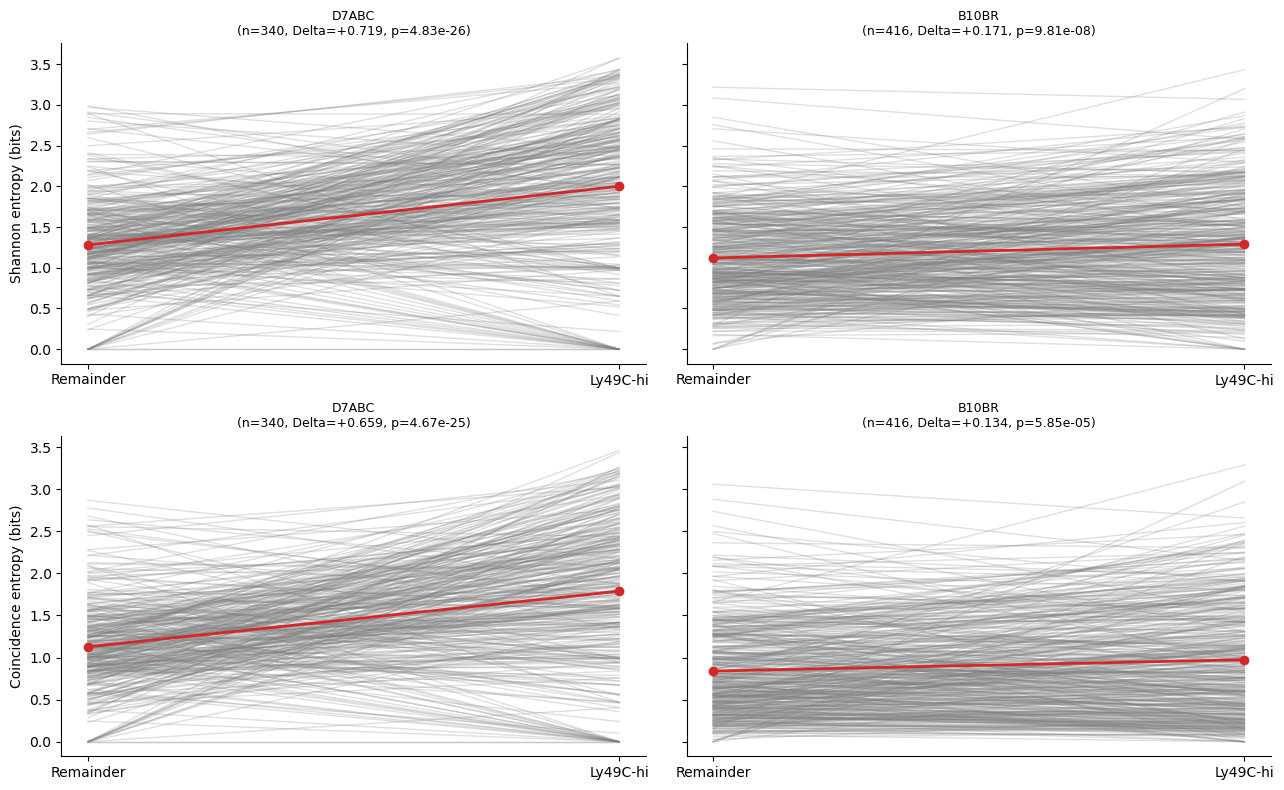

In [71]:
pooled_b10br_ly49c = pool_marker_hi_vs_rest(
    df_b10br_sd_comb, CT_COL, SAMPLE_COL, LY49C_COL, markers_b10br,
    samples=['BL6-B10BR_HTxA', 'BL6-B10BR_HTxB', 'BL6-B10BR_HTxC']
)
pooled_b10br_ly49c.to_csv('Comparison3_Samplewise_Outputs/entropy_comparisons/pooled_b10br_ly49c_entropy.csv')

pooled_balbc_ly49c = pool_marker_hi_vs_rest(
    df_balbc_sd_comb, CT_COL, SAMPLE_COL, LY49C_COL, markers_balbc,
    samples=['BL6-BALBc_HTxB', 'BL6-BALBc_HTxC']
)

pooled_d7abc_ly49c = pool_marker_hi_vs_rest(
    df_d7abc_sd_comb, CT_COL, SAMPLE_COL, LY49C_COL, markers_b10br,
    samples=['D7A', 'D7B', 'D7C']
)
pooled_d7abc_ly49c.to_csv('Comparison3_Samplewise_Outputs/entropy_comparisons/pooled_d7abc_ly49c_entropy.csv')

fig = plot_pooled_2x2(
    {'D7ABC': pooled_d7abc_ly49c, 'B10BR': pooled_b10br_ly49c,},
    out_png=Path('Comparison3_Samplewise_Outputs/entropy_comparisons/pooled_2x2_ly49c_entropy.png')
)

[filter_zero_dextramer] Removed 2,739 / 17,991 cells (15.22%) with zero total dextramer counts
[filter_zero_dextramer] Removed 112 / 9,319 cells (1.20%) with zero total dextramer counts


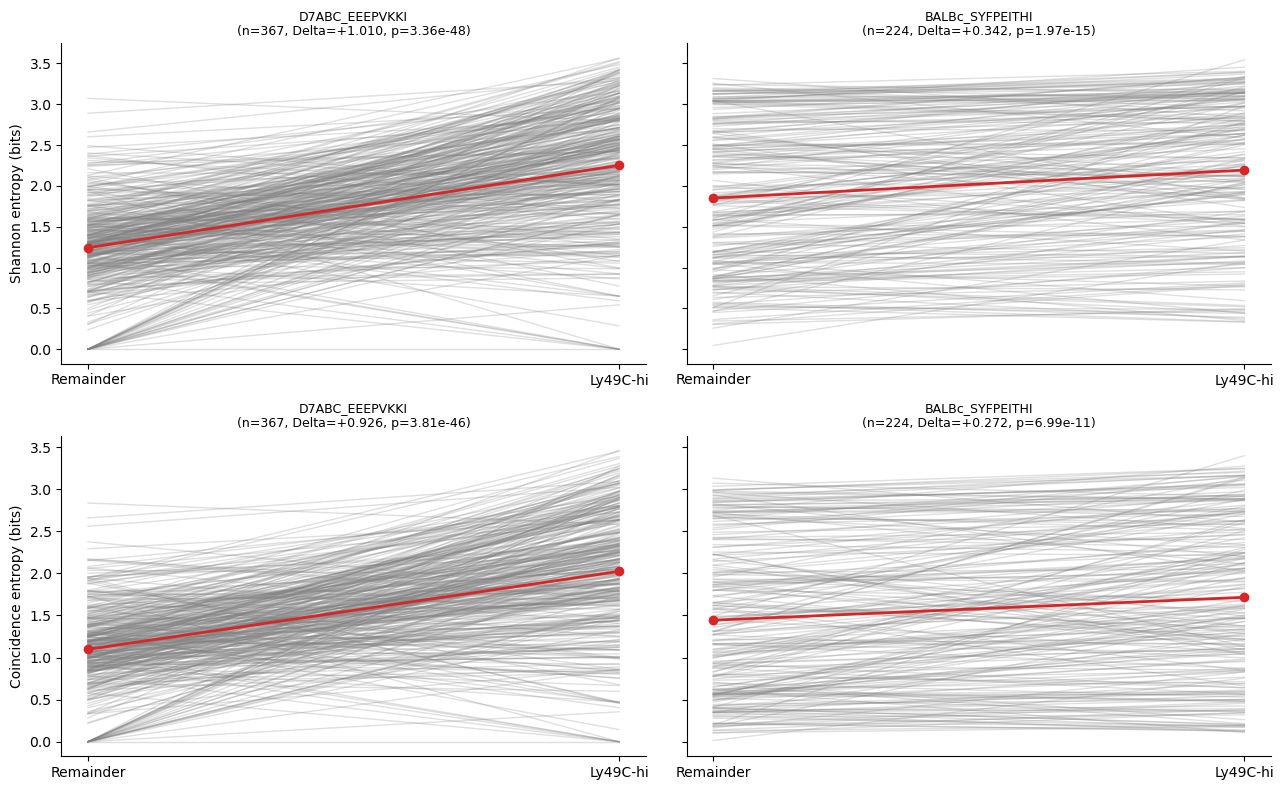

In [72]:
pooled_d7abc_eeepvkki = pool_marker_hi_vs_rest(
    df_d7abc_sd_comb, CT_COL, SAMPLE_COL, EEEPVKKI_COL, markers_b10br,
    samples=['D7A', 'D7B', 'D7C']
)
pooled_d7abc_eeepvkki.to_csv('Comparison3_Samplewise_Outputs/entropy_comparisons/pooled_d7abc_eeepvkki_entropy.csv')

pooled_balbc_bc_syfpeithi = pool_marker_hi_vs_rest(
    df_balbc_sd_comb, CT_COL, SAMPLE_COL, SYFPEITHI_COL, markers_balbc,
    samples=['BL6-BALBc_HTxB', 'BL6-BALBc_HTxC']
)
pooled_balbc_bc_syfpeithi.to_csv('Comparison3_Samplewise_Outputs/entropy_comparisons/pooled_balbc_bc_syfpeithi_entropy.csv')

fig = plot_pooled_2x2(
    {'D7ABC_EEEPVKKI': pooled_d7abc_eeepvkki, 'BALBc_SYFPEITHI': pooled_balbc_bc_syfpeithi,},
    out_png=Path('Comparison3_Samplewise_Outputs/entropy_comparisons/pooled_visualisation_balbc_B_C(syfpeithi)_d7abc(eeepvkki).png')
)

In [73]:
index_b10br_singles, before_b10br_singles, after_b10br_singles = run_samplewise_pipeline(
    df=df_b10br_singles,
    dataset_name='B10BR_Singles',
    markers=markers_b10br,
    peptides=peptides_b10br,
    output_root=Path('Comparison3_Samplewise_Outputs'),
    thresholds=thresholds,
    chosen_q=chosen_q_baseline,
    min_size=5,
    entropy_alpha_for_sweep=1.0,
    renyi_orders=[0,1,2,5],
    debug_probs=False
)

index_b10br_duals, before_b10br_duals, after_b10br_duals = run_samplewise_pipeline(
    df=df_b10br_duals,
    dataset_name='B10BR_Duals',
    markers=markers_b10br,
    peptides=peptides_b10br,
    output_root=Path('Comparison3_Samplewise_Outputs'),
    thresholds=thresholds,
    chosen_q=chosen_q_baseline,
    min_size=5,
    entropy_alpha_for_sweep=1.0,
    renyi_orders=[0,1,2,5],
    debug_probs=False
)

Dataset: B10BR_Singles
[filter_zero_dextramer] Removed 110 / 17,681 cells (0.62%) with zero total dextramer counts
  Processing sample: BL6-B10BR_HTxA (512 cells, q=1.0)
Plotting 15 clonotypes ordered by decreasing coherence
  Processing sample: BL6-B10BR_HTxB (7,133 cells, q=1.0)
Plotting 180 clonotypes ordered by decreasing coherence
  Processing sample: BL6-B10BR_HTxC (9,926 cells, q=1.0)
Plotting 204 clonotypes ordered by decreasing coherence
Dataset: B10BR_Duals
[filter_zero_dextramer] Removed 0 / 1,247 cells (0.00%) with zero total dextramer counts
  Processing sample: BL6-B10BR_HTxA (29 cells, q=1.0)
Plotting 3 clonotypes ordered by decreasing coherence
  Processing sample: BL6-B10BR_HTxB (325 cells, q=1.0)
Plotting 31 clonotypes ordered by decreasing coherence
  Processing sample: BL6-B10BR_HTxC (893 cells, q=1.0)
Plotting 43 clonotypes ordered by decreasing coherence


In [74]:
index_balbc_singles, before_balbc_singles, after_balbc_singles = run_samplewise_pipeline(
    df=df_balbc_singles,
    dataset_name='BALBc_Singles',
    markers=markers_balbc,
    peptides=peptides_balbc,
    output_root=Path('Comparison3_Samplewise_Outputs'),
    thresholds=thresholds,
    chosen_q=chosen_q_baseline,
    min_size=5,
    entropy_alpha_for_sweep=1.0,
    renyi_orders=[0,1,2,5],
    debug_probs=False
)

index_balbc_duals, before_balbc_duals, after_balbc_duals = run_samplewise_pipeline(
    df=df_balbc_duals,
    dataset_name='BALBc_Duals',
    markers=markers_balbc,
    peptides=peptides_balbc,
    output_root=Path('Comparison3_Samplewise_Outputs'),
    thresholds=thresholds,
    chosen_q=chosen_q_baseline,
    min_size=5,
    entropy_alpha_for_sweep=1.0,
    renyi_orders=[0,1,2,5],
    debug_probs=False
)

Dataset: BALBc_Singles
[filter_zero_dextramer] Removed 112 / 8,649 cells (1.29%) with zero total dextramer counts
  Processing sample: BL6-BALBc_HTxA (2,500 cells, q=1.0)
Plotting 99 clonotypes ordered by decreasing coherence
  Processing sample: BL6-BALBc_HTxB (3,712 cells, q=1.0)
Plotting 124 clonotypes ordered by decreasing coherence
  Processing sample: BL6-BALBc_HTxC (2,325 cells, q=1.0)
Plotting 86 clonotypes ordered by decreasing coherence
Dataset: BALBc_Duals
[filter_zero_dextramer] Removed 0 / 670 cells (0.00%) with zero total dextramer counts
  Processing sample: BL6-BALBc_HTxA (200 cells, q=1.0)
Plotting 13 clonotypes ordered by decreasing coherence
  Processing sample: BL6-BALBc_HTxB (277 cells, q=1.0)
Plotting 20 clonotypes ordered by decreasing coherence
  Processing sample: BL6-BALBc_HTxC (193 cells, q=1.0)
Plotting 19 clonotypes ordered by decreasing coherence


In [75]:
q06_d7abc_tcrbeta = {
    'D7A': 0.60,
    'D7B': 0.60,
    'D7C': 0.60,
}

q04_d7abc_tcrbeta = {
    'D7A': 0.40,
    'D7B': 0.40,
    'D7C': 0.40,
}


index_d7abc_singles_q06, before_d7abc_singles_q06, after_d7abc_singles_q06 = run_samplewise_pipeline_generic(
    df=df_d7abc_singles,
    dataset_name='D7ABC_Singles_TCRbeta_q06',
    markers=markers_b10br,
    peptides=peptides_b10br,
    output_root=Path('Comparison3_Samplewise_Outputs'),
    thresholds=thresholds,
    chosen_q=q06_d7abc_tcrbeta,
    filter_col=TCRBETA_COL,
    reverse=True,
    filter_tag='tcrbeta',
    min_size=5,
    entropy_alpha_for_sweep=1.0,
    renyi_orders=[0,1,2,5],
    debug_probs=False
)

index_d7abc_singles_q04, before_d7abc_singles_q04, after_d7abc_singles_q04 = run_samplewise_pipeline_generic(
    df=df_d7abc_singles,
    dataset_name='D7ABC_Singles_TCRbeta_q04',
    markers=markers_b10br,
    peptides=peptides_b10br,
    output_root=Path('Comparison3_Samplewise_Outputs'),
    thresholds=thresholds,
    chosen_q=q04_d7abc_tcrbeta,
    filter_col=TCRBETA_COL,
    reverse=True,
    filter_tag='tcrbeta',
    min_size=5,
    entropy_alpha_for_sweep=1.0,
    renyi_orders=[0,1,2,5],
    debug_probs=False
)

Dataset: D7ABC_Singles_TCRbeta_q06
[filter_zero_dextramer] Removed 2,739 / 16,934 cells (16.17%) with zero total dextramer counts
Processign sample: D7A (4,849 cells, q=0.6)
Plotting 100 clonotypes ordered by decreasing coherence
Processign sample: D7B (4,408 cells, q=0.6)
Plotting 95 clonotypes ordered by decreasing coherence
Processign sample: D7C (4,938 cells, q=0.6)
Plotting 89 clonotypes ordered by decreasing coherence
Dataset: D7ABC_Singles_TCRbeta_q04
[filter_zero_dextramer] Removed 2,739 / 16,934 cells (16.17%) with zero total dextramer counts
Processign sample: D7A (4,849 cells, q=0.4)
Plotting 66 clonotypes ordered by decreasing coherence
Processign sample: D7B (4,408 cells, q=0.4)
Plotting 59 clonotypes ordered by decreasing coherence
Processign sample: D7C (4,938 cells, q=0.4)
Plotting 68 clonotypes ordered by decreasing coherence


In [76]:
before_d7abc_singles = {
    s: g.copy() for s, g in filter_zero_dextramer_cells(df_d7abc_singles, markers_b10br).groupby(SAMPLE_COL)
}

before_d7abc_duals = {
    s: g.copy() for s, g in filter_zero_dextramer_cells(df_d7abc_duals, markers_b10br).groupby(SAMPLE_COL)
}

[filter_zero_dextramer] Removed 2,739 / 16,934 cells (16.17%) with zero total dextramer counts
[filter_zero_dextramer] Removed 0 / 1,057 cells (0.00%) with zero total dextramer counts


In [77]:
tcrbeta_sample_configs = {
    'D7ABC_Singles': before_d7abc_singles,
    'D7ABC_Duals': before_d7abc_duals
}

tcrbeta_sample_results = {}

for dataset_name, before_dict in tcrbeta_sample_configs.items():
    ds_out = Path('Comparison3_Samplewise_Outputs') / dataset_name
    ds_out.mkdir(parents=True, exist_ok=True)

    for sample, df_s in before_dict.items():
        s_out = ds_out / str(sample)
        s_out.mkdir(parents=True, exist_ok=True)

        sweep_metrics, sweep_entropy, sweep_coherence = sweep_threshold_metrics_one_sample(
            df_s=df_s,
            ct_col=CT_COL,
            filter_col=TCRBETA_COL,
            markers=markers_b10br,
            thresholds=thresholds,
            orders=[0,1,2,5],
            min_size=5,
            entropy_alpha_for_sweep=1.0,
            reverse=True,
            sample_name=str(sample),
            thresh_col_name='thresh_tcrbeta'
        )

        sweep_metrics.to_csv(s_out / 'tcrbeta_sweep_metrics.csv', index=False)
        sweep_entropy.to_csv(s_out / 'tcrbeta_sweep_entropy.csv', index=False)
        sweep_coherence.to_csv(s_out / 'tcrbeta_sweep_coherence.csv', index=False)

        plot_sweep_metrics_2x3(
            sweep_df=sweep_metrics,
            sweep_entropy_df=sweep_entropy[sweep_entropy['sample'] == str(sample)],
            sweep_coherence_df=sweep_coherence[sweep_coherence['sample'] == str(sample)],
            out_png=s_out / 'tcrbeta_sweep_metrics_2x3.png',
            title=f'{dataset_name} | {sample} | TCRbeta sweep',
            sample_q=chosen_q_baseline[sample]
        )

        plot_clonotype_retention_overlay(
            df_s=df_s,
            ct_col=CT_COL,
            filter_col=TCRBETA_COL,
            thresholds=thresholds,
            sample_name=str(sample),
            out_png=s_out / 'tcrbeta_retention_overlay.png',
            floors=(5, 2),
            reverse=True
        )

        tcrbeta_sample_results[(dataset_name, sample)] = (sweep_metrics, sweep_entropy, sweep_coherence)

        n_ct = df_s[df_s[CT_COL].map(df_s[CT_COL].value_counts()) >= 5][CT_COL].nunique()
        print(f'{dataset_name} | {sample} (tcrbeta): {n_ct} clonotypes >=5 cells, {len(df_s):,} cells')

D7ABC_Singles | D7A (tcrbeta): 137 clonotypes >=5 cells, 4,849 cells
D7ABC_Singles | D7B (tcrbeta): 139 clonotypes >=5 cells, 4,408 cells
D7ABC_Singles | D7C (tcrbeta): 126 clonotypes >=5 cells, 4,938 cells
D7ABC_Duals | D7A (tcrbeta): 16 clonotypes >=5 cells, 364 cells
D7ABC_Duals | D7B (tcrbeta): 27 clonotypes >=5 cells, 379 cells
D7ABC_Duals | D7C (tcrbeta): 20 clonotypes >=5 cells, 314 cells


In [81]:
def single_vs_dual_entropy_one_sample(df_single, df_dual, ct_col, sample, markers):
    '''
    per clonotype mean shannon and coincidence entropy, single vs dual, in one sample
    '''
    rows = []
    for label, df_s in [('single', df_single), ('dual', df_dual)]:
        if len(df_s) == 0:
            continue
        P = row_normalise(df_s[markers].to_numpy(dtype=float))
        df_tmp = df_s[[ct_col]].copy()
        df_tmp['shannon'] = renyi_entropy(P, alpha=1.0, axis=1)
        df_tmp['coincidence'] = renyi_entropy(P, alpha=2.0, axis=1)

        for ct, g in df_tmp.groupby(ct_col):
            rows.append({
                'sample': sample,
                'clonotype': ct,
                'class': label,
                'n_cells': len(g),
                'shannon': g['shannon'].mean(),
                'coincidence': g['coincidence'].mean()
            })

    return pd.DataFrame(rows)

In [82]:
def pool_single_vs_dual_entropy(df_single, df_dual, ct_col, sample_col, markers, samples):
    '''
    runs single_vs_dual_entropy_one_sample per sample, filters out zero-dex cells first, then pools
    the samples into a clonotype-level table
    '''
    df_single_clean = filter_zero_dextramer_cells(df_single, markers)
    df_dual_clean = filter_zero_dextramer_cells(df_dual, markers)

    per_sample = []
    for sample in samples:
        s_single = df_single_clean[df_single_clean[sample_col] == sample]
        s_dual = df_dual_clean[df_dual_clean[sample_col] == sample]
        per_sample.append(single_vs_dual_entropy_one_sample(s_single, s_dual, ct_col, sample, markers))

    return pd.concat(per_sample, ignore_index=True)

In [97]:
from scipy.stats import mannwhitneyu

def plot_single_vs_dual_2x2(datasets, out_png=None):
    '''
    datasets are dict like: {'D7ABC': res_d7abc, 'B10BR': res_b10br, 'BALBc': res_balbc}
    res_df is the output of pool_single_vs_dual_entropy for that dataset
    '''
    metrics = ['shannon', 'coincidence']
    fig, axes = plt.subplots(2, len(datasets), figsize=(6.5 * len(datasets), 8), sharey='row')
    if len(datasets) == 1:
        axes = axes.reshape(2, 1)

    rng = np.random.default_rng(42)

    for row, metric in enumerate(metrics):
        for col, (name, res) in enumerate(datasets.items()):
            ax = axes[row, col]
            singles = res[res['class'] == 'single'][metric].to_numpy()
            duals = res[res['class'] == 'dual'][metric].to_numpy()
            u = mannwhitneyu(singles, duals, alternative='two-sided')

            x_single = rng.normal(0, 0.04, size=len(singles))
            x_dual = rng.normal(1, 0.04, size=len(duals))
            ax.scatter(x_single, singles, color='gray', alpha=0.4, s=14)
            ax.scatter(x_dual, duals, color='gray', alpha=0.4, s=14)
            ax.plot([0, 1], [singles.mean(), duals.mean()], color='C3', lw=2, marker='o')

            ax.set_xticks([0, 1])
            ax.set_xticklabels(['Single', 'Dual'])
            ax.set_xlim(-0.3, 1.3)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            if col == 0:
                ax.set_ylabel(f'{metric.capitalize()} entropy')
            delta = duals.mean() - singles.mean()
            ax.set_title(f'{name}\n(n_single)={len(singles)}, n_dual={len(duals)}, '
                        f'Delta={delta:.3f}, p={u.pvalue:.3g})', fontsize=9)

    fig.tight_layout()

    if out_png:
        fig.savefig(out_png, dpi=170, bbox_inches='tight')
    return fig

In [98]:
res_d7abc = pool_single_vs_dual_entropy(
    df_d7abc_singles, df_d7abc_duals, CT_COL, SAMPLE_COL, markers_b10br,
    samples=['D7A', 'D7B', 'D7C']
)

res_b10br = pool_single_vs_dual_entropy(
    df_b10br_singles, df_b10br_duals, CT_COL, SAMPLE_COL, markers_b10br,
    samples=['BL6-B10BR_HTxA', 'BL6-B10BR_HTxB', 'BL6-B10BR_HTxC']
)

res_balbc = pool_single_vs_dual_entropy(
    df_balbc_singles, df_balbc_duals, CT_COL, SAMPLE_COL, markers_balbc,
    samples=['BL6-BALBc_HTxA', 'BL6-BALBc_HTxB', 'BL6-BALBc_HTxC']
)

[filter_zero_dextramer] Removed 2,739 / 16,934 cells (16.17%) with zero total dextramer counts
[filter_zero_dextramer] Removed 0 / 1,057 cells (0.00%) with zero total dextramer counts
[filter_zero_dextramer] Removed 110 / 17,681 cells (0.62%) with zero total dextramer counts
[filter_zero_dextramer] Removed 0 / 1,247 cells (0.00%) with zero total dextramer counts
[filter_zero_dextramer] Removed 112 / 8,649 cells (1.29%) with zero total dextramer counts
[filter_zero_dextramer] Removed 0 / 670 cells (0.00%) with zero total dextramer counts


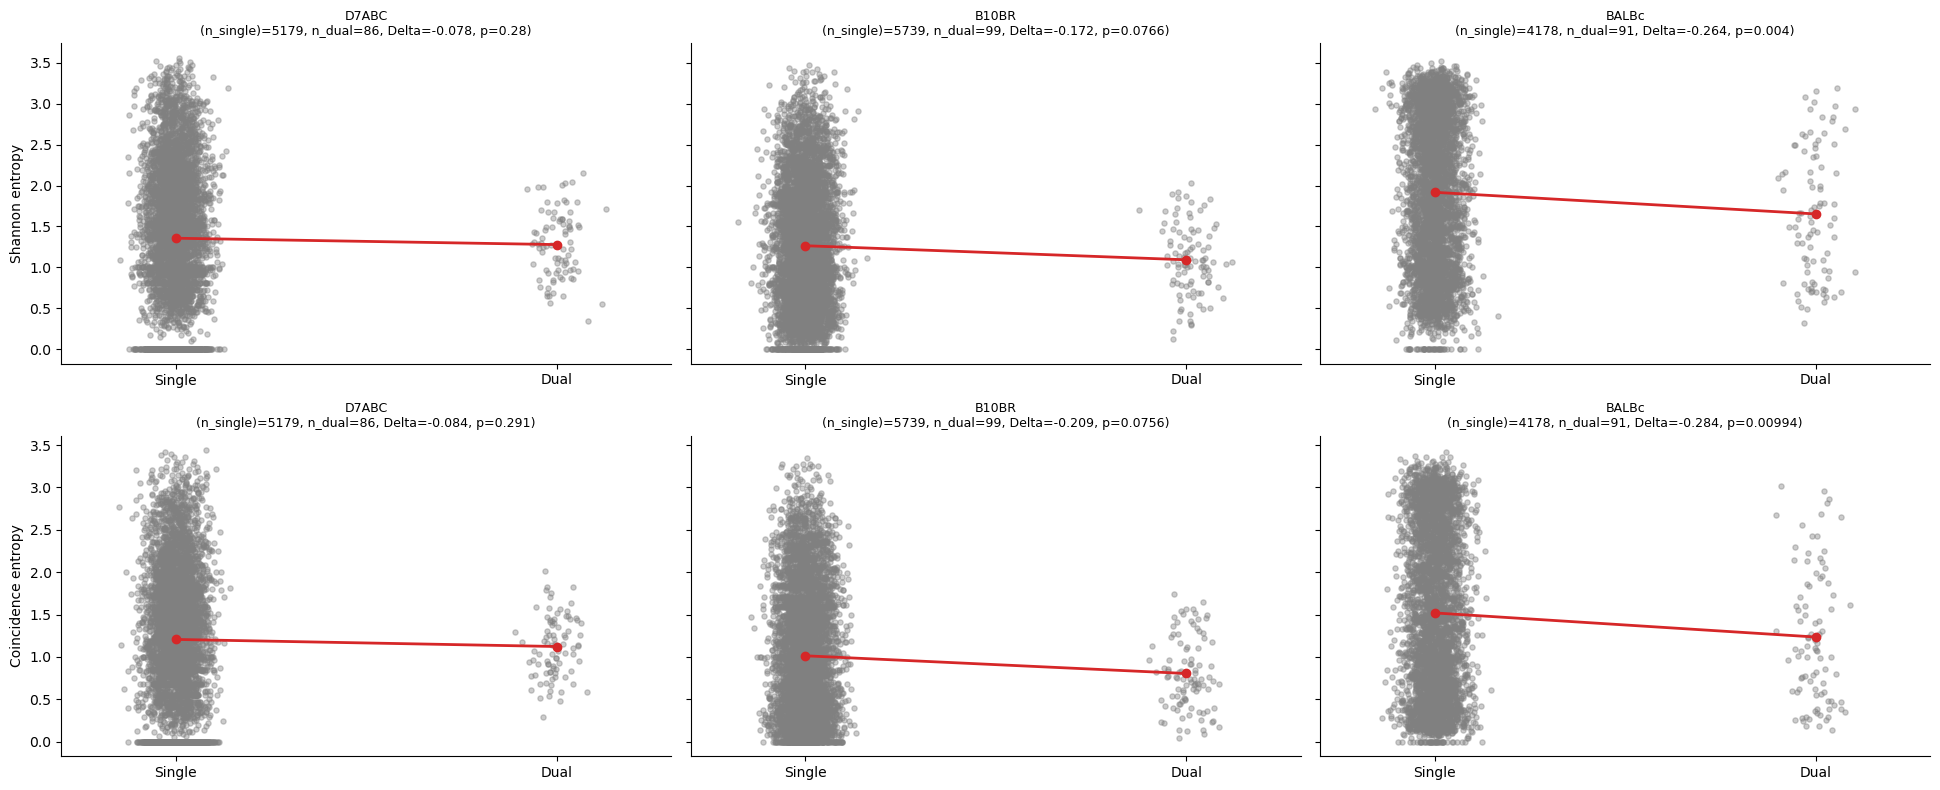

In [99]:
out_dir = Path('Comparison3_Samplewise_Outputs/entropy_comparisons')
out_dir.mkdir(parents=True, exist_ok=True)

res_d7abc.to_csv(out_dir / 'd7abc_single_vs_dual_entropy.csv', index=False)
res_b10br.to_csv(out_dir / 'b10br_single_vs_dual_entropy.csv', index=False)
res_balbc.to_csv(out_dir / 'balbc_single_vs_dual_entropy.csv', index=False)

fig = plot_single_vs_dual_2x2(
    {'D7ABC': res_d7abc, 'B10BR': res_b10br, 'BALBc': res_balbc},
    out_png=out_dir / 'single_vs_dual_entropy_2x2.png'
)
plt.show()